In [1]:
import sys
import platform

print("Python:", sys.version)
print("Executable:", sys.executable)
print("Architecture:", platform.architecture())
print("Machine:", platform.machine())

Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Executable: C:\Users\Atharav Kadam\anaconda3\python.exe
Architecture: ('64bit', 'WindowsPE')
Machine: ARM64


In [2]:
import oracledb

oracledb.init_oracle_client(
    lib_dir=r"C:\oracle\instantclient-basic-windows.x64-23.26.3.0.0\instantclient_23_26"
)

connection = oracledb.connect(
    user="VACCINATION1",
    password="Vaccination123",
    dsn="localhost/XE"
)

print("Oracle connection successful!")

Oracle connection successful!


In [3]:
cursor = connection.cursor()

cursor.execute("""
    SELECT TABLE_NAME
    FROM USER_TABLES
    ORDER BY TABLE_NAME
""")

tables = cursor.fetchall()

for table in tables:
    print(table[0])

DIM_ANTIGEN
DIM_DISEASE
DIM_GEO
DIM_VACCINE_SCHEDULE_CODE
DIM_YEAR
FACT_CASES
FACT_COVERAGE
FACT_INCIDENCE
FACT_INTRODUCTION
FACT_SCHEDULE


In [4]:
for table in tables:
    table_name = table[0]
    cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
    count = cursor.fetchone()[0]
    print(f"{table_name}: {count} rows")

DIM_ANTIGEN: 0 rows
DIM_DISEASE: 0 rows
DIM_GEO: 0 rows
DIM_VACCINE_SCHEDULE_CODE: 0 rows
DIM_YEAR: 0 rows
FACT_CASES: 0 rows
FACT_COVERAGE: 0 rows
FACT_INCIDENCE: 0 rows
FACT_INTRODUCTION: 0 rows
FACT_SCHEDULE: 0 rows


In [5]:
import pandas as pd
import os

In [6]:
coverage=pd.read_csv(r"C:\Users\Atharav Kadam\Downloads\coverage_clean.csv")

In [7]:
schedule=pd.read_csv(r"C:\Users\Atharav Kadam\Downloads\vaccine_schedule_clean.csv")
introduction=pd.read_csv(r"C:\Users\Atharav Kadam\Downloads\vaccine_introduction_clean.csv")
cases=pd.read_csv(r"C:\Users\Atharav Kadam\Downloads\reported_clean.csv")
incidence=pd.read_csv(r"C:\Users\Atharav Kadam\Downloads\incidence_clean.csv")

In [8]:
datasets = {
    "COVERAGE": coverage,
    "SCHEDULE": schedule,
    "INTRODUCTION": introduction,
    "CASES": cases,
    "INCIDENCE": incidence
}

for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("Rows:", len(df))
    print("Columns:", len(df.columns))
    print("Column names:")
    print(df.columns.tolist())


COVERAGE
Rows: 399859
Columns: 12
Column names:
['group', 'iso_code', 'name', 'year', 'antigen', 'antigen_description', 'coverage_category', 'coverage_category_description', 'target_number', 'doses', 'coverage', 'group_level']

SCHEDULE
Rows: 8053
Columns: 12
Column names:
['iso_code', 'countryname', 'who_region', 'year', 'vaccinecode', 'vaccine_description', 'schedulerounds', 'targetpop', 'targetpop_description', 'geoarea', 'ageadministered', 'sourcecomment']

INTRODUCTION
Rows: 138321
Columns: 6
Column names:
['iso_code', 'countryname', 'who_region', 'year', 'description', 'intro']

CASES
Rows: 84870
Columns: 8
Column names:
['group', 'iso_code', 'name', 'year', 'disease', 'disease_description', 'cases', 'group_level']

INCIDENCE
Rows: 84946
Columns: 9
Column names:
['group', 'iso_code', 'name', 'year', 'disease', 'disease_description', 'denominator', 'incidence_rate', 'group_level']


In [9]:
for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    display(df.head(3))


COVERAGE


,group,iso_code,name,year,antigen,antigen_description,coverage_category,coverage_category_description,target_number,doses,coverage,group_level
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN,COUNTRY
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN,COUNTRY
2,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52,COUNTRY



SCHEDULE


,iso_code,countryname,who_region,year,vaccinecode,vaccine_description,schedulerounds,targetpop,targetpop_description,geoarea,ageadministered,sourcecomment
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,NaN,General/routine,NATIONAL,M6,NaN



INTRODUCTION


,iso_code,countryname,who_region,year,description,intro
0,AFG,Afghanistan,EMRO,2023.0,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023.0,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023.0,Hepatitis B vaccine,Yes



CASES


,group,iso_code,name,year,disease,disease_description,cases,group_level
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,0.0,COUNTRY
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,0.0,COUNTRY
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,1.0,COUNTRY



INCIDENCE


,group,iso_code,name,year,disease,disease_description,denominator,incidence_rate,group_level
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0,COUNTRY
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0,COUNTRY
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3,COUNTRY


In [10]:
for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(df.dtypes)


COVERAGE
group                             object
iso_code                          object
name                              object
year                             float64
antigen                           object
antigen_description               object
coverage_category                 object
coverage_category_description     object
target_number                    float64
doses                            float64
coverage                         float64
group_level                       object
dtype: object

SCHEDULE
iso_code                  object
countryname               object
who_region                object
year                     float64
vaccinecode               object
vaccine_description       object
schedulerounds           float64
targetpop                 object
targetpop_description     object
geoarea                   object
ageadministered           object
sourcecomment             object
dtype: object

INTRODUCTION
iso_code        object
countryname     object
who_

In [11]:
for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(df.isnull().sum())


COVERAGE
group                                 0
iso_code                              1
name                               1275
year                                  1
antigen                               1
antigen_description                   1
coverage_category                     1
coverage_category_description         1
target_number                    320829
doses                            320532
coverage                         169382
group_level                           0
dtype: int64

SCHEDULE
iso_code                    0
countryname                 1
who_region                  1
year                        1
vaccinecode                 1
vaccine_description         1
schedulerounds              1
targetpop                4258
targetpop_description       1
geoarea                    31
ageadministered          1046
sourcecomment            2914
dtype: int64

INTRODUCTION
iso_code       0
countryname    1
who_region     1
year           1
description    1
intro          

In [12]:
for name, df in datasets.items():
    print(name)
    print(df.columns.tolist())
    print("-" * 70)

COVERAGE
['group', 'iso_code', 'name', 'year', 'antigen', 'antigen_description', 'coverage_category', 'coverage_category_description', 'target_number', 'doses', 'coverage', 'group_level']
----------------------------------------------------------------------
SCHEDULE
['iso_code', 'countryname', 'who_region', 'year', 'vaccinecode', 'vaccine_description', 'schedulerounds', 'targetpop', 'targetpop_description', 'geoarea', 'ageadministered', 'sourcecomment']
----------------------------------------------------------------------
INTRODUCTION
['iso_code', 'countryname', 'who_region', 'year', 'description', 'intro']
----------------------------------------------------------------------
CASES
['group', 'iso_code', 'name', 'year', 'disease', 'disease_description', 'cases', 'group_level']
----------------------------------------------------------------------
INCIDENCE
['group', 'iso_code', 'name', 'year', 'disease', 'disease_description', 'denominator', 'incidence_rate', 'group_level']
---------

In [13]:
import pandas as pd
import numpy as np

# Make copies
coverage = coverage.copy()
schedule = schedule.copy()
introduction = introduction.copy()
cases = cases.copy()
incidence = incidence.copy()

# Convert YEAR to numeric
for df in [coverage, schedule, introduction, cases, incidence]:
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

print("Data prepared successfully!")

Data prepared successfully!


In [14]:
all_years = pd.concat([
    coverage["year"],
    schedule["year"],
    introduction["year"],
    cases["year"],
    incidence["year"]
], ignore_index=True)

years = (
    pd.to_numeric(all_years, errors="coerce")
    .dropna()
    .astype(int)
    .drop_duplicates()
    .sort_values()
)

print("Number of years:", len(years))
print("Year range:", years.min(), "-", years.max())

Number of years: 84
Year range: 1940 - 2023


In [15]:
cursor = connection.cursor()

year_data = [(int(year),) for year in years]

cursor.executemany(
    "INSERT INTO DIM_YEAR (YEAR) VALUES (:1)",
    year_data
)

connection.commit()

print("DIM_YEAR loaded:", len(year_data), "rows")

DIM_YEAR loaded: 84 rows


In [16]:
disease_1 = cases[["disease", "disease_description"]].copy()
disease_2 = incidence[["disease", "disease_description"]].copy()

diseases = pd.concat([disease_1, disease_2], ignore_index=True)

diseases["disease"] = diseases["disease"].astype(str).str.strip()
diseases["disease_description"] = diseases["disease_description"].astype(str).str.strip()

diseases = diseases[
    diseases["disease"].notna() &
    (diseases["disease"] != "") &
    (diseases["disease"] != "nan")
]

diseases = diseases.drop_duplicates(subset=["disease"])

print("Diseases:", len(diseases))
display(diseases.head())

Diseases: 13


,disease,disease_description
0,CRS,Congenital rubella syndrome
1,DIPHTHERIA,Diphtheria
2,INVASIVE_MENING,Invasive meningococcal disease
3,MEASLES,Measles
4,MUMPS,Mumps


In [17]:
disease_data = [
    (
        row["disease"],
        None if row["disease_description"] == "nan"
        else row["disease_description"]
    )
    for _, row in diseases.iterrows()
]

cursor.executemany(
    """
    INSERT INTO DIM_DISEASE
    (DISEASE_CODE, DESCRIPTION)
    VALUES (:1, :2)
    """,
    disease_data
)

connection.commit()

print("DIM_DISEASE loaded:", len(disease_data), "rows")

DIM_DISEASE loaded: 13 rows


In [18]:
antigens = coverage[
    ["antigen", "antigen_description"]
].copy()

antigens["antigen"] = antigens["antigen"].astype(str).str.strip()

antigens = antigens[
    antigens["antigen"].notna() &
    (antigens["antigen"] != "") &
    (antigens["antigen"] != "nan")
]

antigens = antigens.drop_duplicates(subset=["antigen"])

print("Antigens:", len(antigens))
display(antigens.head())

Antigens: 69


,antigen,antigen_description
0,BCG,BCG
2,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b..."
4,DIPHCV5,"Diphtheria-containing vaccine, 5th dose (2nd b..."
6,DIPHCV6,"Diphtheria-containing vaccine, 6th dose (3rd b..."
8,DTPCV1,"DTP-containing vaccine, 1st dose"


In [19]:
antigen_data = [
    (
        row["antigen"],
        None if pd.isna(row["antigen_description"])
        else str(row["antigen_description"])
    )
    for _, row in antigens.iterrows()
]

cursor.executemany(
    """
    INSERT INTO DIM_ANTIGEN
    (ANTIGEN_CODE, DESCRIPTION)
    VALUES (:1, :2)
    """,
    antigen_data
)

connection.commit()

print("DIM_ANTIGEN loaded:", len(antigen_data), "rows")

DIM_ANTIGEN loaded: 69 rows


In [22]:
vaccines = schedule[
    ["vaccincode", "vaccine_description"]
].copy()

vaccines["vaccincode"] = vaccines["vaccincode"].astype(str).str.strip()

vaccines = vaccines[
    vaccines["vaccincode"].notna() &
    (vaccines["vaccincode"] != "") &
    (vaccines["vaccincode"] != "nan")
]

vaccines = vaccines.drop_duplicates(subset=["vaccincode"])

print("Vaccine schedule codes:", len(vaccines))
display(vaccines.head())

KeyError: "['vaccincode'] not in index"

In [23]:
print(schedule.columns.tolist())

['iso_code', 'countryname', 'who_region', 'year', 'vaccinecode', 'vaccine_description', 'schedulerounds', 'targetpop', 'targetpop_description', 'geoarea', 'ageadministered', 'sourcecomment']


In [24]:
for i, col in enumerate(schedule.columns):
    print(i, repr(col))

0 'iso_code'
1 'countryname'
2 'who_region'
3 'year'
4 'vaccinecode'
5 'vaccine_description'
6 'schedulerounds'
7 'targetpop'
8 'targetpop_description'
9 'geoarea'
10 'ageadministered'
11 'sourcecomment'


In [25]:
vaccines = schedule[
    ["vaccinecode", "vaccine_description"]
].copy()

vaccines["vaccinecode"] = vaccines["vaccinecode"].astype(str).str.strip()

vaccines = vaccines[
    vaccines["vaccinecode"].notna() &
    (vaccines["vaccinecode"] != "") &
    (vaccines["vaccinecode"] != "nan")
]

vaccines = vaccines.drop_duplicates(subset=["vaccinecode"])

print("Vaccine schedule codes:", len(vaccines))
display(vaccines.head())

Vaccine schedule codes: 86


,vaccinecode,vaccine_description
0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine
4,DTAPIPV,DTaP-IPV (acellular) vaccine
9,HEPA_ADULT,Adult Hepatitis A vaccine
11,HEPA_PEDIATRIC,Pediatric Hepatitis A vaccine
13,HEPB_ADULT,Adult Hepatitis B vaccine


In [26]:
vaccine_data = [
    (
        row["vaccinecode"],
        None if pd.isna(row["vaccine_description"])
        else str(row["vaccine_description"])
    )
    for _, row in vaccines.iterrows()
]

cursor.executemany(
    """
    INSERT INTO DIM_VACCINE_SCHEDULE_CODE
    (VACCINE_CODE, DESCRIPTION)
    VALUES (:1, :2)
    """,
    vaccine_data
)

connection.commit()

print(
    "DIM_VACCINE_SCHEDULE_CODE loaded:",
    len(vaccine_data),
    "rows"
)

DIM_VACCINE_SCHEDULE_CODE loaded: 86 rows


In [27]:
cursor.execute("""
    SELECT COUNT(*)
    FROM DIM_VACCINE_SCHEDULE_CODE
""")

print(
    "Rows in DIM_VACCINE_SCHEDULE_CODE:",
    cursor.fetchone()[0]
)

Rows in DIM_VACCINE_SCHEDULE_CODE: 86


In [28]:
dimension_tables = [
    "DIM_GEO",
    "DIM_YEAR",
    "DIM_DISEASE",
    "DIM_ANTIGEN",
    "DIM_VACCINE_SCHEDULE_CODE"
]

for table in dimension_tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    print(f"{table}: {cursor.fetchone()[0]} rows")

DIM_GEO: 0 rows
DIM_YEAR: 84 rows
DIM_DISEASE: 13 rows
DIM_ANTIGEN: 69 rows
DIM_VACCINE_SCHEDULE_CODE: 86 rows


In [29]:
# Create a clean geography dataset from all available sources

geo_frames = []

# Coverage
geo_frames.append(
    coverage[["iso_code", "name", "group", "group_level"]].copy()
)

# Cases
geo_frames.append(
    cases[["iso_code", "name", "group", "group_level"]].copy()
)

# Incidence
geo_frames.append(
    incidence[["iso_code", "name", "group", "group_level"]].copy()
)

# Schedule
schedule_geo = schedule[
    ["iso_code", "countryname", "who_region"]
].copy()

schedule_geo = schedule_geo.rename(
    columns={"countryname": "name"}
)

schedule_geo["group"] = None
schedule_geo["group_level"] = None

geo_frames.append(schedule_geo)

# Introduction
intro_geo = introduction[
    ["iso_code", "countryname", "who_region"]
].copy()

intro_geo = intro_geo.rename(
    columns={"countryname": "name"}
)

intro_geo["group"] = None
intro_geo["group_level"] = None

geo_frames.append(intro_geo)

# Combine everything
geo = pd.concat(geo_frames, ignore_index=True)

# Clean ISO codes
geo["iso_code"] = geo["iso_code"].astype(str).str.strip()

# Remove invalid ISO codes
geo = geo[
    geo["iso_code"].notna() &
    (geo["iso_code"] != "") &
    (geo["iso_code"].str.lower() != "nan")
]

print("Total geography records before removing duplicates:", len(geo))

Total geography records before removing duplicates: 716046


In [30]:
# Clean text fields
geo["name"] = geo["name"].astype(str).str.strip()

# Determine country vs aggregate
geo["geo_level"] = np.where(
    geo["group_level"].notna() &
    (geo["group_level"].astype(str).str.strip() != "") &
    (geo["group_level"].astype(str).str.lower() != "nan"),
    "AGGREGATE",
    "COUNTRY"
)

# Keep one record per ISO code
geo = geo.drop_duplicates(subset=["iso_code"], keep="first")

print("Unique geography records:", len(geo))

display(
    geo[
        ["iso_code", "name", "geo_level", "group", "group_level"]
    ].head(20)
)

Unique geography records: 247


,iso_code,name,geo_level,group,group_level
0,ABW,Aruba,AGGREGATE,COUNTRIES,COUNTRY
468,AFG,Afghanistan,AGGREGATE,COUNTRIES,COUNTRY
2429,AGO,Angola,AGGREGATE,COUNTRIES,COUNTRY
4400,AIA,Anguilla,AGGREGATE,COUNTRIES,COUNTRY
5296,ALB,Albania,AGGREGATE,COUNTRIES,COUNTRY
7231,AND,Andorra,AGGREGATE,COUNTRIES,COUNTRY
8832,ARE,United Arab Emirates,AGGREGATE,COUNTRIES,COUNTRY
10632,ARG,Argentina,AGGREGATE,COUNTRIES,COUNTRY
12563,ARM,Armenia,AGGREGATE,COUNTRIES,COUNTRY
14285,ASM,American Samoa,AGGREGATE,COUNTRIES,COUNTRY


In [31]:
geo_data = []

for _, row in geo.iterrows():

    iso_code = str(row["iso_code"]).strip()

    name = None
    if pd.notna(row["name"]) and str(row["name"]).lower() != "nan":
        name = str(row["name"]).strip()

    group_type = None
    if pd.notna(row["group"]) and str(row["group"]).lower() != "nan":
        group_type = str(row["group"]).strip()

    geo_level = str(row["geo_level"]).strip()

    # WHO region
    who_region = None

    # Try to find WHO region from schedule/introduction
    matches = schedule[
        schedule["iso_code"].astype(str).str.strip() == iso_code
    ]["who_region"].dropna()

    if len(matches) > 0:
        who_region = str(matches.iloc[0]).strip()

    geo_data.append(
        (
            iso_code,
            name,
            geo_level,
            group_type,
            who_region
        )
    )

print("Records ready for DIM_GEO:", len(geo_data))

Records ready for DIM_GEO: 247


In [32]:
cursor.executemany(
    """
    INSERT INTO DIM_GEO
    (
        GEO_CODE,
        NAME,
        GEO_LEVEL,
        GROUP_TYPE,
        WHO_REGION
    )
    VALUES (:1, :2, :3, :4, :5)
    """,
    geo_data
)

connection.commit()

print("DIM_GEO loaded successfully!")

IntegrityError: ORA-01400: cannot insert NULL into ("VACCINATION1"."DIM_GEO"."NAME")
Help: https://docs.oracle.com/error-help/db/ora-01400/

In [33]:
connection.rollback()

print("Failed DIM_GEO insert rolled back.")

Failed DIM_GEO insert rolled back.


In [34]:
cursor.execute("SELECT COUNT(*) FROM DIM_GEO")
print("DIM_GEO rows:", cursor.fetchone()[0])

DIM_GEO rows: 0


In [35]:
# -----------------------------------------
# PREPARE DIM_GEO SAFELY
# -----------------------------------------

geo_frames = []

# Coverage
g = coverage[
    ["iso_code", "name", "group", "group_level"]
].copy()

g["who_region"] = None
geo_frames.append(g)


# Cases
g = cases[
    ["iso_code", "name", "group", "group_level"]
].copy()

g["who_region"] = None
geo_frames.append(g)


# Incidence
g = incidence[
    ["iso_code", "name", "group", "group_level"]
].copy()

g["who_region"] = None
geo_frames.append(g)


# Schedule
g = schedule[
    ["iso_code", "countryname", "who_region"]
].copy()

g = g.rename(columns={
    "countryname": "name"
})

g["group"] = None
g["group_level"] = None

geo_frames.append(g)


# Introduction
g = introduction[
    ["iso_code", "countryname", "who_region"]
].copy()

g = g.rename(columns={
    "countryname": "name"
})

g["group"] = None
g["group_level"] = None

geo_frames.append(g)


# Combine all sources
geo = pd.concat(
    geo_frames,
    ignore_index=True
)

# Clean whitespace
for col in ["iso_code", "name", "group", "group_level", "who_region"]:
    geo[col] = geo[col].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

# Remove rows with missing ISO code
geo = geo[
    geo["iso_code"].notna()
]

# Remove empty ISO codes
geo = geo[
    geo["iso_code"].astype(str).str.strip() != ""
]

# Remove missing names
geo = geo[
    geo["name"].notna()
]

geo = geo[
    geo["name"].astype(str).str.strip() != ""
]

# Remove textual missing values
geo = geo[
    ~geo["name"].astype(str).str.lower().isin(
        ["nan", "none", "null"]
    )
]

print("Valid geography records:", len(geo))

Valid geography records: 714770


In [36]:
def first_valid(series):
    for value in series:
        if pd.notna(value):
            value = str(value).strip()
            if value and value.lower() not in ["nan", "none", "null"]:
                return value
    return None


geo_final = (
    geo.groupby("iso_code", as_index=False)
       .agg({
           "name": first_valid,
           "group": first_valid,
           "group_level": first_valid,
           "who_region": first_valid
       })
)

print("Unique GEO records:", len(geo_final))

display(geo_final.head(20))

Unique GEO records: 243


,iso_code,name,group,group_level,who_region
0,ABW,Aruba,COUNTRIES,COUNTRY,AMRO
1,AFG,Afghanistan,COUNTRIES,COUNTRY,EMRO
2,AFR,African Region,WHO_REGIONS,AGGREGATE,None
3,AGO,Angola,COUNTRIES,COUNTRY,AFRO
4,AIA,Anguilla,COUNTRIES,COUNTRY,AMRO
5,ALB,Albania,COUNTRIES,COUNTRY,EURO
6,AMR,Region of the Americas,WHO_REGIONS,AGGREGATE,None
7,AND,Andorra,COUNTRIES,COUNTRY,EURO
8,ARE,United Arab Emirates,COUNTRIES,COUNTRY,EMRO
9,ARG,Argentina,COUNTRIES,COUNTRY,AMRO


In [37]:
geo_final["geo_level"] = "COUNTRY"

aggregate_mask = (
    geo_final["group_level"].notna()
    & ~geo_final["group_level"].astype(str).str.lower().isin(
        ["nan", "none", "null", ""]
    )
)

geo_final.loc[aggregate_mask, "geo_level"] = "AGGREGATE"

print(
    geo_final["geo_level"].value_counts()
)

geo_level
AGGREGATE    243
Name: count, dtype: int64


In [38]:
print("Missing GEO_CODE:",
      geo_final["iso_code"].isna().sum())

print("Missing NAME:",
      geo_final["name"].isna().sum())

print("Missing GEO_LEVEL:",
      geo_final["geo_level"].isna().sum())

Missing GEO_CODE: 0
Missing NAME: 0
Missing GEO_LEVEL: 0


In [39]:
display(
    geo_final[
        geo_final["name"].isna()
    ]
)

,iso_code,name,group,group_level,who_region,geo_level


In [40]:
geo_data = []

for _, row in geo_final.iterrows():

    geo_code = str(row["iso_code"]).strip()
    name = str(row["name"]).strip()

    group_type = None
    if pd.notna(row["group"]):
        group_type = str(row["group"]).strip()

    who_region = None
    if pd.notna(row["who_region"]):
        who_region = str(row["who_region"]).strip()

    geo_level = str(row["geo_level"]).strip()

    geo_data.append(
        (
            geo_code,
            name,
            geo_level,
            group_type,
            who_region
        )
    )

print("Records ready for Oracle:", len(geo_data))

Records ready for Oracle: 243


In [41]:
cursor.executemany(
    """
    INSERT INTO DIM_GEO
    (
        GEO_CODE,
        NAME,
        GEO_LEVEL,
        GROUP_TYPE,
        WHO_REGION
    )
    VALUES (:1, :2, :3, :4, :5)
    """,
    geo_data
)

connection.commit()

print("DIM_GEO loaded successfully!")

DIM_GEO loaded successfully!


In [42]:
cursor.execute("""
    SELECT COUNT(*)
    FROM DIM_GEO
""")

print("DIM_GEO rows:", cursor.fetchone()[0])

DIM_GEO rows: 243


In [43]:
cursor.execute("""
    SELECT
        GEO_CODE,
        NAME,
        GEO_LEVEL,
        GROUP_TYPE,
        WHO_REGION
    FROM DIM_GEO
    WHERE ROWNUM <= 15
""")

for row in cursor.fetchall():
    print(row)

('ABW', 'Aruba', 'AGGREGATE', 'COUNTRIES', 'AMRO')
('AFG', 'Afghanistan', 'AGGREGATE', 'COUNTRIES', 'EMRO')
('AFR', 'African Region', 'AGGREGATE', 'WHO_REGIONS', None)
('AGO', 'Angola', 'AGGREGATE', 'COUNTRIES', 'AFRO')
('AIA', 'Anguilla', 'AGGREGATE', 'COUNTRIES', 'AMRO')
('ALB', 'Albania', 'AGGREGATE', 'COUNTRIES', 'EURO')
('AMR', 'Region of the Americas', 'AGGREGATE', 'WHO_REGIONS', None)
('AND', 'Andorra', 'AGGREGATE', 'COUNTRIES', 'EURO')
('ARE', 'United Arab Emirates', 'AGGREGATE', 'COUNTRIES', 'EMRO')
('ARG', 'Argentina', 'AGGREGATE', 'COUNTRIES', 'AMRO')
('ARM', 'Armenia', 'AGGREGATE', 'COUNTRIES', 'EURO')
('ASM', 'American Samoa', 'AGGREGATE', 'COUNTRIES', None)
('ATG', 'Antigua and Barbuda', 'AGGREGATE', 'COUNTRIES', 'AMRO')
('AUS', 'Australia', 'AGGREGATE', 'COUNTRIES', 'WPRO')
('AUT', 'Austria', 'AGGREGATE', 'COUNTRIES', 'EURO')


In [44]:
dimension_tables = [
    "DIM_GEO",
    "DIM_YEAR",
    "DIM_DISEASE",
    "DIM_ANTIGEN",
    "DIM_VACCINE_SCHEDULE_CODE"
]

for table in dimension_tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    print(f"{table}: {cursor.fetchone()[0]} rows")

DIM_GEO: 243 rows
DIM_YEAR: 84 rows
DIM_DISEASE: 13 rows
DIM_ANTIGEN: 69 rows
DIM_VACCINE_SCHEDULE_CODE: 86 rows


In [45]:
# Prepare FACT_COVERAGE data

coverage_fact = coverage[
    [
        "iso_code",
        "year",
        "antigen",
        "coverage_category",
        "coverage_category_description",
        "target_number",
        "doses",
        "coverage"
    ]
].copy()

# Clean GEO_CODE
coverage_fact["iso_code"] = (
    coverage_fact["iso_code"]
    .astype(str)
    .str.strip()
)

# Convert YEAR
coverage_fact["year"] = pd.to_numeric(
    coverage_fact["year"],
    errors="coerce"
)

# Remove rows missing required foreign keys
coverage_fact = coverage_fact.dropna(
    subset=["iso_code", "year", "antigen"]
)

# Convert year to integer
coverage_fact["year"] = coverage_fact["year"].astype(int)

print("Coverage records ready:", len(coverage_fact))
display(coverage_fact.head())

Coverage records ready: 399858


,iso_code,year,antigen,coverage_category,coverage_category_description,target_number,doses,coverage
0,ABW,2023,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,ABW,2023,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,ABW,2023,DIPHCV4,ADMIN,Administrative coverage,1044.0,945.0,90.52
3,ABW,2023,DIPHCV4,OFFICIAL,Official coverage,NaN,NaN,90.52
4,ABW,2023,DIPHCV5,ADMIN,Administrative coverage,1219.0,1008.0,82.69


In [46]:
# Prepare FACT_COVERAGE data

coverage_fact = coverage[
    [
        "iso_code",
        "year",
        "antigen",
        "coverage_category",
        "coverage_category_description",
        "target_number",
        "doses",
        "coverage"
    ]
].copy()

# Clean GEO_CODE
coverage_fact["iso_code"] = (
    coverage_fact["iso_code"]
    .astype(str)
    .str.strip()
)

# Convert YEAR
coverage_fact["year"] = pd.to_numeric(
    coverage_fact["year"],
    errors="coerce"
)

# Remove rows missing required foreign keys
coverage_fact = coverage_fact.dropna(
    subset=["iso_code", "year", "antigen"]
)

# Convert year to integer
coverage_fact["year"] = coverage_fact["year"].astype(int)

print("Coverage records ready:", len(coverage_fact))
display(coverage_fact.head())

Coverage records ready: 399858


,iso_code,year,antigen,coverage_category,coverage_category_description,target_number,doses,coverage
0,ABW,2023,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,ABW,2023,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,ABW,2023,DIPHCV4,ADMIN,Administrative coverage,1044.0,945.0,90.52
3,ABW,2023,DIPHCV4,OFFICIAL,Official coverage,NaN,NaN,90.52
4,ABW,2023,DIPHCV5,ADMIN,Administrative coverage,1219.0,1008.0,82.69


In [47]:
cursor.execute("SELECT YEAR FROM DIM_YEAR")

oracle_years = {
    int(row[0])
    for row in cursor.fetchall()
}

missing_years = set(
    coverage_fact["year"]
) - oracle_years

print("Missing years:", len(missing_years))

if missing_years:
    print(list(missing_years)[:20])

Missing years: 0


In [48]:
cursor.execute("SELECT ANTIGEN_CODE FROM DIM_ANTIGEN")

oracle_antigens = {
    row[0]
    for row in cursor.fetchall()
}

missing_antigens = set(
    coverage_fact["antigen"].astype(str)
) - oracle_antigens

print("Missing antigens:", len(missing_antigens))

if missing_antigens:
    print(list(missing_antigens)[:20])

Missing antigens: 0


In [49]:
coverage_data = []

for _, row in coverage_fact.iterrows():

    def clean_value(value):
        if pd.isna(value):
            return None
        return value

    coverage_data.append(
        (
            row["iso_code"],
            int(row["year"]),
            str(row["antigen"]).strip(),
            clean_value(row["coverage_category"]),
            clean_value(row["coverage_category_description"]),
            clean_value(row["target_number"]),
            clean_value(row["doses"]),
            clean_value(row["coverage"])
        )
    )

print("Records prepared:", len(coverage_data))

Records prepared: 399858


In [50]:
cursor.executemany(
    """
    INSERT INTO FACT_COVERAGE
    (
        ID,
        GEO_CODE,
        YEAR,
        ANTIGEN_CODE,
        COVERAGE_CATEGORY,
        COVERAGE_CATEGORY_DESCRIPTION,
        TARGET_NUMBER,
        DOSES,
        COVERAGE
    )
    VALUES
    (
        SEQ_FACT_COVERAGE.NEXTVAL,
        :1,
        :2,
        :3,
        :4,
        :5,
        :6,
        :7,
        :8
    )
    """,
    coverage_data
)

connection.commit()

print("FACT_COVERAGE loaded successfully!")

IntegrityError: ORA-02291: integrity constraint (VACCINATION1.FK_COVERAGE_GEO) violated - parent key not found
Help: https://docs.oracle.com/error-help/db/ora-02291/

In [51]:
connection.rollback()
print("Rollback completed.")

Rollback completed.


In [52]:
cursor.execute("SELECT COUNT(*) FROM FACT_COVERAGE")
print("FACT_COVERAGE rows:", cursor.fetchone()[0])

FACT_COVERAGE rows: 0


In [53]:
# Get GEO codes that exist in Oracle
cursor.execute("SELECT GEO_CODE FROM DIM_GEO")

oracle_geo = {
    str(row[0]).strip()
    for row in cursor.fetchall()
}

# Get GEO codes required by FACT_COVERAGE
coverage_geo = set(
    coverage_fact["iso_code"]
    .astype(str)
    .str.strip()
)

missing_geo = sorted(coverage_geo - oracle_geo)

print("Coverage GEO codes:", len(coverage_geo))
print("Oracle GEO codes:", len(oracle_geo))
print("Missing GEO codes:", len(missing_geo))

print("\nMissing codes:")
print(missing_geo[:100])

Coverage GEO codes: 245
Oracle GEO codes: 243
Missing GEO codes: 2

Missing codes:
['WB_LONG_NA', 'WB_SHORT_NA']


In [54]:
print("Example coverage GEO codes:")
print(sorted(list(coverage_geo))[:30])

print("\nExample Oracle GEO codes:")
print(sorted(list(oracle_geo))[:30])

Example coverage GEO codes:
['ABW', 'AFG', 'AFR', 'AGO', 'AIA', 'ALB', 'AMR', 'AND', 'ARE', 'ARG', 'ARM', 'ASM', 'ATG', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS', 'BIH', 'BLR', 'BLZ', 'BMU', 'BOL', 'BRA']

Example Oracle GEO codes:
['ABW', 'AFG', 'AFR', 'AGO', 'AIA', 'ALB', 'AMR', 'AND', 'ARE', 'ARG', 'ARM', 'ASM', 'ATG', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS', 'BIH', 'BLR', 'BLZ', 'BMU', 'BOL', 'BRA']


In [55]:
missing_codes = ['WB_LONG_NA', 'WB_SHORT_NA']

display(
    coverage[
        coverage["iso_code"].isin(missing_codes)
    ][
        ["iso_code", "name", "group", "group_level"]
    ].drop_duplicates()
)

,iso_code,name,group,group_level
392263,WB_LONG_NA,NaN,WB_LONG,AGGREGATE
395464,WB_SHORT_NA,NaN,WB_SHORT,AGGREGATE


In [56]:
for code in missing_codes:

    rows = coverage[
        coverage["iso_code"] == code
    ]

    row = rows.iloc[0]

    geo_code = str(row["iso_code"]).strip()
    name = str(row["name"]).strip()

    group_type = None
    if pd.notna(row["group"]):
        group_type = str(row["group"]).strip()

    cursor.execute(
        """
        INSERT INTO DIM_GEO
        (
            GEO_CODE,
            NAME,
            GEO_LEVEL,
            GROUP_TYPE,
            WHO_REGION
        )
        VALUES
        (:1, :2, :3, :4, :5)
        """,
        (
            geo_code,
            name,
            "AGGREGATE",
            group_type,
            None
        )
    )

connection.commit()

print("Missing GEO records added successfully!")

Missing GEO records added successfully!


In [57]:
cursor.execute("""
    SELECT GEO_CODE, NAME, GEO_LEVEL, GROUP_TYPE
    FROM DIM_GEO
    WHERE GEO_CODE IN ('WB_LONG_NA', 'WB_SHORT_NA')
""")

for row in cursor.fetchall():
    print(row)

('WB_LONG_NA', 'nan', 'AGGREGATE', 'WB_LONG')
('WB_SHORT_NA', 'nan', 'AGGREGATE', 'WB_SHORT')


In [58]:
cursor.execute("SELECT GEO_CODE FROM DIM_GEO")

oracle_geo = {
    str(row[0]).strip()
    for row in cursor.fetchall()
}

coverage_geo = set(
    coverage_fact["iso_code"].astype(str).str.strip()
)

missing_geo = sorted(coverage_geo - oracle_geo)

print("Missing GEO codes:", len(missing_geo))
print(missing_geo)

Missing GEO codes: 0
[]


In [59]:
cursor.executemany(
    """
    INSERT INTO FACT_COVERAGE
    (
        ID,
        GEO_CODE,
        YEAR,
        ANTIGEN_CODE,
        COVERAGE_CATEGORY,
        COVERAGE_CATEGORY_DESCRIPTION,
        TARGET_NUMBER,
        DOSES,
        COVERAGE
    )
    VALUES
    (
        SEQ_FACT_COVERAGE.NEXTVAL,
        :1,
        :2,
        :3,
        :4,
        :5,
        :6,
        :7,
        :8
    )
    """,
    coverage_data
)

connection.commit()

print("FACT_COVERAGE loaded successfully!")

FACT_COVERAGE loaded successfully!


In [60]:
cases_fact = cases[
    [
        "iso_code",
        "year",
        "disease",
        "cases"
    ]
].copy()

cases_fact["iso_code"] = (
    cases_fact["iso_code"]
    .astype(str)
    .str.strip()
)

cases_fact["disease"] = (
    cases_fact["disease"]
    .astype(str)
    .str.strip()
)

cases_fact["year"] = pd.to_numeric(
    cases_fact["year"],
    errors="coerce"
)

cases_fact = cases_fact.dropna(
    subset=["iso_code", "year", "disease"]
)

cases_fact["year"] = cases_fact["year"].astype(int)

print("Cases records ready:", len(cases_fact))

Cases records ready: 84869


In [61]:
cursor.execute("SELECT GEO_CODE FROM DIM_GEO")

oracle_geo = {
    str(row[0]).strip()
    for row in cursor.fetchall()
}

missing_geo = sorted(
    set(cases_fact["iso_code"]) - oracle_geo
)

print("Missing GEO codes:", len(missing_geo))

if missing_geo:
    print(missing_geo[:50])

Missing GEO codes: 0


In [62]:
cursor.execute("SELECT DISEASE_CODE FROM DIM_DISEASE")

oracle_diseases = {
    str(row[0]).strip()
    for row in cursor.fetchall()
}

missing_diseases = sorted(
    set(cases_fact["disease"]) - oracle_diseases
)

print("Missing disease codes:", len(missing_diseases))

if missing_diseases:
    print(missing_diseases[:50])

Missing disease codes: 0


In [63]:
cases_data = []

for _, row in cases_fact.iterrows():

    case_value = None

    if pd.notna(row["cases"]):
        case_value = row["cases"]

    cases_data.append(
        (
            row["iso_code"],
            int(row["year"]),
            row["disease"],
            case_value
        )
    )

cursor.executemany(
    """
    INSERT INTO FACT_CASES
    (
        ID,
        GEO_CODE,
        YEAR,
        DISEASE_CODE,
        CASES
    )
    VALUES
    (
        SEQ_FACT_CASES.NEXTVAL,
        :1,
        :2,
        :3,
        :4
    )
    """,
    cases_data
)

connection.commit()

print("FACT_CASES loaded successfully!")

FACT_CASES loaded successfully!


In [64]:
cursor.execute("SELECT COUNT(*) FROM FACT_CASES")

print(
    "FACT_CASES:",
    cursor.fetchone()[0],
    "rows"
)

FACT_CASES: 84869 rows


In [65]:
incidence_fact = incidence[
    [
        "iso_code",
        "year",
        "disease",
        "denominator",
        "incidence_rate"
    ]
].copy()

incidence_fact["iso_code"] = (
    incidence_fact["iso_code"]
    .astype(str)
    .str.strip()
)

incidence_fact["disease"] = (
    incidence_fact["disease"]
    .astype(str)
    .str.strip()
)

incidence_fact["year"] = pd.to_numeric(
    incidence_fact["year"],
    errors="coerce"
)

incidence_fact["incidence_rate"] = pd.to_numeric(
    incidence_fact["incidence_rate"],
    errors="coerce"
)

# Remove records missing required foreign-key values
incidence_fact = incidence_fact.dropna(
    subset=["iso_code", "year", "disease"]
)

incidence_fact["year"] = incidence_fact["year"].astype(int)

print("Incidence records ready:", len(incidence_fact))
display(incidence_fact.head())

Incidence records ready: 84945


,iso_code,year,disease,denominator,incidence_rate
0,ABW,2023,CRS,"per 10,000 live births",0.0
1,ABW,2023,DIPHTHERIA,"per 1,000,000 total population",0.0
2,ABW,2023,INVASIVE_MENING,"per 1,000,000 total population",9.3
3,ABW,2023,MEASLES,"per 1,000,000 total population",NaN
4,ABW,2023,MUMPS,"per 1,000,000 total population",0.0


In [66]:
cursor.execute("""
    SELECT GEO_CODE
    FROM DIM_GEO
""")

oracle_geo = {
    str(row[0]).strip()
    for row in cursor.fetchall()
}

missing_geo = sorted(
    set(incidence_fact["iso_code"]) - oracle_geo
)

print("Missing GEO codes:", len(missing_geo))

if missing_geo:
    print(missing_geo[:50])

Missing GEO codes: 0


In [67]:
cursor.execute("""
    SELECT DISEASE_CODE
    FROM DIM_DISEASE
""")

oracle_diseases = {
    str(row[0]).strip()
    for row in cursor.fetchall()
}

missing_diseases = sorted(
    set(incidence_fact["disease"]) - oracle_diseases
)

print("Missing disease codes:", len(missing_diseases))

if missing_diseases:
    print(missing_diseases[:50])

Missing disease codes: 0


In [68]:
incidence_data = []

for _, row in incidence_fact.iterrows():

    denominator = None
    if pd.notna(row["denominator"]):
        denominator = str(row["denominator"])

    rate = None
    if pd.notna(row["incidence_rate"]):
        rate = float(row["incidence_rate"])

    incidence_data.append(
        (
            row["iso_code"],
            int(row["year"]),
            row["disease"],
            denominator,
            rate
        )
    )

print("Records prepared:", len(incidence_data))

Records prepared: 84945


In [69]:
cursor.executemany(
    """
    INSERT INTO FACT_INCIDENCE
    (
        ID,
        GEO_CODE,
        YEAR,
        DISEASE_CODE,
        DENOMINATOR,
        INCIDENCE_RATE
    )
    VALUES
    (
        SEQ_FACT_INCIDENCE.NEXTVAL,
        :1,
        :2,
        :3,
        :4,
        :5
    )
    """,
    incidence_data
)

connection.commit()

print("FACT_INCIDENCE loaded successfully!")

FACT_INCIDENCE loaded successfully!


In [70]:
cursor.execute("""
    SELECT COUNT(*)
    FROM FACT_INCIDENCE
""")

print(
    "FACT_INCIDENCE:",
    cursor.fetchone()[0],
    "rows"
)

FACT_INCIDENCE: 84945 rows


In [71]:
cursor.execute("""
    SELECT
        ID,
        GEO_CODE,
        YEAR,
        DISEASE_CODE,
        INCIDENCE_RATE
    FROM FACT_INCIDENCE
    WHERE ROWNUM <= 10
""")

for row in cursor.fetchall():
    print(row)

(1, 'ABW', 2023, 'CRS', 0)
(2, 'ABW', 2023, 'DIPHTHERIA', 0)
(3, 'ABW', 2023, 'INVASIVE_MENING', 9.3)
(4, 'ABW', 2023, 'MEASLES', None)
(5, 'ABW', 2023, 'MUMPS', 0)
(6, 'ABW', 2023, 'NTETANUS', 0)
(7, 'ABW', 2023, 'PERTUSSIS', 9.3)
(8, 'ABW', 2023, 'POLIO', 0)
(9, 'ABW', 2023, 'RUBELLA', None)
(10, 'ABW', 2023, 'TTETANUS', 0)


In [72]:
cursor.execute("""
    SELECT
        ID,
        GEO_CODE,
        YEAR,
        DISEASE_CODE,
        INCIDENCE_RATE
    FROM FACT_INCIDENCE
    WHERE ROWNUM <= 10
""")

for row in cursor.fetchall():
    print(row)

(1, 'ABW', 2023, 'CRS', 0)
(2, 'ABW', 2023, 'DIPHTHERIA', 0)
(3, 'ABW', 2023, 'INVASIVE_MENING', 9.3)
(4, 'ABW', 2023, 'MEASLES', None)
(5, 'ABW', 2023, 'MUMPS', 0)
(6, 'ABW', 2023, 'NTETANUS', 0)
(7, 'ABW', 2023, 'PERTUSSIS', 9.3)
(8, 'ABW', 2023, 'POLIO', 0)
(9, 'ABW', 2023, 'RUBELLA', None)
(10, 'ABW', 2023, 'TTETANUS', 0)


In [73]:
cursor.execute("SELECT GEO_CODE FROM DIM_GEO")

oracle_geo = {
    str(row[0]).strip()
    for row in cursor.fetchall()
}

missing_geo = sorted(
    set(introduction_fact["iso_code"]) - oracle_geo
)

print("Missing GEO codes:", len(missing_geo))

if missing_geo:
    print(missing_geo[:50])

NameError: name 'introduction_fact' is not defined

In [74]:
# Prepare FACT_INTRODUCTION data

introduction_fact = introduction[
    [
        "iso_code",
        "year",
        "description",
        "intro"
    ]
].copy()

introduction_fact["iso_code"] = (
    introduction_fact["iso_code"]
    .astype(str)
    .str.strip()
)

introduction_fact["year"] = pd.to_numeric(
    introduction_fact["year"],
    errors="coerce"
)

introduction_fact["description"] = (
    introduction_fact["description"]
    .astype(str)
    .str.strip()
)

# Remove rows missing required fields
introduction_fact = introduction_fact.dropna(
    subset=["iso_code", "year", "description"]
)

introduction_fact = introduction_fact[
    (introduction_fact["iso_code"] != "") &
    (introduction_fact["description"] != "")
]

introduction_fact["year"] = introduction_fact["year"].astype(int)

print("Introduction records ready:", len(introduction_fact))

display(introduction_fact.head())

Introduction records ready: 138320


,iso_code,year,description,intro
0,AFG,2023,aP (acellular pertussis) vaccine,No
1,AFG,2023,Hepatitis A vaccine,No
2,AFG,2023,Hepatitis B vaccine,Yes
3,AFG,2023,HepB birth dose,Yes
4,AFG,2023,Hib (Haemophilus influenzae type B) vaccine,Yes


In [75]:
cursor.execute("SELECT GEO_CODE FROM DIM_GEO")

oracle_geo = {
    str(row[0]).strip()
    for row in cursor.fetchall()
}

missing_geo = sorted(
    set(introduction_fact["iso_code"]) - oracle_geo
)

print("Missing GEO codes:", len(missing_geo))

if missing_geo:
    print(missing_geo[:50])

Missing GEO codes: 0


In [76]:
cursor.execute("SELECT YEAR FROM DIM_YEAR")

oracle_years = {
    int(row[0])
    for row in cursor.fetchall()
}

missing_years = sorted(
    set(introduction_fact["year"]) - oracle_years
)

print("Missing years:", len(missing_years))

if missing_years:
    print(missing_years[:50])

Missing years: 0


In [77]:
introduction_data = []

for _, row in introduction_fact.iterrows():

    intro_value = None

    if pd.notna(row["intro"]):
        intro_value = str(row["intro"]).strip()

    introduction_data.append(
        (
            row["iso_code"],
            int(row["year"]),
            row["description"],
            intro_value
        )
    )

cursor.executemany(
    """
    INSERT INTO FACT_INTRODUCTION
    (
        ID,
        GEO_CODE,
        YEAR,
        VACCINE_NAME,
        INTRO
    )
    VALUES
    (
        SEQ_FACT_INTRODUCTION.NEXTVAL,
        :1,
        :2,
        :3,
        :4
    )
    """,
    introduction_data
)

connection.commit()

print("FACT_INTRODUCTION loaded successfully!")

FACT_INTRODUCTION loaded successfully!


In [78]:
cursor.execute("SELECT COUNT(*) FROM FACT_INTRODUCTION")
print("FACT_INTRODUCTION:", cursor.fetchone()[0], "rows")

FACT_INTRODUCTION: 138320 rows


In [79]:
schedule_fact = schedule[
    [
        "iso_code",
        "year",
        "vaccinecode",
        "schedulerounds",
        "targetpop",
        "targetpop_description",
        "geoarea",
        "ageadministered",
        "sourcecomment"
    ]
].copy()

schedule_fact["iso_code"] = (
    schedule_fact["iso_code"]
    .astype(str)
    .str.strip()
)

schedule_fact["vaccinecode"] = (
    schedule_fact["vaccinecode"]
    .astype(str)
    .str.strip()
)

schedule_fact["year"] = pd.to_numeric(
    schedule_fact["year"],
    errors="coerce"
)

# Remove rows missing required foreign keys
schedule_fact = schedule_fact.dropna(
    subset=["iso_code", "year", "vaccinecode"]
)

schedule_fact = schedule_fact[
    (schedule_fact["iso_code"] != "") &
    (schedule_fact["vaccinecode"] != "")
]

schedule_fact["year"] = schedule_fact["year"].astype(int)

print("Schedule records ready:", len(schedule_fact))

display(schedule_fact.head())

Schedule records ready: 8052


,iso_code,year,vaccinecode,schedulerounds,targetpop,targetpop_description,geoarea,ageadministered,sourcecomment
0,ABW,2023,DTAPHIBIPV,1.0,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,2023,DTAPHIBIPV,2.0,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,2023,DTAPHIBIPV,3.0,NaN,General/routine,NATIONAL,M6,NaN
3,ABW,2023,DTAPHIBIPV,4.0,B_2YL_W,General/routine,NATIONAL,M15,NaN
4,ABW,2023,DTAPIPV,5.0,B_CHILD_W,General/routine,NATIONAL,Y4,NaN


In [80]:
cursor.execute("""
    SELECT GEO_CODE
    FROM DIM_GEO
""")

oracle_geo = {
    str(row[0]).strip()
    for row in cursor.fetchall()
}

missing_geo = sorted(
    set(schedule_fact["iso_code"]) - oracle_geo
)

print("Missing GEO codes:", len(missing_geo))

if missing_geo:
    print(missing_geo[:50])

Missing GEO codes: 0


In [81]:
cursor.execute("""
    SELECT YEAR
    FROM DIM_YEAR
""")

oracle_years = {
    int(row[0])
    for row in cursor.fetchall()
}

missing_years = sorted(
    set(schedule_fact["year"]) - oracle_years
)

print("Missing years:", len(missing_years))

if missing_years:
    print(missing_years[:50])

Missing years: 0


In [82]:
cursor.execute("""
    SELECT VACCINE_CODE
    FROM DIM_VACCINE_SCHEDULE_CODE
""")

oracle_vaccines = {
    str(row[0]).strip()
    for row in cursor.fetchall()
}

missing_vaccines = sorted(
    set(schedule_fact["vaccinecode"]) - oracle_vaccines
)

print("Missing vaccine codes:", len(missing_vaccines))

if missing_vaccines:
    print(missing_vaccines[:50])

Missing vaccine codes: 0


In [83]:
schedule_data = []

for _, row in schedule_fact.iterrows():

    def clean_value(value):
        if pd.isna(value):
            return None
        return value

    schedule_data.append(
        (
            row["iso_code"],
            int(row["year"]),
            row["vaccinecode"],
            clean_value(row["schedulerounds"]),
            clean_value(row["targetpop"]),
            clean_value(row["targetpop_description"]),
            clean_value(row["geoarea"]),
            clean_value(row["ageadministered"]),
            clean_value(row["sourcecomment"])
        )
    )

print("Records prepared:", len(schedule_data))

Records prepared: 8052


In [84]:
cursor.executemany(
    """
    INSERT INTO FACT_SCHEDULE
    (
        ID,
        GEO_CODE,
        YEAR,
        VACCINE_CODE,
        SCHEDULE_ROUNDS,
        TARGET_POP,
        TARGET_POP_DESCRIPTION,
        GEO_AREA,
        AGE_ADMINISTERED,
        SOURCE_COMMENT
    )
    VALUES
    (
        SEQ_FACT_SCHEDULE.NEXTVAL,
        :1,
        :2,
        :3,
        :4,
        :5,
        :6,
        :7,
        :8,
        :9
    )
    """,
    schedule_data
)

connection.commit()

print("FACT_SCHEDULE loaded successfully!")

DatabaseError: ORA-12899: value too large for column "VACCINATION1"."FACT_SCHEDULE"."SOURCE_COMMENT" (actual: 1011, maximum: 1000)
Help: https://docs.oracle.com/error-help/db/ora-12899/

In [85]:
cursor.execute("""
    ALTER TABLE FACT_SCHEDULE
    MODIFY SOURCE_COMMENT VARCHAR2(2000)
""")

connection.commit()

print("SOURCE_COMMENT increased to 2000 characters.")

SOURCE_COMMENT increased to 2000 characters.


In [86]:
connection.rollback()
print("Rollback completed.")

Rollback completed.


In [87]:
cursor.execute("SELECT COUNT(*) FROM FACT_SCHEDULE")
print("FACT_SCHEDULE rows:", cursor.fetchone()[0])

FACT_SCHEDULE rows: 5988


In [88]:
all_tables = [
    "DIM_GEO",
    "DIM_YEAR",
    "DIM_DISEASE",
    "DIM_ANTIGEN",
    "DIM_VACCINE_SCHEDULE_CODE",
    "FACT_COVERAGE",
    "FACT_CASES",
    "FACT_INCIDENCE",
    "FACT_INTRODUCTION",
    "FACT_SCHEDULE"
]

print("=" * 65)
print("VACCINATION DATABASE - FINAL ROW COUNTS")
print("=" * 65)

for table in all_tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    count = cursor.fetchone()[0]
    print(f"{table:<35} {count:>12}")

VACCINATION DATABASE - FINAL ROW COUNTS
DIM_GEO                                      245
DIM_YEAR                                      84
DIM_DISEASE                                   13
DIM_ANTIGEN                                   69
DIM_VACCINE_SCHEDULE_CODE                     86
FACT_COVERAGE                             399858
FACT_CASES                                 84869
FACT_INCIDENCE                             84945
FACT_INTRODUCTION                         138320
FACT_SCHEDULE                               5988


In [89]:
cursor.execute("""
    SELECT COUNT(*)
    FROM FACT_COVERAGE f
    LEFT JOIN DIM_GEO g
        ON f.GEO_CODE = g.GEO_CODE
    WHERE g.GEO_CODE IS NULL
""")

print("Coverage orphan GEO records:", cursor.fetchone()[0])

Coverage orphan GEO records: 0


In [90]:
cursor.execute("""
    SELECT COUNT(*)
    FROM FACT_CASES f
    LEFT JOIN DIM_DISEASE d
        ON f.DISEASE_CODE = d.DISEASE_CODE
    WHERE d.DISEASE_CODE IS NULL
""")

print("Cases orphan disease records:", cursor.fetchone()[0])

Cases orphan disease records: 0


In [91]:
cursor.execute("""
    SELECT COUNT(*)
    FROM FACT_INCIDENCE f
    LEFT JOIN DIM_DISEASE d
        ON f.DISEASE_CODE = d.DISEASE_CODE
    WHERE d.DISEASE_CODE IS NULL
""")

print("Incidence orphan disease records:", cursor.fetchone()[0])

Incidence orphan disease records: 0


In [92]:
cursor.execute("""
    SELECT COUNT(*)
    FROM FACT_SCHEDULE f
    LEFT JOIN DIM_VACCINE_SCHEDULE_CODE v
        ON f.VACCINE_CODE = v.VACCINE_CODE
    WHERE v.VACCINE_CODE IS NULL
""")

print("Schedule orphan vaccine records:", cursor.fetchone()[0])

Schedule orphan vaccine records: 0


In [93]:
# ============================================
# STEP 37: DATABASE VALIDATION
# ============================================

all_tables = [
    "DIM_GEO",
    "DIM_YEAR",
    "DIM_DISEASE",
    "DIM_ANTIGEN",
    "DIM_VACCINE_SCHEDULE_CODE",
    "FACT_COVERAGE",
    "FACT_CASES",
    "FACT_INCIDENCE",
    "FACT_INTRODUCTION",
    "FACT_SCHEDULE"
]

print("=" * 70)
print("VACCINATION DATABASE VALIDATION")
print("=" * 70)

for table in all_tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    count = cursor.fetchone()[0]
    print(f"{table:<35} {count:>10} rows")

VACCINATION DATABASE VALIDATION
DIM_GEO                                    245 rows
DIM_YEAR                                    84 rows
DIM_DISEASE                                 13 rows
DIM_ANTIGEN                                 69 rows
DIM_VACCINE_SCHEDULE_CODE                   86 rows
FACT_COVERAGE                           399858 rows
FACT_CASES                               84869 rows
FACT_INCIDENCE                           84945 rows
FACT_INTRODUCTION                       138320 rows
FACT_SCHEDULE                             5988 rows


In [94]:
# ============================================
# CHECK PRIMARY KEY DUPLICATES
# ============================================

fact_tables = [
    "FACT_COVERAGE",
    "FACT_CASES",
    "FACT_INCIDENCE",
    "FACT_INTRODUCTION",
    "FACT_SCHEDULE"
]

for table in fact_tables:

    query = f"""
        SELECT ID, COUNT(*)
        FROM {table}
        GROUP BY ID
        HAVING COUNT(*) > 1
    """

    cursor.execute(query)
    duplicates = cursor.fetchall()

    print(f"{table}: {len(duplicates)} duplicate IDs")

FACT_COVERAGE: 0 duplicate IDs
FACT_CASES: 0 duplicate IDs
FACT_INCIDENCE: 0 duplicate IDs
FACT_INTRODUCTION: 0 duplicate IDs
FACT_SCHEDULE: 0 duplicate IDs


In [95]:
cursor.execute("""
    SELECT COUNT(*)
    FROM FACT_COVERAGE f
    LEFT JOIN DIM_GEO g
        ON f.GEO_CODE = g.GEO_CODE
    WHERE g.GEO_CODE IS NULL
""")

print(
    "Coverage orphan GEO records:",
    cursor.fetchone()[0]
)

Coverage orphan GEO records: 0


In [96]:
cursor.execute("""
    SELECT COUNT(*)
    FROM FACT_CASES f
    LEFT JOIN DIM_DISEASE d
        ON f.DISEASE_CODE = d.DISEASE_CODE
    WHERE d.DISEASE_CODE IS NULL
""")

print(
    "Cases orphan disease records:",
    cursor.fetchone()[0]
)

Cases orphan disease records: 0


In [97]:
cursor.execute("""
    SELECT COUNT(*)
    FROM FACT_INCIDENCE f
    LEFT JOIN DIM_DISEASE d
        ON f.DISEASE_CODE = d.DISEASE_CODE
    WHERE d.DISEASE_CODE IS NULL
""")

print(
    "Incidence orphan disease records:",
    cursor.fetchone()[0]
)

Incidence orphan disease records: 0


In [98]:
cursor.execute("""
    SELECT COUNT(*)
    FROM FACT_SCHEDULE f
    LEFT JOIN DIM_VACCINE_SCHEDULE_CODE v
        ON f.VACCINE_CODE = v.VACCINE_CODE
    WHERE v.VACCINE_CODE IS NULL
""")

print(
    "Schedule orphan vaccine records:",
    cursor.fetchone()[0]
)

Schedule orphan vaccine records: 0


In [99]:
# ============================================
# ANALYSIS 1
# Question:
# How has vaccination coverage changed over
# the years?
# ============================================

cursor.execute("""
    SELECT
        YEAR,
        ROUND(AVG(COVERAGE), 2) AS AVG_COVERAGE
    FROM FACT_COVERAGE
    WHERE COVERAGE IS NOT NULL
    GROUP BY YEAR
    ORDER BY YEAR
""")

results = cursor.fetchall()

for row in results:
    print(row)

(1980, 44.25)
(1981, 46.12)
(1982, 48.78)
(1983, 52.86)
(1984, 53.97)
(1985, 56.21)
(1986, 60.27)
(1987, 63.74)
(1988, 67.41)
(1989, 70.75)
(1990, 74.99)
(1991, 74.41)
(1992, 74.33)
(1993, 75.12)
(1994, 76.34)
(1995, 78.24)
(1996, 78.88)
(1997, 78.66)
(1998, 78.24)
(1999, 78.84)
(2000, 78.37)
(2001, 77.27)
(2002, 79.54)
(2003, 81.07)
(2004, 81.97)
(2005, 83.24)
(2006, 83.88)
(2007, 83.74)
(2008, 83.83)
(2009, 84.47)
(2010, 79.34)
(2011, 79.81)
(2012, 80.11)
(2013, 79.65)
(2014, 80.46)
(2015, 80.51)
(2016, 81.27)
(2017, 81.22)
(2018, 83.91)
(2019, 80.52)
(2020, 80.48)
(2021, 77.91)
(2022, 79.09)
(2023, 80.04)


In [100]:
coverage_trend = pd.DataFrame(
    results,
    columns=["YEAR", "AVG_COVERAGE"]
)

display(coverage_trend)

,YEAR,AVG_COVERAGE
0,1980,44.25
1,1981,46.12
2,1982,48.78
3,1983,52.86
4,1984,53.97
5,1985,56.21
6,1986,60.27
7,1987,63.74
8,1988,67.41
9,1989,70.75


In [101]:
# ============================================
# STEP 38: DATABASE INTEGRITY CHECK
# ============================================

# Check duplicate IDs in fact tables
fact_tables = [
    "FACT_COVERAGE",
    "FACT_CASES",
    "FACT_INCIDENCE",
    "FACT_INTRODUCTION",
    "FACT_SCHEDULE"
]

print("=" * 70)
print("PRIMARY KEY DUPLICATE CHECK")
print("=" * 70)

for table in fact_tables:

    cursor.execute(f"""
        SELECT COUNT(*)
        FROM (
            SELECT ID
            FROM {table}
            GROUP BY ID
            HAVING COUNT(*) > 1
        )
    """)

    duplicates = cursor.fetchone()[0]

    print(f"{table:<30} duplicate IDs: {duplicates}")

PRIMARY KEY DUPLICATE CHECK
FACT_COVERAGE                  duplicate IDs: 0
FACT_CASES                     duplicate IDs: 0
FACT_INCIDENCE                 duplicate IDs: 0
FACT_INTRODUCTION              duplicate IDs: 0
FACT_SCHEDULE                  duplicate IDs: 0


In [102]:
# ============================================
# STEP 39: FOREIGN KEY INTEGRITY CHECK
# ============================================

checks = {
    "COVERAGE → GEO": """
        SELECT COUNT(*)
        FROM FACT_COVERAGE f
        LEFT JOIN DIM_GEO g
            ON f.GEO_CODE = g.GEO_CODE
        WHERE g.GEO_CODE IS NULL
    """,

    "COVERAGE → YEAR": """
        SELECT COUNT(*)
        FROM FACT_COVERAGE f
        LEFT JOIN DIM_YEAR y
            ON f.YEAR = y.YEAR
        WHERE y.YEAR IS NULL
    """,

    "COVERAGE → ANTIGEN": """
        SELECT COUNT(*)
        FROM FACT_COVERAGE f
        LEFT JOIN DIM_ANTIGEN a
            ON f.ANTIGEN_CODE = a.ANTIGEN_CODE
        WHERE a.ANTIGEN_CODE IS NULL
    """,

    "CASES → GEO": """
        SELECT COUNT(*)
        FROM FACT_CASES f
        LEFT JOIN DIM_GEO g
            ON f.GEO_CODE = g.GEO_CODE
        WHERE g.GEO_CODE IS NULL
    """,

    "CASES → DISEASE": """
        SELECT COUNT(*)
        FROM FACT_CASES f
        LEFT JOIN DIM_DISEASE d
            ON f.DISEASE_CODE = d.DISEASE_CODE
        WHERE d.DISEASE_CODE IS NULL
    """,

    "INCIDENCE → DISEASE": """
        SELECT COUNT(*)
        FROM FACT_INCIDENCE f
        LEFT JOIN DIM_DISEASE d
            ON f.DISEASE_CODE = d.DISEASE_CODE
        WHERE d.DISEASE_CODE IS NULL
    """,

    "SCHEDULE → GEO": """
        SELECT COUNT(*)
        FROM FACT_SCHEDULE f
        LEFT JOIN DIM_GEO g
            ON f.GEO_CODE = g.GEO_CODE
        WHERE g.GEO_CODE IS NULL
    """,

    "SCHEDULE → VACCINE": """
        SELECT COUNT(*)
        FROM FACT_SCHEDULE f
        LEFT JOIN DIM_VACCINE_SCHEDULE_CODE v
            ON f.VACCINE_CODE = v.VACCINE_CODE
        WHERE v.VACCINE_CODE IS NULL
    """
}

print("=" * 70)
print("FOREIGN KEY INTEGRITY CHECK")
print("=" * 70)

for name, query in checks.items():

    cursor.execute(query)
    result = cursor.fetchone()[0]

    print(f"{name:<30} orphan records: {result}")

FOREIGN KEY INTEGRITY CHECK
COVERAGE → GEO                 orphan records: 0
COVERAGE → YEAR                orphan records: 0
COVERAGE → ANTIGEN             orphan records: 0
CASES → GEO                    orphan records: 0
CASES → DISEASE                orphan records: 0
INCIDENCE → DISEASE            orphan records: 0
SCHEDULE → GEO                 orphan records: 0
SCHEDULE → VACCINE             orphan records: 0


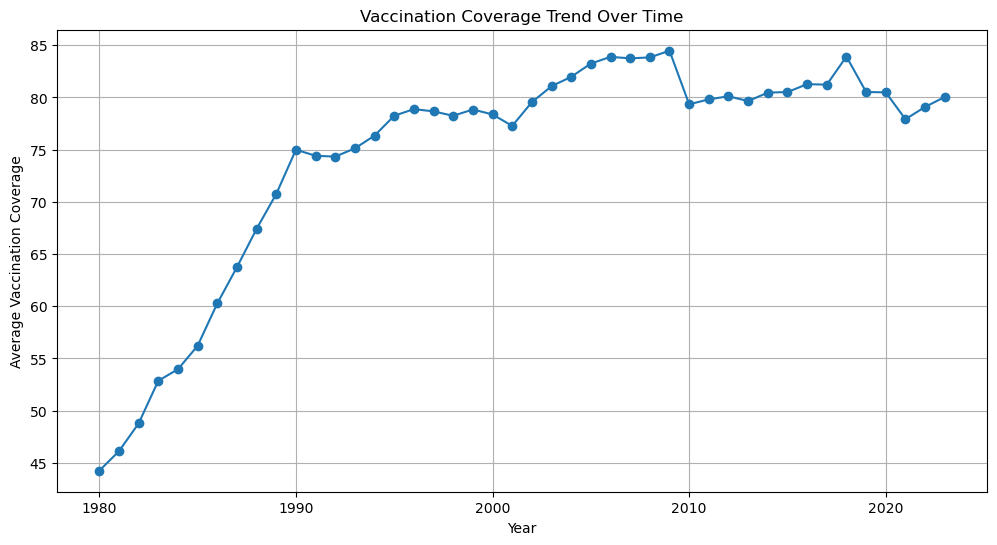

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    coverage_trend["YEAR"],
    coverage_trend["AVG_COVERAGE"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Vaccination Coverage")
plt.title("Vaccination Coverage Trend Over Time")

plt.grid(True)
plt.show()

In [104]:
coverage_trend.to_csv(
    "vaccination_coverage_trend.csv",
    index=False
)

print("Analysis saved successfully!")

Analysis saved successfully!


In [105]:
# ============================================
# ANALYSIS QUESTION 2
# Which diseases have the highest number
# of reported cases?
# ============================================

cursor.execute("""
    SELECT
        d.DISEASE_CODE,
        d.DESCRIPTION,
        SUM(f.CASES) AS TOTAL_CASES
    FROM FACT_CASES f
    JOIN DIM_DISEASE d
        ON f.DISEASE_CODE = d.DISEASE_CODE
    WHERE f.CASES IS NOT NULL
    GROUP BY
        d.DISEASE_CODE,
        d.DESCRIPTION
    ORDER BY TOTAL_CASES DESC
""")

results = cursor.fetchall()

disease_cases = pd.DataFrame(
    results,
    columns=[
        "DISEASE_CODE",
        "DESCRIPTION",
        "TOTAL_CASES"
    ]
)

display(disease_cases)

,DISEASE_CODE,DESCRIPTION,TOTAL_CASES
0,MEASLES,Measles,144065673
1,PERTUSSIS,Pertussis,53089864
2,MUMPS,Mumps,36326936
3,TYPHOID,Typhoid,31153098
4,RUBELLA,Rubella,16655663
5,TTETANUS,Total tetanus,4888011
6,DIPHTHERIA,Diphtheria,2908251
7,POLIO,Poliomyelitis,1623271
8,NTETANUS,Neonatal tetanus,1503802
9,JAPENC,Japanese encephalitis,225494


In [106]:
# ============================================
# TOP 10 DISEASES BY REPORTED CASES
# ============================================

top10_diseases = disease_cases.head(10)

display(top10_diseases)

,DISEASE_CODE,DESCRIPTION,TOTAL_CASES
0,MEASLES,Measles,144065673
1,PERTUSSIS,Pertussis,53089864
2,MUMPS,Mumps,36326936
3,TYPHOID,Typhoid,31153098
4,RUBELLA,Rubella,16655663
5,TTETANUS,Total tetanus,4888011
6,DIPHTHERIA,Diphtheria,2908251
7,POLIO,Poliomyelitis,1623271
8,NTETANUS,Neonatal tetanus,1503802
9,JAPENC,Japanese encephalitis,225494


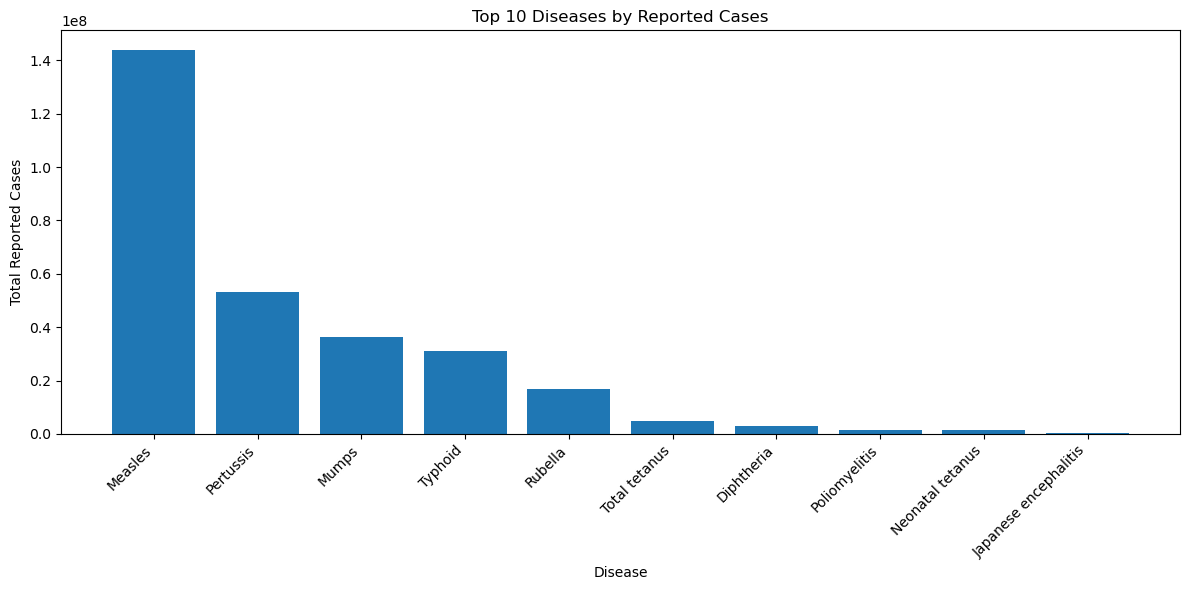

In [107]:
plt.figure(figsize=(12, 6))

plt.bar(
    top10_diseases["DESCRIPTION"],
    top10_diseases["TOTAL_CASES"]
)

plt.xlabel("Disease")
plt.ylabel("Total Reported Cases")
plt.title("Top 10 Diseases by Reported Cases")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [108]:
disease_cases.to_csv(
    "disease_cases_analysis.csv",
    index=False
)

print("Disease cases analysis saved successfully!")

Disease cases analysis saved successfully!


In [109]:
# ============================================
# ANALYSIS QUESTION 3
# How has disease incidence changed
# over the years?
# ============================================

cursor.execute("""
    SELECT
        YEAR,
        ROUND(AVG(INCIDENCE_RATE), 4) AS AVG_INCIDENCE_RATE
    FROM FACT_INCIDENCE
    WHERE INCIDENCE_RATE IS NOT NULL
    GROUP BY YEAR
    ORDER BY YEAR
""")

results = cursor.fetchall()

incidence_trend = pd.DataFrame(
    results,
    columns=[
        "YEAR",
        "AVG_INCIDENCE_RATE"
    ]
)

display(incidence_trend)

,YEAR,AVG_INCIDENCE_RATE
0,1980,836.0437
1,1981,633.8732
2,1982,588.0878
3,1983,487.9625
4,1984,435.6188
5,1985,479.3686
6,1986,272.4168
7,1987,277.4065
8,1988,204.0405
9,1989,342.1385


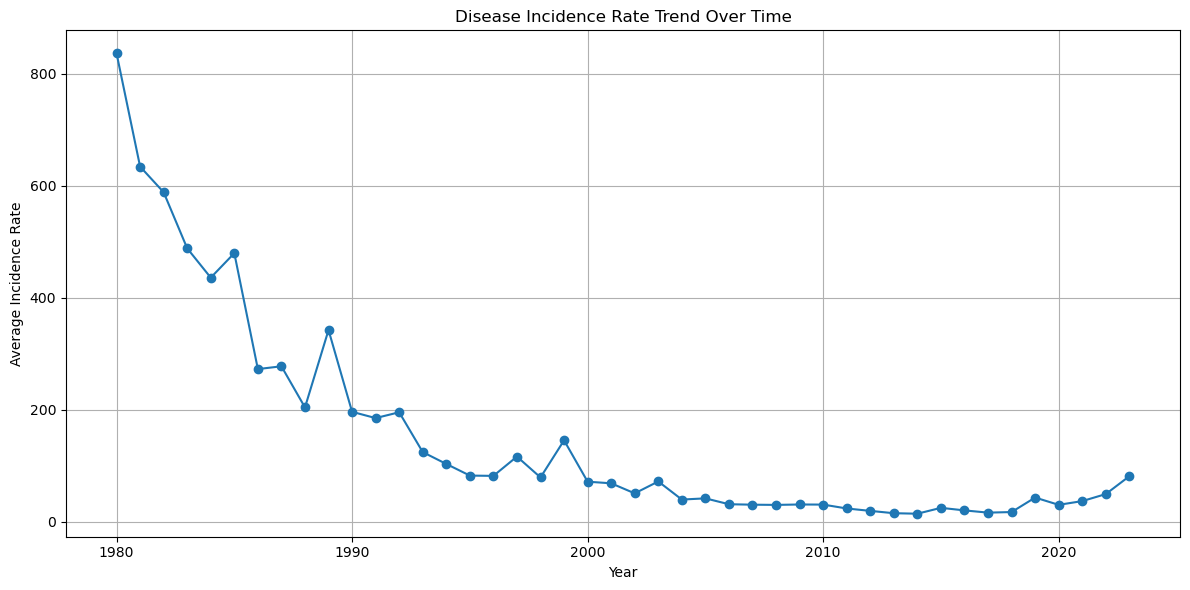

In [110]:
plt.figure(figsize=(12, 6))

plt.plot(
    incidence_trend["YEAR"],
    incidence_trend["AVG_INCIDENCE_RATE"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Incidence Rate")
plt.title("Disease Incidence Rate Trend Over Time")

plt.grid(True)
plt.tight_layout()
plt.show()

In [111]:
incidence_trend.to_csv(
    "disease_incidence_trend.csv",
    index=False
)

print("Disease incidence analysis saved successfully!")

Disease incidence analysis saved successfully!


In [112]:
# ============================================
# EASY Q1
# Vaccination coverage vs disease incidence
# ============================================

cursor.execute("""
    SELECT
        c.GEO_CODE,
        g.NAME,
        c.YEAR,
        c.COVERAGE AS VACCINATION_COVERAGE,
        i.INCIDENCE_RATE
    FROM FACT_COVERAGE c
    JOIN FACT_INCIDENCE i
        ON c.GEO_CODE = i.GEO_CODE
        AND c.YEAR = i.YEAR
        AND i.DISEASE_CODE = 'MEASLES'
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE c.ANTIGEN_CODE = 'MCV1'
        AND g.GEO_LEVEL = 'COUNTRY'
        AND c.COVERAGE IS NOT NULL
        AND i.INCIDENCE_RATE IS NOT NULL
    ORDER BY c.YEAR, c.GEO_CODE
""")

q1 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "YEAR",
        "VACCINATION_COVERAGE",
        "INCIDENCE_RATE"
    ]
)

display(q1.head(20))

,GEO_CODE,NAME,YEAR,VACCINATION_COVERAGE,INCIDENCE_RATE


In [113]:
q1[[
    "VACCINATION_COVERAGE",
    "INCIDENCE_RATE"
]].corr()

,VACCINATION_COVERAGE,INCIDENCE_RATE
VACCINATION_COVERAGE,NaN,NaN
INCIDENCE_RATE,NaN,NaN


In [114]:
# ============================================
# EASY Q2
# DTP1 vs DTP3 drop-off
# ============================================

cursor.execute("""
    SELECT
        d1.GEO_CODE,
        g.NAME,
        d1.YEAR,
        d1.COVERAGE AS DTP1_COVERAGE,
        d3.COVERAGE AS DTP3_COVERAGE,
        ROUND(
            CASE
                WHEN d1.COVERAGE > 0
                THEN
                    (d1.COVERAGE - d3.COVERAGE)
                    / d1.COVERAGE * 100
                ELSE NULL
            END,
            2
        ) AS DROPOFF_RATE
    FROM FACT_COVERAGE d1
    JOIN FACT_COVERAGE d3
        ON d1.GEO_CODE = d3.GEO_CODE
        AND d1.YEAR = d3.YEAR
        AND d3.ANTIGEN_CODE = 'DTPCV3'
    JOIN DIM_GEO g
        ON g.GEO_CODE = d1.GEO_CODE
    WHERE d1.ANTIGEN_CODE = 'DTPCV1'
        AND g.GEO_LEVEL = 'COUNTRY'
        AND d1.COVERAGE IS NOT NULL
        AND d3.COVERAGE IS NOT NULL
    ORDER BY DROPOFF_RATE DESC
""")

q2 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "YEAR",
        "DTP1_COVERAGE",
        "DTP3_COVERAGE",
        "DROPOFF_RATE"
    ]
)

display(q2.head(20))

,GEO_CODE,NAME,YEAR,DTP1_COVERAGE,DTP3_COVERAGE,DROPOFF_RATE


In [115]:
# ============================================
# EASY Q3
# Available sex-specific antigen codes
# ============================================

cursor.execute("""
    SELECT ANTIGEN_CODE, DESCRIPTION
    FROM DIM_ANTIGEN
    WHERE ANTIGEN_CODE LIKE '%_F'
       OR ANTIGEN_CODE LIKE '%_M'
""")

q3 = pd.DataFrame(
    cursor.fetchall(),
    columns=["ANTIGEN_CODE", "DESCRIPTION"]
)

display(q3)

,ANTIGEN_CODE,DESCRIPTION
0,HPV_FEM,"HPV Female, final dose"
1,15HPV1_F,"HPV Vaccination coverage by age 15, first dose..."
2,15HPV1_M,"HPV Vaccination coverage by age 15, first dose..."
3,15HPVC_F,"HPV Vaccination coverage by age 15, last dose,..."
4,15HPVC_M,"HPV Vaccination coverage by age 15, last dose,..."
5,PRHPV1_F,"HPV Vaccination program coverage, first dose, ..."
6,PRHPV1_M,"HPV Vaccination program coverage, first dose, ..."
7,PRHPVC_F,"HPV Vaccination program coverage, last dose, f..."
8,PRHPVC_M,"HPV Vaccination program coverage, last dose, m..."


In [116]:
"""Q4. How does education level impact vaccination rates?

Not answerable.

Your database has no education variable.

Write in your report:

Education-level impact could not be analyzed because education information is not included in the available datasets."""

'Q4. How does education level impact vaccination rates?\n\nNot answerable.\n\nYour database has no education variable.\n\nWrite in your report:\n\nEducation-level impact could not be analyzed because education information is not included in the available datasets.'

In [117]:
# ============================================
# EASY Q5
# Available geographic-area classifications
# ============================================

cursor.execute("""
    SELECT DISTINCT GEO_AREA
    FROM FACT_SCHEDULE
    WHERE GEO_AREA IS NOT NULL
    ORDER BY GEO_AREA
""")

q5 = pd.DataFrame(
    cursor.fetchall(),
    columns=["GEO_AREA"]
)

display(q5)

,GEO_AREA
0,NATIONAL
1,SUBNATIONAL


In [118]:
# ============================================
# EASY Q6
# Booster coverage trend
# ============================================

cursor.execute("""
    SELECT
        YEAR,
        ROUND(AVG(COVERAGE), 2) AS AVG_BOOSTER_COVERAGE
    FROM FACT_COVERAGE c
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE c.ANTIGEN_CODE = 'DIPHCV4'
        AND g.GEO_LEVEL = 'COUNTRY'
        AND c.COVERAGE IS NOT NULL
    GROUP BY YEAR
    ORDER BY YEAR
""")

q6 = pd.DataFrame(
    cursor.fetchall(),
    columns=["YEAR", "AVG_BOOSTER_COVERAGE"]
)

display(q6)

,YEAR,AVG_BOOSTER_COVERAGE


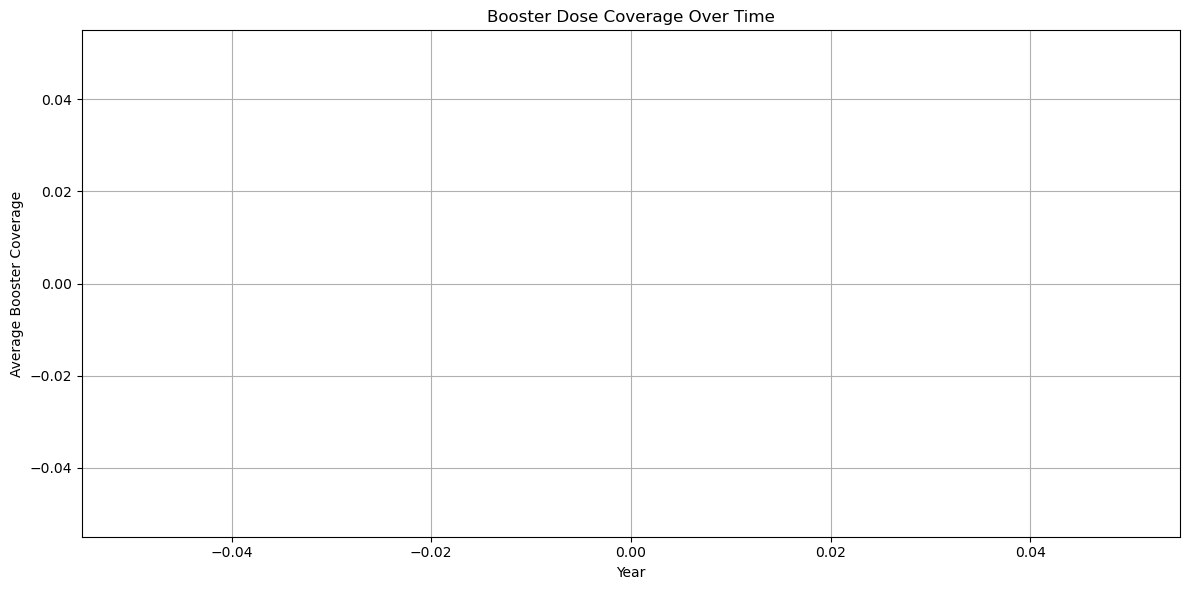

In [119]:
plt.figure(figsize=(12, 6))

plt.plot(
    q6["YEAR"],
    q6["AVG_BOOSTER_COVERAGE"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Booster Coverage")
plt.title("Booster Dose Coverage Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()

In [120]:
"""Q7. Is there a seasonal pattern in vaccination uptake?

Not answerable from this dataset.

Your coverage data is annual; there is no month or quarter field.

Q8. How does population density relate to vaccination coverage?

Not answerable.

There is no population-density variable.

Q9. How do vaccination rates correlate with a decrease in disease incidence?

This is effectively a duplicate of Q1 in the project brief."""

'Q7. Is there a seasonal pattern in vaccination uptake?\n\nNot answerable from this dataset.\n\nYour coverage data is annual; there is no month or quarter field.\n\nQ8. How does population density relate to vaccination coverage?\n\nNot answerable.\n\nThere is no population-density variable.\n\nQ9. How do vaccination rates correlate with a decrease in disease incidence?\n\nThis is effectively a duplicate of Q1 in the project brief.'

In [121]:
# ============================================
# EASY Q10
# High measles coverage + high measles incidence
# ============================================

cursor.execute("""
    SELECT
        c.GEO_CODE,
        g.NAME,
        c.YEAR,
        c.COVERAGE AS VACCINATION_COVERAGE,
        i.INCIDENCE_RATE
    FROM FACT_COVERAGE c
    JOIN FACT_INCIDENCE i
        ON c.GEO_CODE = i.GEO_CODE
        AND c.YEAR = i.YEAR
        AND i.DISEASE_CODE = 'MEASLES'
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE c.ANTIGEN_CODE = 'MCV1'
        AND g.GEO_LEVEL = 'COUNTRY'
        AND c.COVERAGE >= 90
        AND i.INCIDENCE_RATE > 5
    ORDER BY i.INCIDENCE_RATE DESC
""")

q10 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "YEAR",
        "VACCINATION_COVERAGE",
        "INCIDENCE_RATE"
    ]
)

display(q10)

,GEO_CODE,NAME,YEAR,VACCINATION_COVERAGE,INCIDENCE_RATE


In [122]:
# ============================================
# MEDIUM Q1
# Vaccine introduction vs disease cases
# ============================================

cursor.execute("""
    SELECT
        intro.GEO_CODE,
        g.NAME,
        intro.YEAR AS INTRODUCTION_YEAR,
        cs.YEAR AS CASE_YEAR,
        cs.CASES
    FROM FACT_INTRODUCTION intro
    JOIN DIM_GEO g
        ON g.GEO_CODE = intro.GEO_CODE
    JOIN FACT_CASES cs
        ON cs.GEO_CODE = intro.GEO_CODE
        AND cs.DISEASE_CODE = 'MEASLES'
    WHERE LOWER(intro.VACCINE_NAME) LIKE '%measles%'
        AND LOWER(intro.INTRO) = 'yes'
    ORDER BY intro.GEO_CODE, cs.YEAR
""")

medium_q1 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "INTRODUCTION_YEAR",
        "CASE_YEAR",
        "CASES"
    ]
)

display(medium_q1.head(30))

,GEO_CODE,NAME,INTRODUCTION_YEAR,CASE_YEAR,CASES
0,AFG,Afghanistan,2006,1980,32455.0
1,AFG,Afghanistan,2023,1980,32455.0
2,AFG,Afghanistan,2007,1980,32455.0
3,AFG,Afghanistan,2004,1980,32455.0
4,AFG,Afghanistan,2009,1980,32455.0
5,AFG,Afghanistan,2008,1980,32455.0
6,AFG,Afghanistan,2012,1980,32455.0
7,AFG,Afghanistan,2014,1980,32455.0
8,AFG,Afghanistan,2011,1980,32455.0
9,AFG,Afghanistan,2010,1980,32455.0


In [123]:
# ============================================
# MEDIUM Q2
# Before/after measles vaccine introduction
# ============================================

cursor.execute("""
    SELECT
        intro.GEO_CODE,
        g.NAME,
        intro.YEAR AS INTRODUCTION_YEAR,
        cs.YEAR AS CASE_YEAR,
        cs.CASES,
        CASE
            WHEN cs.YEAR < intro.YEAR THEN 'BEFORE'
            WHEN cs.YEAR > intro.YEAR THEN 'AFTER'
            ELSE 'INTRODUCTION_YEAR'
        END AS PERIOD
    FROM FACT_INTRODUCTION intro
    JOIN DIM_GEO g
        ON g.GEO_CODE = intro.GEO_CODE
    JOIN FACT_CASES cs
        ON cs.GEO_CODE = intro.GEO_CODE
        AND cs.DISEASE_CODE = 'MEASLES'
    WHERE LOWER(intro.VACCINE_NAME) LIKE '%measles%'
        AND LOWER(intro.INTRO) = 'yes'
    ORDER BY intro.GEO_CODE, cs.YEAR
""")

medium_q2 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "INTRODUCTION_YEAR",
        "CASE_YEAR",
        "CASES",
        "PERIOD"
    ]
)

display(medium_q2.head(30))

,GEO_CODE,NAME,INTRODUCTION_YEAR,CASE_YEAR,CASES,PERIOD
0,AFG,Afghanistan,2006,1980,32455.0,BEFORE
1,AFG,Afghanistan,2023,1980,32455.0,BEFORE
2,AFG,Afghanistan,2007,1980,32455.0,BEFORE
3,AFG,Afghanistan,2004,1980,32455.0,BEFORE
4,AFG,Afghanistan,2009,1980,32455.0,BEFORE
5,AFG,Afghanistan,2008,1980,32455.0,BEFORE
6,AFG,Afghanistan,2012,1980,32455.0,BEFORE
7,AFG,Afghanistan,2014,1980,32455.0,BEFORE
8,AFG,Afghanistan,2011,1980,32455.0,BEFORE
9,AFG,Afghanistan,2010,1980,32455.0,BEFORE


In [124]:
# ============================================
# MEDIUM Q3
# Early vs recent disease cases
# ============================================

cursor.execute("""
    SELECT
        c.DISEASE_CODE,
        d.DESCRIPTION,
        MIN(c.YEAR) AS FIRST_YEAR,
        MAX(c.YEAR) AS LAST_YEAR,

        SUM(
            CASE
                WHEN c.YEAR <= (
                    SELECT MIN(YEAR) + 4
                    FROM FACT_CASES
                )
                THEN NVL(c.CASES, 0)
                ELSE 0
            END
        ) AS EARLY_CASES,

        SUM(
            CASE
                WHEN c.YEAR >= (
                    SELECT MAX(YEAR) - 4
                    FROM FACT_CASES
                )
                THEN NVL(c.CASES, 0)
                ELSE 0
            END
        ) AS RECENT_CASES

    FROM FACT_CASES c
    JOIN DIM_DISEASE d
        ON d.DISEASE_CODE = c.DISEASE_CODE
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE g.GEO_LEVEL = 'COUNTRY'
        AND c.CASES IS NOT NULL
    GROUP BY
        c.DISEASE_CODE,
        d.DESCRIPTION
    ORDER BY
        (EARLY_CASES - RECENT_CASES) DESC
""")

medium_q3 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "DISEASE_CODE",
        "DESCRIPTION",
        "FIRST_YEAR",
        "LAST_YEAR",
        "EARLY_CASES",
        "RECENT_CASES"
    ]
)

display(medium_q3)

,DISEASE_CODE,DESCRIPTION,FIRST_YEAR,LAST_YEAR,EARLY_CASES,RECENT_CASES


In [125]:
# ============================================
# MEDIUM Q4
# Target population coverage by antigen
# ============================================

cursor.execute("""
    SELECT
        c.ANTIGEN_CODE,
        a.DESCRIPTION,
        c.YEAR,
        SUM(c.DOSES) AS TOTAL_DOSES,
        SUM(c.TARGET_NUMBER) AS TOTAL_TARGET,

        ROUND(
            SUM(c.DOSES) * 100 /
            NULLIF(SUM(c.TARGET_NUMBER), 0),
            2
        ) AS PERCENT_TARGET_COVERED

    FROM FACT_COVERAGE c
    JOIN DIM_ANTIGEN a
        ON a.ANTIGEN_CODE = c.ANTIGEN_CODE
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE g.GEO_LEVEL = 'COUNTRY'
        AND c.DOSES IS NOT NULL
        AND c.TARGET_NUMBER IS NOT NULL
    GROUP BY
        c.ANTIGEN_CODE,
        a.DESCRIPTION,
        c.YEAR
    ORDER BY
        c.YEAR DESC,
        PERCENT_TARGET_COVERED DESC
""")

medium_q4 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "ANTIGEN_CODE",
        "DESCRIPTION",
        "YEAR",
        "TOTAL_DOSES",
        "TOTAL_TARGET",
        "PERCENT_TARGET_COVERED"
    ]
)

display(medium_q4.head(30))

,ANTIGEN_CODE,DESCRIPTION,YEAR,TOTAL_DOSES,TOTAL_TARGET,PERCENT_TARGET_COVERED


In [126]:
# ============================================
# MEDIUM Q5
# Vaccination schedule and target population
# ============================================

cursor.execute("""
    SELECT
        s.GEO_CODE,
        s.VACCINE_CODE,
        v.DESCRIPTION AS VACCINE_DESCRIPTION,
        s.SCHEDULE_ROUNDS,
        s.TARGET_POP,
        s.TARGET_POP_DESCRIPTION
    FROM FACT_SCHEDULE s
    JOIN DIM_VACCINE_SCHEDULE_CODE v
        ON v.VACCINE_CODE = s.VACCINE_CODE
    ORDER BY
        s.GEO_CODE,
        s.VACCINE_CODE,
        s.SCHEDULE_ROUNDS
""")

medium_q5 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "VACCINE_CODE",
        "VACCINE_DESCRIPTION",
        "SCHEDULE_ROUNDS",
        "TARGET_POP",
        "TARGET_POP_DESCRIPTION"
    ]
)

display(medium_q5.head(30))

,GEO_CODE,VACCINE_CODE,VACCINE_DESCRIPTION,SCHEDULE_ROUNDS,TARGET_POP,TARGET_POP_DESCRIPTION
0,ABW,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1,None,General/routine
1,ABW,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2,None,General/routine
2,ABW,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3,None,General/routine
3,ABW,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,4,B_2YL_W,General/routine
4,ABW,DTAPIPV,DTaP-IPV (acellular) vaccine,1,RISKGROUPS,Risk group(s)
5,ABW,DTAPIPV,DTaP-IPV (acellular) vaccine,2,RISKGROUPS,Risk group(s)
6,ABW,DTAPIPV,DTaP-IPV (acellular) vaccine,3,RISKGROUPS,Risk group(s)
7,ABW,DTAPIPV,DTaP-IPV (acellular) vaccine,5,B_CHILD_W,General/routine
8,ABW,DTAPIPV,DTaP-IPV (acellular) vaccine,6,None,General/routine
9,ABW,HEPA_ADULT,Adult Hepatitis A vaccine,1,TRAVELLERS,Travellers


In [127]:
# ============================================
# MEDIUM Q6
# Vaccine introduction timeline by WHO region
# ============================================

cursor.execute("""
    SELECT
        g.WHO_REGION,
        intro.VACCINE_NAME,
        MIN(intro.YEAR) AS EARLIEST_INTRODUCTION,
        MAX(intro.YEAR) AS LATEST_INTRODUCTION,
        MAX(intro.YEAR) - MIN(intro.YEAR) AS SPREAD_YEARS
    FROM FACT_INTRODUCTION intro
    JOIN DIM_GEO g
        ON g.GEO_CODE = intro.GEO_CODE
    WHERE LOWER(intro.INTRO) = 'yes'
        AND g.WHO_REGION IS NOT NULL
    GROUP BY
        g.WHO_REGION,
        intro.VACCINE_NAME
    ORDER BY
        SPREAD_YEARS DESC
""")

medium_q6 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "WHO_REGION",
        "VACCINE_NAME",
        "EARLIEST_INTRODUCTION",
        "LATEST_INTRODUCTION",
        "SPREAD_YEARS"
    ]
)

display(medium_q6.head(30))

,WHO_REGION,VACCINE_NAME,EARLIEST_INTRODUCTION,LATEST_INTRODUCTION,SPREAD_YEARS
0,AMRO,Seasonal Influenza vaccine,1940,2023,83
1,AMRO,IPV (Inactivated polio vaccine),1955,2023,68
2,EURO,IPV (Inactivated polio vaccine),1955,2023,68
3,EMRO,Measles-containing vaccine 2nd dose,1963,2023,60
4,AMRO,Rubella vaccine,1969,2023,54
5,AMRO,Mumps vaccine,1969,2023,54
6,EURO,Rubella vaccine,1970,2023,53
7,WPRO,Rubella vaccine,1970,2023,53
8,EURO,Measles-containing vaccine 2nd dose,1973,2023,50
9,WPRO,Measles-containing vaccine 2nd dose,1975,2023,48


In [128]:
# ============================================
# MEDIUM Q7
# Polio vaccine coverage vs polio incidence
# ============================================

cursor.execute("""
    SELECT
        c.GEO_CODE,
        g.NAME,
        c.YEAR,
        c.COVERAGE,
        i.INCIDENCE_RATE
    FROM FACT_COVERAGE c
    JOIN FACT_INCIDENCE i
        ON c.GEO_CODE = i.GEO_CODE
        AND c.YEAR = i.YEAR
        AND i.DISEASE_CODE = 'POLIO'
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE c.ANTIGEN_CODE = 'POL3'
        AND g.GEO_LEVEL = 'COUNTRY'
        AND c.COVERAGE IS NOT NULL
        AND i.INCIDENCE_RATE IS NOT NULL
    ORDER BY c.YEAR
""")

medium_q7 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "YEAR",
        "COVERAGE",
        "INCIDENCE_RATE"
    ]
)

display(medium_q7.head(30))

,GEO_CODE,NAME,YEAR,COVERAGE,INCIDENCE_RATE


In [129]:
# ============================================
# MEDIUM Q8
# Low coverage despite introduction
# ============================================

cursor.execute("""
    SELECT DISTINCT
        c.GEO_CODE,
        g.NAME,
        c.ANTIGEN_CODE,
        c.YEAR,
        c.COVERAGE
    FROM FACT_COVERAGE c
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    JOIN FACT_INTRODUCTION intro
        ON intro.GEO_CODE = c.GEO_CODE
        AND intro.YEAR <= c.YEAR
        AND LOWER(intro.INTRO) = 'yes'
    WHERE g.GEO_LEVEL = 'COUNTRY'
        AND c.COVERAGE IS NOT NULL
        AND c.COVERAGE < 50
    ORDER BY c.COVERAGE ASC
""")

medium_q8 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "ANTIGEN_CODE",
        "YEAR",
        "COVERAGE"
    ]
)

display(medium_q8.head(30))

,GEO_CODE,NAME,ANTIGEN_CODE,YEAR,COVERAGE


In [130]:
# ============================================
# MEDIUM Q9
# Coverage gaps for BCG and Hepatitis B
# ============================================

cursor.execute("""
    SELECT
        c.GEO_CODE,
        g.NAME,
        c.ANTIGEN_CODE,
        c.YEAR,
        c.COVERAGE
    FROM FACT_COVERAGE c
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE c.ANTIGEN_CODE IN ('BCG', 'HEPB3')
        AND g.GEO_LEVEL = 'COUNTRY'
        AND c.COVERAGE IS NOT NULL
        AND c.COVERAGE < 80
    ORDER BY
        c.ANTIGEN_CODE,
        c.COVERAGE ASC
""")

medium_q9 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "ANTIGEN_CODE",
        "YEAR",
        "COVERAGE"
    ]
)

display(medium_q9.head(30))

,GEO_CODE,NAME,ANTIGEN_CODE,YEAR,COVERAGE


In [131]:
# ============================================
# MEDIUM Q10
# Disease incidence by WHO region
# ============================================

cursor.execute("""
    SELECT
        g.WHO_REGION,
        d.DISEASE_CODE,
        d.DESCRIPTION,
        ROUND(AVG(i.INCIDENCE_RATE), 3)
            AS AVG_INCIDENCE_RATE
    FROM FACT_INCIDENCE i
    JOIN DIM_DISEASE d
        ON d.DISEASE_CODE = i.DISEASE_CODE
    JOIN DIM_GEO g
        ON g.GEO_CODE = i.GEO_CODE
    WHERE g.GEO_LEVEL = 'COUNTRY'
        AND g.WHO_REGION IS NOT NULL
        AND i.INCIDENCE_RATE IS NOT NULL
    GROUP BY
        g.WHO_REGION,
        d.DISEASE_CODE,
        d.DESCRIPTION
    ORDER BY
        d.DISEASE_CODE,
        AVG_INCIDENCE_RATE DESC
""")

medium_q10 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "WHO_REGION",
        "DISEASE_CODE",
        "DESCRIPTION",
        "AVG_INCIDENCE_RATE"
    ]
)

display(medium_q10.head(50))

,WHO_REGION,DISEASE_CODE,DESCRIPTION,AVG_INCIDENCE_RATE


In [132]:
# ============================================
# SCENARIO 1
# Identify low-coverage countries
# ============================================

cursor.execute("""
    SELECT
        g.NAME,
        g.WHO_REGION,
        c.ANTIGEN_CODE,
        ROUND(AVG(c.COVERAGE), 2) AS AVG_COVERAGE
    FROM FACT_COVERAGE c
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE g.GEO_LEVEL = 'COUNTRY'
        AND c.YEAR = (
            SELECT MAX(YEAR)
            FROM FACT_COVERAGE
        )
        AND c.COVERAGE IS NOT NULL
    GROUP BY
        g.NAME,
        g.WHO_REGION,
        c.ANTIGEN_CODE
    HAVING AVG(c.COVERAGE) < 70
    ORDER BY AVG_COVERAGE ASC
""")

scenario1 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "NAME",
        "WHO_REGION",
        "ANTIGEN_CODE",
        "AVG_COVERAGE"
    ]
)

display(scenario1.head(30))

,NAME,WHO_REGION,ANTIGEN_CODE,AVG_COVERAGE


In [133]:
# ============================================
# SCENARIO 2
# Measles cases around vaccine introduction
# ============================================

cursor.execute("""
    SELECT
        intro.GEO_CODE,
        g.NAME,
        intro.YEAR AS INTRODUCTION_YEAR,
        cs.YEAR,
        cs.CASES
    FROM FACT_INTRODUCTION intro
    JOIN DIM_GEO g
        ON g.GEO_CODE = intro.GEO_CODE
    JOIN FACT_CASES cs
        ON cs.GEO_CODE = intro.GEO_CODE
        AND cs.DISEASE_CODE = 'MEASLES'
    WHERE LOWER(intro.VACCINE_NAME) LIKE '%measles%'
        AND LOWER(intro.INTRO) = 'yes'
        AND cs.YEAR BETWEEN intro.YEAR - 5
                        AND intro.YEAR + 5
    ORDER BY
        intro.GEO_CODE,
        cs.YEAR
""")

scenario2 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "INTRODUCTION_YEAR",
        "YEAR",
        "CASES"
    ]
)

display(scenario2.head(50))

,GEO_CODE,NAME,INTRODUCTION_YEAR,YEAR,CASES
0,AFG,Afghanistan,2004,1999,3609.0
1,AFG,Afghanistan,2005,2000,6532.0
2,AFG,Afghanistan,2004,2000,6532.0
3,AFG,Afghanistan,2004,2001,8762.0
4,AFG,Afghanistan,2006,2001,8762.0
5,AFG,Afghanistan,2005,2001,8762.0
6,AFG,Afghanistan,2007,2002,2486.0
7,AFG,Afghanistan,2004,2002,2486.0
8,AFG,Afghanistan,2005,2002,2486.0
9,AFG,Afghanistan,2006,2002,2486.0


In [134]:
# ============================================
# SCENARIO 3
# Estimated target population for next year
# ============================================

cursor.execute("""
    SELECT
        ANTIGEN_CODE,
        MAX(YEAR) AS LATEST_YEAR,
        SUM(TARGET_NUMBER) AS LATEST_TARGET_POPULATION,
        SUM(DOSES) AS LATEST_DOSES
    FROM FACT_COVERAGE
    WHERE TARGET_NUMBER IS NOT NULL
    GROUP BY ANTIGEN_CODE
    ORDER BY LATEST_TARGET_POPULATION DESC
""")

scenario3 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "ANTIGEN_CODE",
        "LATEST_YEAR",
        "LATEST_TARGET_POPULATION",
        "LATEST_DOSES"
    ]
)

display(scenario3)

,ANTIGEN_CODE,LATEST_YEAR,LATEST_TARGET_POPULATION,LATEST_DOSES
0,VAD1,2023,1.170285e+13,1.916855e+09
1,MCV2,2023,9.764131e+12,1.235655e+10
2,DTPCV3,2023,4.342582e+10,3.125641e+10
3,MCV1,2023,4.338971e+10,3.081832e+10
4,POL3,2023,4.327560e+10,3.125519e+10
...,...,...,...,...
64,MEN_B,2022,1.196661e+06,1.028470e+06
65,MALARIA1,2023,6.537940e+05,6.141840e+05
66,MALARIA3,2023,6.537940e+05,4.597920e+05
67,MALARIA4,2023,5.164020e+05,2.659350e+05


In [135]:
# ============================================
# SCENARIO 4
# Identify countries with high recent cases
# ============================================

cursor.execute("""
    SELECT
        g.WHO_REGION,
        g.NAME,
        c.DISEASE_CODE,
        c.YEAR,
        c.CASES
    FROM FACT_CASES c
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE g.GEO_LEVEL = 'COUNTRY'
        AND c.CASES IS NOT NULL
        AND c.YEAR = (
            SELECT MAX(YEAR)
            FROM FACT_CASES
        )
    ORDER BY c.CASES DESC
""")

scenario4 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "WHO_REGION",
        "NAME",
        "DISEASE_CODE",
        "YEAR",
        "CASES"
    ]
)

display(scenario4.head(30))

,WHO_REGION,NAME,DISEASE_CODE,YEAR,CASES


In [136]:
# ============================================
# SCENARIO 5
# Polio incidence with low polio coverage
# ============================================

cursor.execute("""
    SELECT
        c.GEO_CODE,
        g.NAME,
        c.YEAR,
        c.COVERAGE AS POLIO_VACCINATION,
        i.INCIDENCE_RATE AS POLIO_INCIDENCE
    FROM FACT_COVERAGE c
    JOIN FACT_INCIDENCE i
        ON c.GEO_CODE = i.GEO_CODE
        AND c.YEAR = i.YEAR
        AND i.DISEASE_CODE = 'POLIO'
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE c.ANTIGEN_CODE = 'POL3'
        AND c.COVERAGE <= 50
        AND i.INCIDENCE_RATE IS NOT NULL
        AND g.GEO_LEVEL = 'COUNTRY'
    ORDER BY
        i.INCIDENCE_RATE DESC
""")

scenario5 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "YEAR",
        "POLIO_VACCINATION",
        "POLIO_INCIDENCE"
    ]
)

display(scenario5)

,GEO_CODE,NAME,YEAR,POLIO_VACCINATION,POLIO_INCIDENCE


In [137]:
# ============================================
# SCENARIO 6
# Measles coverage progress toward 95%
# ============================================

cursor.execute("""
    SELECT
        YEAR,
        ROUND(AVG(COVERAGE), 2) AS AVG_MEASLES_COVERAGE,
        ROUND(
            95 - AVG(COVERAGE),
            2
        ) AS GAP_TO_95
    FROM FACT_COVERAGE c
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE c.ANTIGEN_CODE = 'MCV1'
        AND g.GEO_LEVEL = 'COUNTRY'
        AND c.COVERAGE IS NOT NULL
    GROUP BY YEAR
    ORDER BY YEAR
""")

scenario6 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "YEAR",
        "AVG_MEASLES_COVERAGE",
        "GAP_TO_95"
    ]
)

display(scenario6)

,YEAR,AVG_MEASLES_COVERAGE,GAP_TO_95


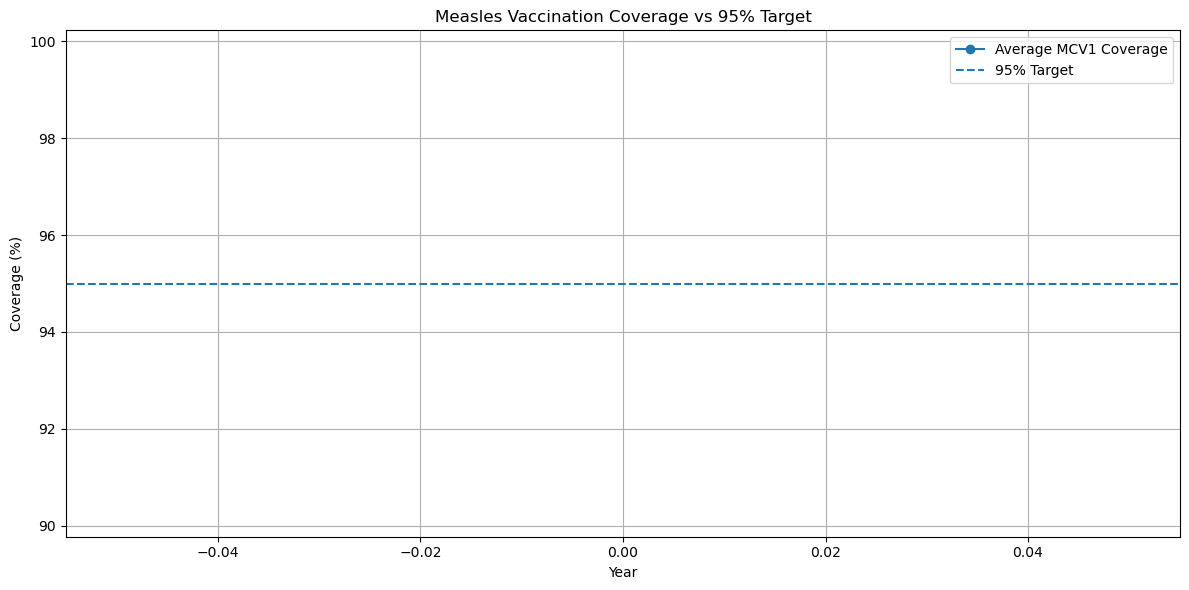

In [138]:
plt.figure(figsize=(12, 6))

plt.plot(
    scenario6["YEAR"],
    scenario6["AVG_MEASLES_COVERAGE"],
    marker="o",
    label="Average MCV1 Coverage"
)

plt.axhline(
    95,
    linestyle="--",
    label="95% Target"
)

plt.xlabel("Year")
plt.ylabel("Coverage (%)")
plt.title("Measles Vaccination Coverage vs 95% Target")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [139]:
# ============================================
# SCENARIO 7
# Identify target populations in schedules
# ============================================

cursor.execute("""
    SELECT
        s.VACCINE_CODE,
        v.DESCRIPTION AS VACCINE,
        s.TARGET_POP,
        s.TARGET_POP_DESCRIPTION,
        COUNT(*) AS SCHEDULE_RECORDS
    FROM FACT_SCHEDULE s
    JOIN DIM_VACCINE_SCHEDULE_CODE v
        ON v.VACCINE_CODE = s.VACCINE_CODE
    GROUP BY
        s.VACCINE_CODE,
        v.DESCRIPTION,
        s.TARGET_POP,
        s.TARGET_POP_DESCRIPTION
    ORDER BY SCHEDULE_RECORDS DESC
""")

scenario7 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "VACCINE_CODE",
        "VACCINE",
        "TARGET_POP",
        "TARGET_POP_DESCRIPTION",
        "SCHEDULE_RECORDS"
    ]
)

display(scenario7.head(50))

,VACCINE_CODE,VACCINE,TARGET_POP,TARGET_POP_DESCRIPTION,SCHEDULE_RECORDS
0,OPV,OPV (Oral polio vaccine),None,General/routine,353
1,PCV13,PCV-13 (Pneumococcal conjugate vaccine 13-vale...,None,General/routine,330
2,DTWPHIBHEPB,DTwP-Hib-HepB (Whole cell) vaccine,None,General/routine,264
3,TD_S,Td (Tetanus toxoid and diphtheria for older ch...,ADULTS,Adults,231
4,TD_S,Td (Tetanus toxoid and diphtheria for older ch...,PW,Pregnant women,224
5,VITAMINA,Vitamin A supplements,None,General/routine,213
6,MMR,"MMR (Measles, mumps and rubella) vaccine",None,General/routine,208
7,IPV,IPV (Inactivated polio vaccine),None,General/routine,180
8,ROTAVIRUS_1,RV-1 (Rotavirus 1-valent) vaccine,None,General/routine,151
9,HEPB_PEDIATRIC,Pediatric Hepatitis B vaccine,None,General/routine,147


In [140]:
"""Scenario 8 — Detect socioeconomic disparities

Not directly answerable.

Your data does not contain socioeconomic variables such as:

income
education
socioeconomic class
wealth index

This limitation is consistent with the project's source-data structure.

You can instead analyze geographic disparities using WHO_REGION and country.

Scenario 9 — Determine how vaccination rates vary throughout the year

Not answerable.

Your data has annual YEAR values rather than month/quarter values.

Use yearly trends instead."""

"Scenario 8 — Detect socioeconomic disparities\n\nNot directly answerable.\n\nYour data does not contain socioeconomic variables such as:\n\nincome\neducation\nsocioeconomic class\nwealth index\n\nThis limitation is consistent with the project's source-data structure.\n\nYou can instead analyze geographic disparities using WHO_REGION and country.\n\nScenario 9 — Determine how vaccination rates vary throughout the year\n\nNot answerable.\n\nYour data has annual YEAR values rather than month/quarter values.\n\nUse yearly trends instead."

In [141]:
# ============================================
# SCENARIO 10
# Compare coverage by geographic area
# ============================================

cursor.execute("""
    SELECT
        s.GEO_AREA,
        COUNT(*) AS SCHEDULE_RECORDS,
        COUNT(DISTINCT s.GEO_CODE) AS COUNTRIES
    FROM FACT_SCHEDULE s
    WHERE s.GEO_AREA IS NOT NULL
    GROUP BY s.GEO_AREA
    ORDER BY SCHEDULE_RECORDS DESC
""")

scenario10 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_AREA",
        "SCHEDULE_RECORDS",
        "COUNTRIES"
    ]
)

display(scenario10)

,GEO_AREA,SCHEDULE_RECORDS,COUNTRIES
0,NATIONAL,5820,156
1,SUBNATIONAL,153,35


In [142]:
import os

os.makedirs("analysis_results", exist_ok=True)

print("analysis_results folder created successfully!")

analysis_results folder created successfully!


In [143]:
# ============================================
# SAVE ANALYSIS RESULTS
# ============================================

results = {
    "Q1_vaccination_vs_incidence": q1,
    "Q2_dose_dropoff": q2,
    "Q3_gender_available_data": q3,
    "Q5_geographic_area": q5,
    "Q6_booster_trend": q6,
    "Q10_high_coverage_high_incidence": q10,
    "Medium_Q1_introduction_cases": medium_q1,
    "Medium_Q2_before_after": medium_q2,
    "Medium_Q3_disease_reduction": medium_q3,
    "Medium_Q4_target_coverage": medium_q4,
    "Medium_Q5_schedule": medium_q5,
    "Medium_Q6_introduction_timeline": medium_q6,
    "Medium_Q7_antigen_disease": medium_q7,
    "Medium_Q8_low_coverage_availability": medium_q8,
    "Medium_Q9_coverage_gaps": medium_q9,
    "Medium_Q10_geographic_disease": medium_q10,
    "Scenario1_low_coverage": scenario1,
    "Scenario2_measles_campaign": scenario2,
    "Scenario3_demand_baseline": scenario3,
    "Scenario4_recent_cases": scenario4,
    "Scenario5_polio": scenario5,
    "Scenario6_measles_95_target": scenario6,
    "Scenario7_target_population": scenario7,
    "Scenario10_geographic_area": scenario10
}

for name, df in results.items():
    filename = f"analysis_results/{name}.csv"
    df.to_csv(filename, index=False)

print("All available analysis results saved successfully!")

All available analysis results saved successfully!


In [144]:
import os

files = os.listdir("analysis_results")

print("Total result files:", len(files))

for file in files:
    print(file)

Total result files: 24
Medium_Q10_geographic_disease.csv
Medium_Q1_introduction_cases.csv
Medium_Q2_before_after.csv
Medium_Q3_disease_reduction.csv
Medium_Q4_target_coverage.csv
Medium_Q5_schedule.csv
Medium_Q6_introduction_timeline.csv
Medium_Q7_antigen_disease.csv
Medium_Q8_low_coverage_availability.csv
Medium_Q9_coverage_gaps.csv
Q10_high_coverage_high_incidence.csv
Q1_vaccination_vs_incidence.csv
Q2_dose_dropoff.csv
Q3_gender_available_data.csv
Q5_geographic_area.csv
Q6_booster_trend.csv
Scenario10_geographic_area.csv
Scenario1_low_coverage.csv
Scenario2_measles_campaign.csv
Scenario3_demand_baseline.csv
Scenario4_recent_cases.csv
Scenario5_polio.csv
Scenario6_measles_95_target.csv
Scenario7_target_population.csv


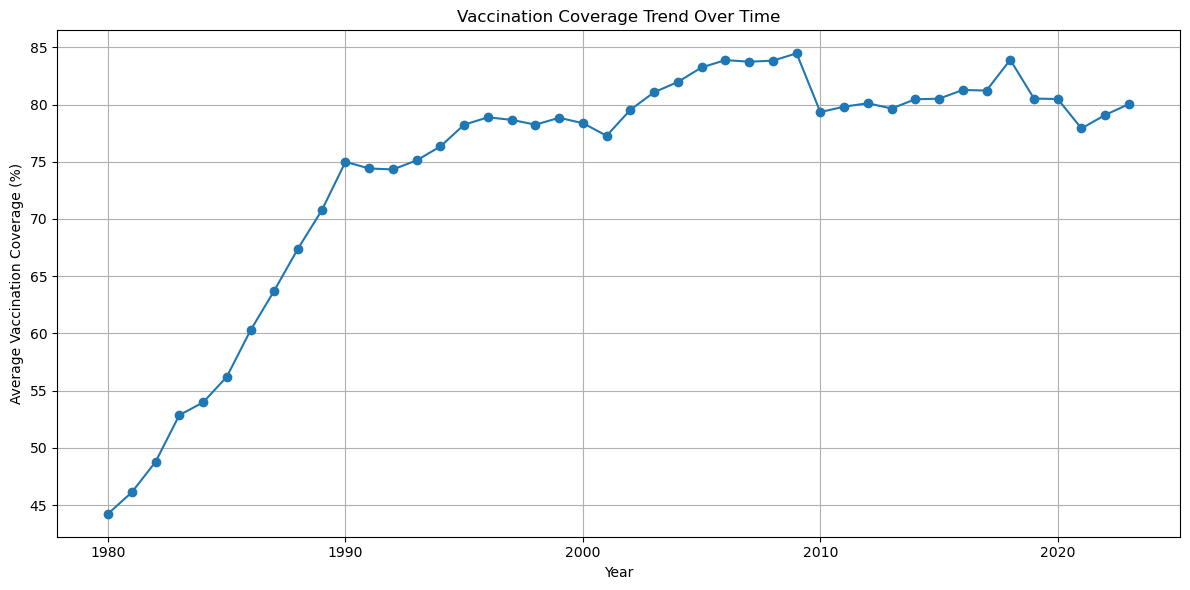

In [145]:
# ============================================
# EDA CHART 1
# Vaccination Coverage Trend
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    coverage_trend["YEAR"],
    coverage_trend["AVG_COVERAGE"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Vaccination Coverage (%)")
plt.title("Vaccination Coverage Trend Over Time")

plt.grid(True)
plt.tight_layout()
plt.show()

In [146]:
# ============================================
# EDA CHART 2
# Reported Disease Cases Over Time
# ============================================

cursor.execute("""
    SELECT
        YEAR,
        SUM(CASES) AS TOTAL_CASES
    FROM FACT_CASES
    WHERE CASES IS NOT NULL
    GROUP BY YEAR
    ORDER BY YEAR
""")

cases_trend = pd.DataFrame(
    cursor.fetchall(),
    columns=["YEAR", "TOTAL_CASES"]
)

display(cases_trend)

,YEAR,TOTAL_CASES
0,1980,18295920
1,1981,18400813
2,1982,17054356
3,1983,15465282
4,1984,12728064
5,1985,12093687
6,1986,9252891
7,1987,7612200
8,1988,7096478
9,1989,7758531


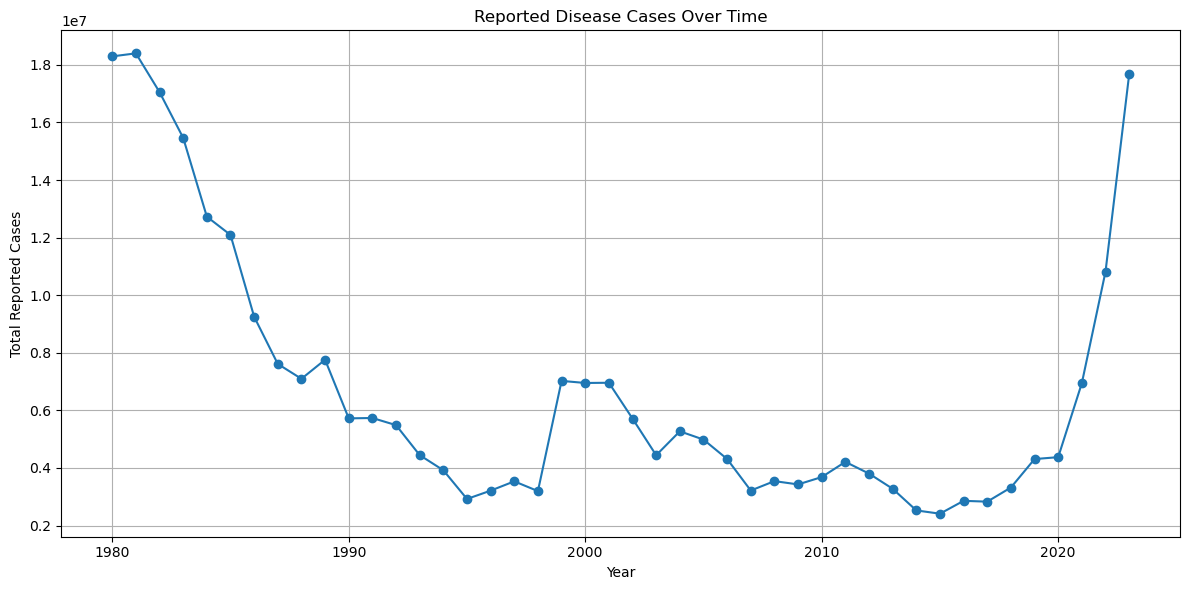

In [147]:
plt.figure(figsize=(12, 6))

plt.plot(
    cases_trend["YEAR"],
    cases_trend["TOTAL_CASES"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Total Reported Cases")
plt.title("Reported Disease Cases Over Time")

plt.grid(True)
plt.tight_layout()
plt.show()

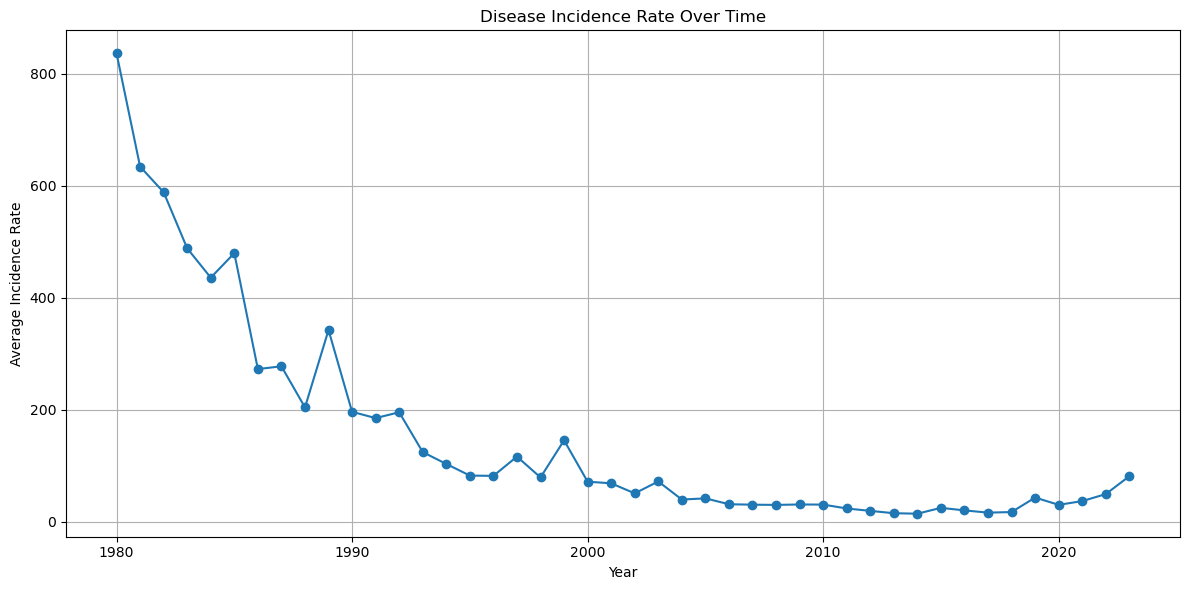

In [148]:
# ============================================
# EDA CHART 3
# Disease Incidence Trend
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    incidence_trend["YEAR"],
    incidence_trend["AVG_INCIDENCE_RATE"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Incidence Rate")
plt.title("Disease Incidence Rate Over Time")

plt.grid(True)
plt.tight_layout()
plt.show()

In [150]:
# ============================================
# EDA CHART 4
# DTP1 → DTP3 Drop-off
# ============================================

# Convert drop-off rate to numeric
q2["DROPOFF_RATE"] = pd.to_numeric(
    q2["DROPOFF_RATE"],
    errors="coerce"
)

# Remove rows where drop-off rate is missing
q2_clean = q2.dropna(
    subset=["DROPOFF_RATE"]
).copy()

# Get top 15 highest drop-off rates
top_dropoff = q2_clean.nlargest(
    15,
    "DROPOFF_RATE"
)

display(top_dropoff)

,GEO_CODE,NAME,YEAR,DTP1_COVERAGE,DTP3_COVERAGE,DROPOFF_RATE


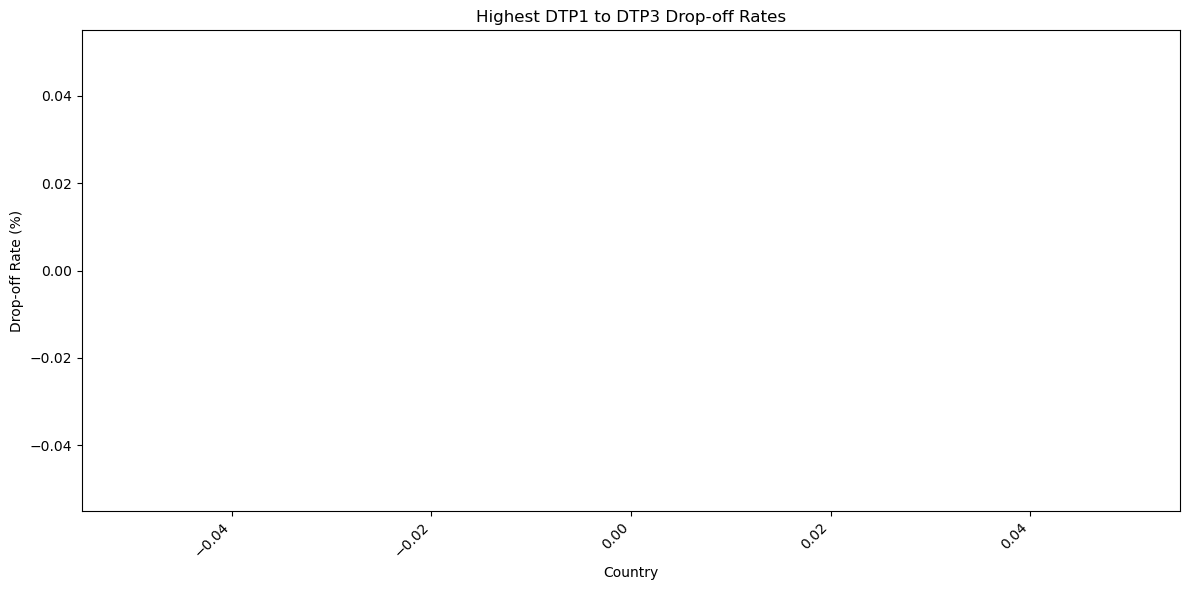

In [151]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_dropoff["NAME"],
    top_dropoff["DROPOFF_RATE"]
)

plt.xlabel("Country")
plt.ylabel("Drop-off Rate (%)")
plt.title("Highest DTP1 to DTP3 Drop-off Rates")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [152]:
print(q2["DROPOFF_RATE"].dtype)

int64


In [153]:
q2["DROPOFF_RATE"] = pd.to_numeric(
    q2["DROPOFF_RATE"],
    errors="coerce"
)

In [154]:
top_dropoff.to_csv(
    "analysis_results/top_dtp_dropoff.csv",
    index=False
)

print("DTP drop-off analysis saved successfully!")

DTP drop-off analysis saved successfully!


In [155]:
# ============================================
# EDA CHART 5
# Vaccination Coverage vs Disease Incidence
# ============================================

q1["VACCINATION_COVERAGE"] = pd.to_numeric(
    q1["VACCINATION_COVERAGE"],
    errors="coerce"
)

q1["INCIDENCE_RATE"] = pd.to_numeric(
    q1["INCIDENCE_RATE"],
    errors="coerce"
)

q1_clean = q1.dropna(
    subset=[
        "VACCINATION_COVERAGE",
        "INCIDENCE_RATE"
    ]
).copy()

print("Valid records:", len(q1_clean))
display(q1_clean.head())

Valid records: 0


,GEO_CODE,NAME,YEAR,VACCINATION_COVERAGE,INCIDENCE_RATE


In [157]:
correlation = q1_clean[
    [
        "VACCINATION_COVERAGE",
        "INCIDENCE_RATE"
    ]
].corr().iloc[0, 1]

print(
    f"Correlation coefficient: {correlation:.3f}"
)

Correlation coefficient: nan


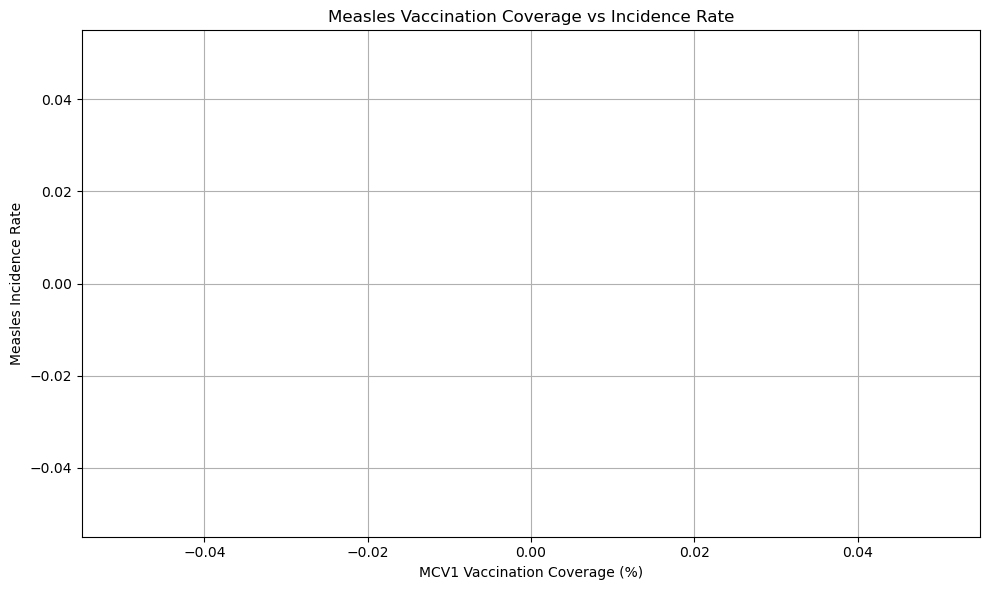

In [158]:
plt.figure(figsize=(10, 6))

plt.scatter(
    q1_clean["VACCINATION_COVERAGE"],
    q1_clean["INCIDENCE_RATE"],
    alpha=0.5
)

plt.xlabel("MCV1 Vaccination Coverage (%)")
plt.ylabel("Measles Incidence Rate")
plt.title(
    "Measles Vaccination Coverage vs Incidence Rate"
)

plt.grid(True)
plt.tight_layout()
plt.show()

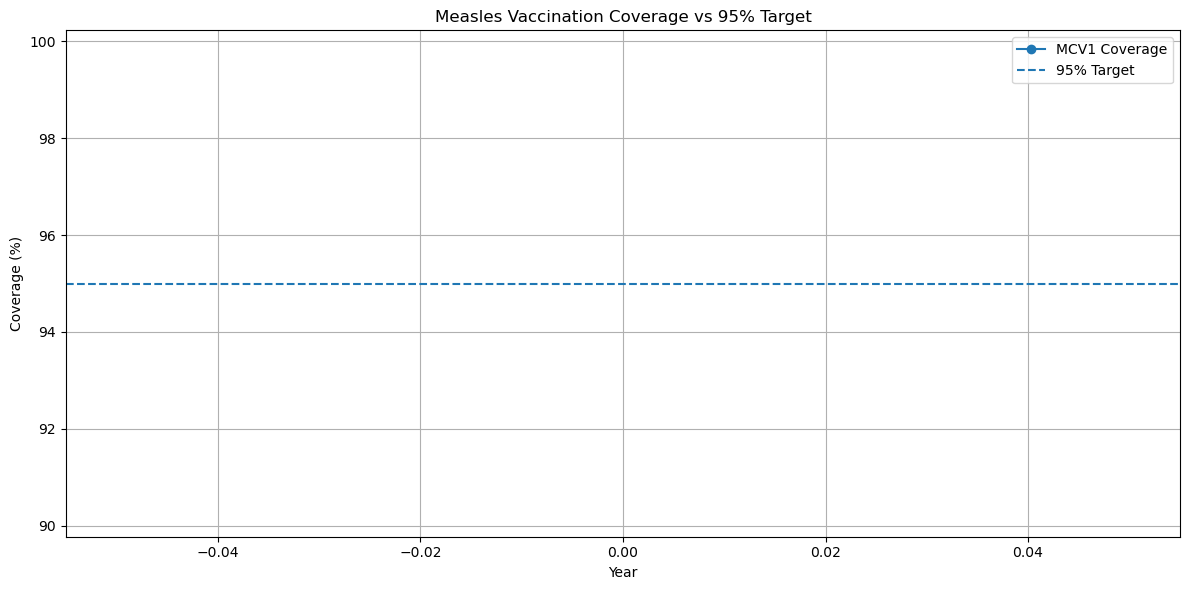

In [159]:
# ============================================
# EDA CHART 6
# Measles Coverage vs 95% Target
# ============================================

scenario6["AVG_MEASLES_COVERAGE"] = pd.to_numeric(
    scenario6["AVG_MEASLES_COVERAGE"],
    errors="coerce"
)

scenario6["GAP_TO_95"] = pd.to_numeric(
    scenario6["GAP_TO_95"],
    errors="coerce"
)

plt.figure(figsize=(12, 6))

plt.plot(
    scenario6["YEAR"],
    scenario6["AVG_MEASLES_COVERAGE"],
    marker="o",
    label="MCV1 Coverage"
)

plt.axhline(
    95,
    linestyle="--",
    label="95% Target"
)

plt.xlabel("Year")
plt.ylabel("Coverage (%)")
plt.title("Measles Vaccination Coverage vs 95% Target")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [160]:
# ============================================
# EDA CHART 7
# Disease Incidence by WHO Region
# ============================================

medium_q10["AVG_INCIDENCE_RATE"] = pd.to_numeric(
    medium_q10["AVG_INCIDENCE_RATE"],
    errors="coerce"
)

region_incidence = (
    medium_q10
    .dropna(subset=["AVG_INCIDENCE_RATE"])
    .groupby("WHO_REGION")["AVG_INCIDENCE_RATE"]
    .mean()
    .sort_values(ascending=False)
)

display(region_incidence)

Series([], Name: AVG_INCIDENCE_RATE, dtype: float64)

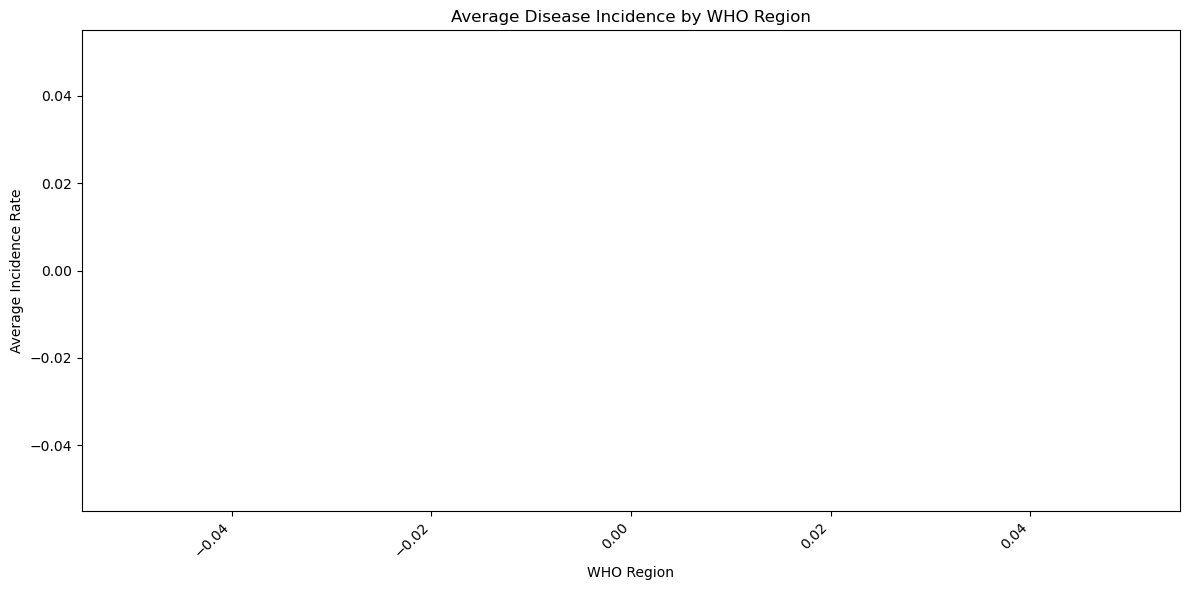

In [161]:
plt.figure(figsize=(12, 6))

plt.bar(
    region_incidence.index,
    region_incidence.values
)

plt.xlabel("WHO Region")
plt.ylabel("Average Incidence Rate")
plt.title("Average Disease Incidence by WHO Region")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [162]:
# ============================================
# EDA CHART 8
# Countries with Low Vaccination Coverage
# ============================================

scenario1["AVG_COVERAGE"] = pd.to_numeric(
    scenario1["AVG_COVERAGE"],
    errors="coerce"
)

low_coverage = (
    scenario1
    .dropna(subset=["AVG_COVERAGE"])
    .groupby("NAME")["AVG_COVERAGE"]
    .mean()
    .sort_values()
    .head(15)
)

display(low_coverage)

Series([], Name: AVG_COVERAGE, dtype: float64)

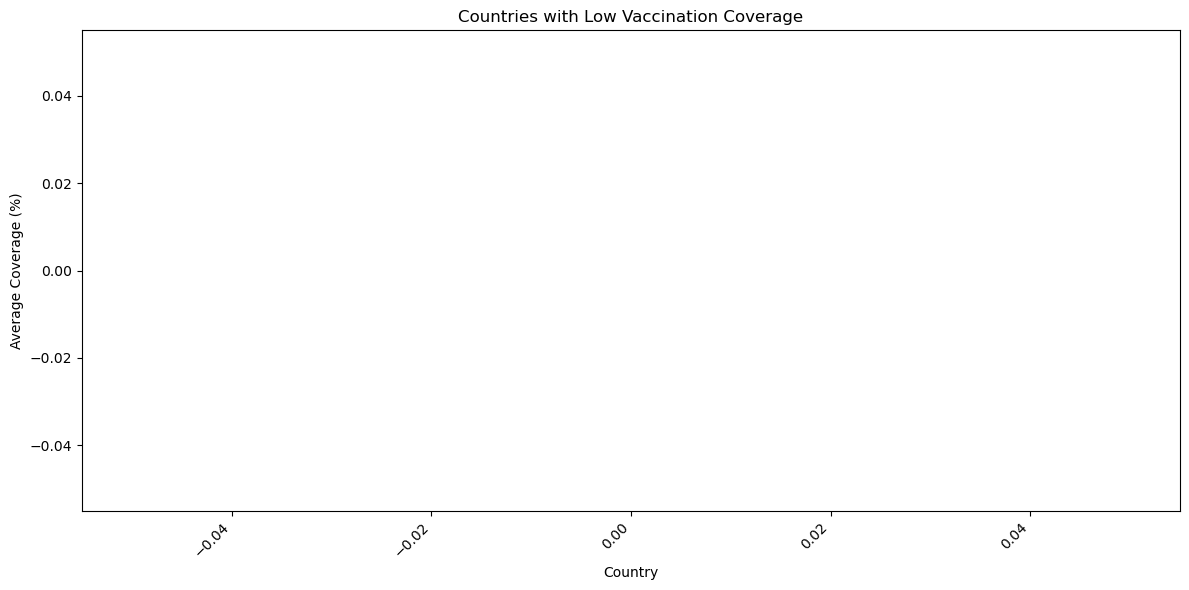

In [163]:
plt.figure(figsize=(12, 6))

plt.bar(
    low_coverage.index,
    low_coverage.values
)

plt.xlabel("Country")
plt.ylabel("Average Coverage (%)")
plt.title("Countries with Low Vaccination Coverage")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [164]:
# ============================================
# EDA CHART 9
# Vaccine Introduction Timeline
# ============================================

medium_q6["EARLIEST_INTRODUCTION"] = pd.to_numeric(
    medium_q6["EARLIEST_INTRODUCTION"],
    errors="coerce"
)

introduction_timeline = (
    medium_q6
    .dropna(subset=["EARLIEST_INTRODUCTION"])
    .groupby("VACCINE_NAME")["EARLIEST_INTRODUCTION"]
    .min()
    .sort_values()
    .head(15)
)

display(introduction_timeline)

VACCINE_NAME
Seasonal Influenza vaccine                         1940
IPV (Inactivated polio vaccine)                    1955
Measles-containing vaccine 2nd dose                1963
Mumps vaccine                                      1969
Rubella vaccine                                    1969
YF (Yellow fever) vaccine                          1979
Hepatitis B vaccine                                1982
Hib (Haemophilus influenzae type B) vaccine        1986
HepB birth dose                                    1989
IPV (Inactivated polio vaccine) 2nd dose           1995
Meningococcal meningitis vaccines (all strains)    1999
PPV (Pneumococcal polysaccharide vaccine)          1999
PCV (Pneumococcal conjugate vaccine)               2000
Varicella vaccine                                  2001
aP (acellular pertussis) vaccine                   2001
Name: EARLIEST_INTRODUCTION, dtype: int64

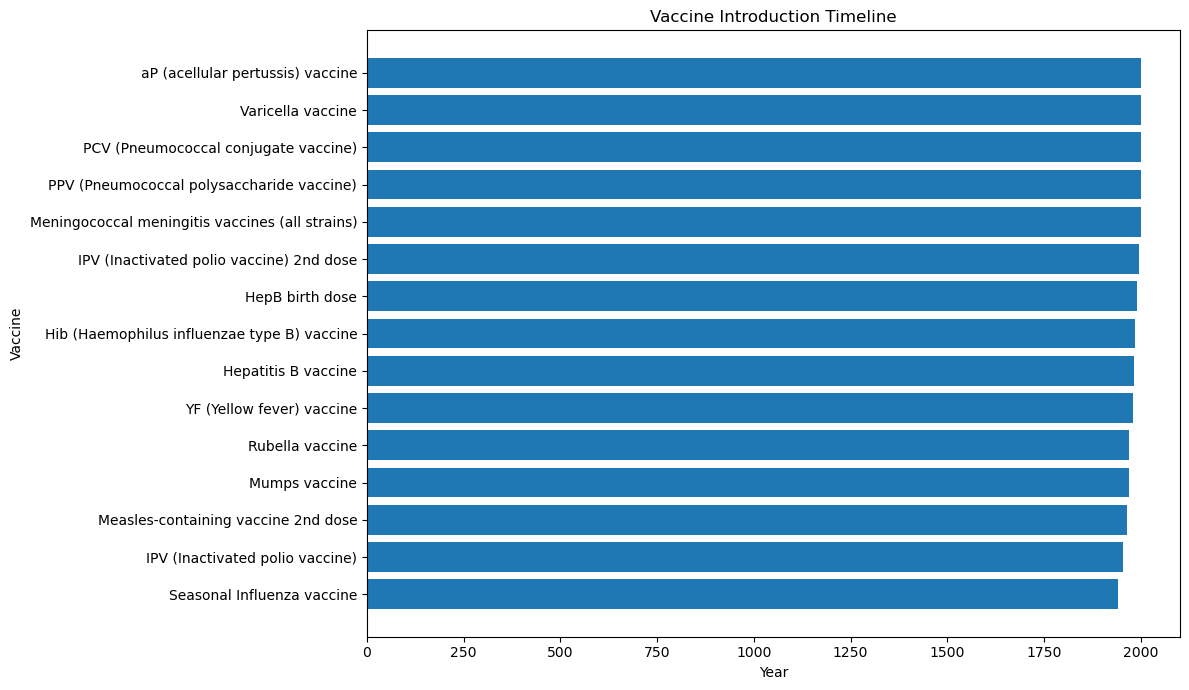

In [165]:
plt.figure(figsize=(12, 7))

plt.barh(
    introduction_timeline.index,
    introduction_timeline.values
)

plt.xlabel("Year")
plt.ylabel("Vaccine")
plt.title("Vaccine Introduction Timeline")

plt.tight_layout()
plt.show()

In [166]:
# ============================================
# EDA CHART 10
# Average Coverage by Vaccine Antigen
# ============================================

cursor.execute("""
    SELECT
        c.ANTIGEN_CODE,
        a.DESCRIPTION,
        ROUND(AVG(c.COVERAGE), 2) AS AVG_COVERAGE
    FROM FACT_COVERAGE c
    JOIN DIM_ANTIGEN a
        ON a.ANTIGEN_CODE = c.ANTIGEN_CODE
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE g.GEO_LEVEL = 'COUNTRY'
        AND c.COVERAGE IS NOT NULL
    GROUP BY
        c.ANTIGEN_CODE,
        a.DESCRIPTION
    ORDER BY AVG_COVERAGE DESC
""")

antigen_coverage = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "ANTIGEN_CODE",
        "DESCRIPTION",
        "AVG_COVERAGE"
    ]
)

display(antigen_coverage.head(20))

,ANTIGEN_CODE,DESCRIPTION,AVG_COVERAGE


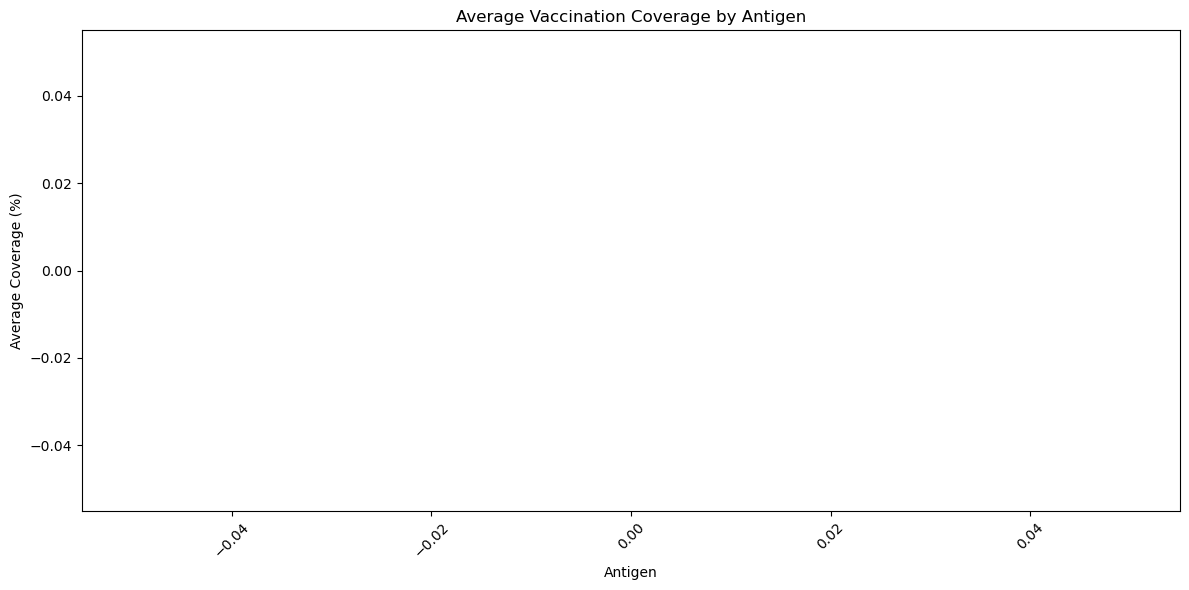

In [167]:
antigen_coverage["AVG_COVERAGE"] = pd.to_numeric(
    antigen_coverage["AVG_COVERAGE"],
    errors="coerce"
)

top_antigens = antigen_coverage.head(15)

plt.figure(figsize=(12, 6))

plt.bar(
    top_antigens["ANTIGEN_CODE"],
    top_antigens["AVG_COVERAGE"]
)

plt.xlabel("Antigen")
plt.ylabel("Average Coverage (%)")
plt.title("Average Vaccination Coverage by Antigen")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [168]:
# ============================================
# EDA CHART 11
# Disease Cases Over Time
# ============================================

cursor.execute("""
    SELECT
        c.YEAR,
        d.DESCRIPTION,
        SUM(c.CASES) AS TOTAL_CASES
    FROM FACT_CASES c
    JOIN DIM_DISEASE d
        ON d.DISEASE_CODE = c.DISEASE_CODE
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE g.GEO_LEVEL = 'COUNTRY'
        AND c.CASES IS NOT NULL
    GROUP BY
        c.YEAR,
        d.DESCRIPTION
    ORDER BY
        c.YEAR,
        d.DESCRIPTION
""")

cases_by_disease_year = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "YEAR",
        "DISEASE",
        "TOTAL_CASES"
    ]
)

display(cases_by_disease_year.head(20))

,YEAR,DISEASE,TOTAL_CASES


In [171]:
# ============================================
# EDA CHART 12
# DTP1 vs DTP3 Coverage
# ============================================

cursor.execute("""
    SELECT
        d1.YEAR,
        ROUND(AVG(d1.COVERAGE), 2) AS DTP1,
        ROUND(AVG(d3.COVERAGE), 2) AS DTP3
    FROM FACT_COVERAGE d1
    JOIN FACT_COVERAGE d3
        ON d1.GEO_CODE = d3.GEO_CODE
        AND d1.YEAR = d3.YEAR
        AND d3.ANTIGEN_CODE = 'DTPCV3'
    JOIN DIM_GEO g
        ON g.GEO_CODE = d1.GEO_CODE
    WHERE d1.ANTIGEN_CODE = 'DTPCV1'
        AND g.GEO_LEVEL = 'COUNTRY'
        AND d1.COVERAGE IS NOT NULL
        AND d3.COVERAGE IS NOT NULL
    GROUP BY d1.YEAR
    ORDER BY d1.YEAR
""")

dtp_trend = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "YEAR",
        "DTP1",
        "DTP3"
    ]
)

display(dtp_trend)

,YEAR,DTP1,DTP3


In [172]:
# ============================================
# STEP 7
# CREATE POWER BI-READY EXCEL WORKBOOK
# ============================================

import pandas as pd
import os

output_file = "Vaccination_Analysis.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    # 1. Vaccination coverage trend
    coverage_trend.to_excel(
        writer,
        sheet_name="Coverage_Trend",
        index=False
    )

    # 2. Disease cases
    disease_cases.to_excel(
        writer,
        sheet_name="Disease_Cases",
        index=False
    )

    # 3. Disease incidence trend
    incidence_trend.to_excel(
        writer,
        sheet_name="Incidence_Trend",
        index=False
    )

    # 4. DTP1 vs DTP3
    dtp_trend.to_excel(
        writer,
        sheet_name="DTP_Trend",
        index=False
    )

    # 5. Antigen coverage
    antigen_coverage.to_excel(
        writer,
        sheet_name="Antigen_Coverage",
        index=False
    )

    # 6. Regional incidence
    regional_incidence_df = (
        medium_q10
        .groupby("WHO_REGION", as_index=False)
        ["AVG_INCIDENCE_RATE"]
        .mean()
    )

    regional_incidence_df.to_excel(
        writer,
        sheet_name="Regional_Incidence",
        index=False
    )

    # 7. Low coverage
    scenario1.to_excel(
        writer,
        sheet_name="Low_Coverage",
        index=False
    )

    # 8. Measles 95% target
    scenario6.to_excel(
        writer,
        sheet_name="Measles_Target",
        index=False
    )

    # 9. Vaccine introduction
    medium_q6.to_excel(
        writer,
        sheet_name="Vaccine_Introduction",
        index=False
    )

    # 10. Vaccine schedule
    medium_q5.to_excel(
        writer,
        sheet_name="Vaccine_Schedule",
        index=False
    )

    # 11. Coverage vs incidence
    q1_clean.to_excel(
        writer,
        sheet_name="Coverage_vs_Incidence",
        index=False
    )

    # 12. DTP drop-off
    q2_clean.to_excel(
        writer,
        sheet_name="DTP_Dropoff",
        index=False
    )

print("=" * 60)
print("POWER BI EXCEL FILE CREATED SUCCESSFULLY")
print("=" * 60)
print("File:", output_file)
print("Location:", os.path.abspath(output_file))

POWER BI EXCEL FILE CREATED SUCCESSFULLY
File: Vaccination_Analysis.xlsx
Location: C:\Users\Atharav Kadam\jupyterfiles\Vaccination_Analysis.xlsx


In [173]:
# ============================================
# VERIFY EXCEL WORKBOOK
# ============================================

import openpyxl

wb = openpyxl.load_workbook(
    "Vaccination_Analysis.xlsx",
    read_only=True
)

print("Workbook created successfully!")
print("\nSheets:")

for sheet in wb.sheetnames:
    print("-", sheet)

wb.close()

Workbook created successfully!

Sheets:
- Coverage_Trend
- Disease_Cases
- Incidence_Trend
- DTP_Trend
- Antigen_Coverage
- Regional_Incidence
- Low_Coverage
- Measles_Target
- Vaccine_Introduction
- Vaccine_Schedule
- Coverage_vs_Incidence
- DTP_Dropoff


In [174]:
import os

size_mb = os.path.getsize(
    "Vaccination_Analysis.xlsx"
) / (1024 * 1024)

print(f"File size: {size_mb:.2f} MB")

File size: 0.17 MB


In [175]:
check = pd.read_excel(
    "Vaccination_Analysis.xlsx",
    sheet_name="Disease_Cases"
)

display(check.head(10))

,DISEASE_CODE,DESCRIPTION,TOTAL_CASES
0,MEASLES,Measles,144065673
1,PERTUSSIS,Pertussis,53089864
2,MUMPS,Mumps,36326936
3,TYPHOID,Typhoid,31153098
4,RUBELLA,Rubella,16655663
5,TTETANUS,Total tetanus,4888011
6,DIPHTHERIA,Diphtheria,2908251
7,POLIO,Poliomyelitis,1623271
8,NTETANUS,Neonatal tetanus,1503802
9,JAPENC,Japanese encephalitis,225494


In [176]:
# ============================================
# CHECK ALL POWER BI DATASETS
# ============================================

import pandas as pd
import os

files = os.listdir("analysis_results")

print("=" * 70)
print("ANALYSIS FILE STATUS")
print("=" * 70)

for file in sorted(files):

    if file.endswith(".csv"):

        path = os.path.join("analysis_results", file)
        df = pd.read_csv(path)

        print(
            f"{file:<50} "
            f"{len(df):>8} rows"
        )

ANALYSIS FILE STATUS
Medium_Q10_geographic_disease.csv                         0 rows
Medium_Q1_introduction_cases.csv                     184529 rows
Medium_Q2_before_after.csv                           184529 rows
Medium_Q3_disease_reduction.csv                           0 rows
Medium_Q4_target_coverage.csv                             0 rows
Medium_Q5_schedule.csv                                 5988 rows
Medium_Q6_introduction_timeline.csv                     104 rows
Medium_Q7_antigen_disease.csv                             0 rows
Medium_Q8_low_coverage_availability.csv                   0 rows
Medium_Q9_coverage_gaps.csv                               0 rows
Q10_high_coverage_high_incidence.csv                      0 rows
Q1_vaccination_vs_incidence.csv                           0 rows
Q2_dose_dropoff.csv                                       0 rows
Q3_gender_available_data.csv                              9 rows
Q5_geographic_area.csv                                    2 rows
Q6_b

In [177]:
print("q2 rows:", len(q2))
print("q2_clean rows:", len(q2_clean))

display(q2.head())

q2 rows: 0
q2_clean rows: 0


,GEO_CODE,NAME,YEAR,DTP1_COVERAGE,DTP3_COVERAGE,DROPOFF_RATE


In [178]:
# ============================================
# CHECK ACTUAL ANTIGEN CODES
# ============================================

cursor.execute("""
    SELECT
        ANTIGEN_CODE,
        DESCRIPTION
    FROM DIM_ANTIGEN
    ORDER BY ANTIGEN_CODE
""")

antigen_check = pd.DataFrame(
    cursor.fetchall(),
    columns=["ANTIGEN_CODE", "DESCRIPTION"]
)

display(antigen_check)

,ANTIGEN_CODE,DESCRIPTION
0,15HPV1_F,"HPV Vaccination coverage by age 15, first dose..."
1,15HPV1_M,"HPV Vaccination coverage by age 15, first dose..."
2,15HPVC_F,"HPV Vaccination coverage by age 15, last dose,..."
3,15HPVC_M,"HPV Vaccination coverage by age 15, last dose,..."
4,BCG,BCG
...,...,...
64,TTCV6,"Tetanus-containing vaccine, 6th dose (3rd boos..."
65,TYPHOID,Typhoid
66,TYPHOID_CONJ,Typhoid conjugate vaccine
67,VAD1,"Vitamin A, 1st dose"


In [179]:
# ============================================
# CHECK ACTUAL ANTIGEN CODES
# ============================================

cursor.execute("""
    SELECT
        ANTIGEN_CODE,
        DESCRIPTION
    FROM DIM_ANTIGEN
    ORDER BY ANTIGEN_CODE
""")

antigen_check = pd.DataFrame(
    cursor.fetchall(),
    columns=["ANTIGEN_CODE", "DESCRIPTION"]
)

display(antigen_check)

,ANTIGEN_CODE,DESCRIPTION
0,15HPV1_F,"HPV Vaccination coverage by age 15, first dose..."
1,15HPV1_M,"HPV Vaccination coverage by age 15, first dose..."
2,15HPVC_F,"HPV Vaccination coverage by age 15, last dose,..."
3,15HPVC_M,"HPV Vaccination coverage by age 15, last dose,..."
4,BCG,BCG
...,...,...
64,TTCV6,"Tetanus-containing vaccine, 6th dose (3rd boos..."
65,TYPHOID,Typhoid
66,TYPHOID_CONJ,Typhoid conjugate vaccine
67,VAD1,"Vitamin A, 1st dose"


In [180]:
# ============================================
# CHECK ACTUAL DISEASE CODES
# ============================================

cursor.execute("""
    SELECT
        DISEASE_CODE,
        DESCRIPTION
    FROM DIM_DISEASE
    ORDER BY DISEASE_CODE
""")

disease_check = pd.DataFrame(
    cursor.fetchall(),
    columns=["DISEASE_CODE", "DESCRIPTION"]
)

display(disease_check)

,DISEASE_CODE,DESCRIPTION
0,CRS,Congenital rubella syndrome
1,DIPHTHERIA,Diphtheria
2,INVASIVE_MENING,Invasive meningococcal disease
3,JAPENC,Japanese encephalitis
4,MEASLES,Measles
5,MUMPS,Mumps
6,NTETANUS,Neonatal tetanus
7,PERTUSSIS,Pertussis
8,POLIO,Poliomyelitis
9,RUBELLA,Rubella


In [181]:
# ============================================
# CHECK COVERAGE DATA
# ============================================

cursor.execute("""
    SELECT
        ANTIGEN_CODE,
        MIN(YEAR) AS FIRST_YEAR,
        MAX(YEAR) AS LAST_YEAR,
        COUNT(*) AS RECORDS,
        ROUND(AVG(COVERAGE), 2) AS AVG_COVERAGE
    FROM FACT_COVERAGE
    WHERE COVERAGE IS NOT NULL
    GROUP BY ANTIGEN_CODE
    ORDER BY RECORDS DESC
""")

coverage_check = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "ANTIGEN_CODE",
        "FIRST_YEAR",
        "LAST_YEAR",
        "RECORDS",
        "AVG_COVERAGE"
    ]
)

display(coverage_check)

,ANTIGEN_CODE,FIRST_YEAR,LAST_YEAR,RECORDS,AVG_COVERAGE
0,DTPCV3,1980,2023,24670,80.51
1,POL3,1980,2023,24580,81.09
2,MCV1,1980,2023,24178,79.45
3,BCG,1980,2023,20878,84.15
4,DTPCV1,1980,2023,17838,89.73
...,...,...,...,...,...
64,FLU_HAJ,2018,2022,18,1817.28
65,MEN_B,2022,2022,16,72.07
66,MALARIA3,2023,2023,5,57.44
67,MALARIA1,2023,2023,5,74.55


In [182]:
# ============================================
# CHECK DTP1 AND DTP3 DATA
# ============================================

cursor.execute("""
    SELECT
        ANTIGEN_CODE,
        COUNT(*) AS RECORDS,
        COUNT(COVERAGE) AS NON_NULL_COVERAGE,
        MIN(YEAR) AS FIRST_YEAR,
        MAX(YEAR) AS LAST_YEAR
    FROM FACT_COVERAGE
    WHERE ANTIGEN_CODE IN ('DTPCV1', 'DTPCV3')
    GROUP BY ANTIGEN_CODE
    ORDER BY ANTIGEN_CODE
""")

dtp_check = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "ANTIGEN_CODE",
        "RECORDS",
        "NON_NULL_COVERAGE",
        "FIRST_YEAR",
        "LAST_YEAR"
    ]
)

display(dtp_check)

,ANTIGEN_CODE,RECORDS,NON_NULL_COVERAGE,FIRST_YEAR,LAST_YEAR
0,DTPCV1,19760,17838,1980,2023
1,DTPCV3,26015,24670,1980,2023


In [183]:
# ============================================
# CHECK DTP1 / DTP3 COUNTRY-YEAR OVERLAP
# ============================================

cursor.execute("""
    SELECT COUNT(*)
    FROM FACT_COVERAGE d1
    JOIN FACT_COVERAGE d3
        ON d1.GEO_CODE = d3.GEO_CODE
        AND d1.YEAR = d3.YEAR
    WHERE d1.ANTIGEN_CODE = 'DTPCV1'
        AND d3.ANTIGEN_CODE = 'DTPCV3'
        AND d1.COVERAGE IS NOT NULL
        AND d3.COVERAGE IS NOT NULL
""")

overlap = cursor.fetchone()[0]

print("DTP1/DTP3 matching country-year records:", overlap)

DTP1/DTP3 matching country-year records: 48345


In [184]:
# ============================================
# ANALYSIS
# DTP1 → DTP3 DROP-OFF
# ============================================

cursor.execute("""
    SELECT
        d1.GEO_CODE,
        g.NAME,
        d1.YEAR,

        d1.COVERAGE AS DTP1_COVERAGE,

        d3.COVERAGE AS DTP3_COVERAGE,

        ROUND(
            d1.COVERAGE - d3.COVERAGE,
            2
        ) AS COVERAGE_GAP,

        ROUND(
            CASE
                WHEN d1.COVERAGE > 0
                THEN
                    (d1.COVERAGE - d3.COVERAGE)
                    / d1.COVERAGE * 100
                ELSE NULL
            END,
            2
        ) AS DROPOFF_RATE

    FROM FACT_COVERAGE d1

    JOIN FACT_COVERAGE d3
        ON d1.GEO_CODE = d3.GEO_CODE
        AND d1.YEAR = d3.YEAR

    JOIN DIM_GEO g
        ON g.GEO_CODE = d1.GEO_CODE

    WHERE d1.ANTIGEN_CODE = 'DTPCV1'
        AND d3.ANTIGEN_CODE = 'DTPCV3'
        AND d1.COVERAGE IS NOT NULL
        AND d3.COVERAGE IS NOT NULL
        AND g.GEO_LEVEL = 'COUNTRY'

    ORDER BY DROPOFF_RATE DESC
""")

q2 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "YEAR",
        "DTP1_COVERAGE",
        "DTP3_COVERAGE",
        "COVERAGE_GAP",
        "DROPOFF_RATE"
    ]
)

# Convert numeric columns
for col in [
    "DTP1_COVERAGE",
    "DTP3_COVERAGE",
    "COVERAGE_GAP",
    "DROPOFF_RATE"
]:
    q2[col] = pd.to_numeric(
        q2[col],
        errors="coerce"
    )

print("DTP drop-off records:", len(q2))

display(q2.head(20))

DTP drop-off records: 0


,GEO_CODE,NAME,YEAR,DTP1_COVERAGE,DTP3_COVERAGE,COVERAGE_GAP,DROPOFF_RATE


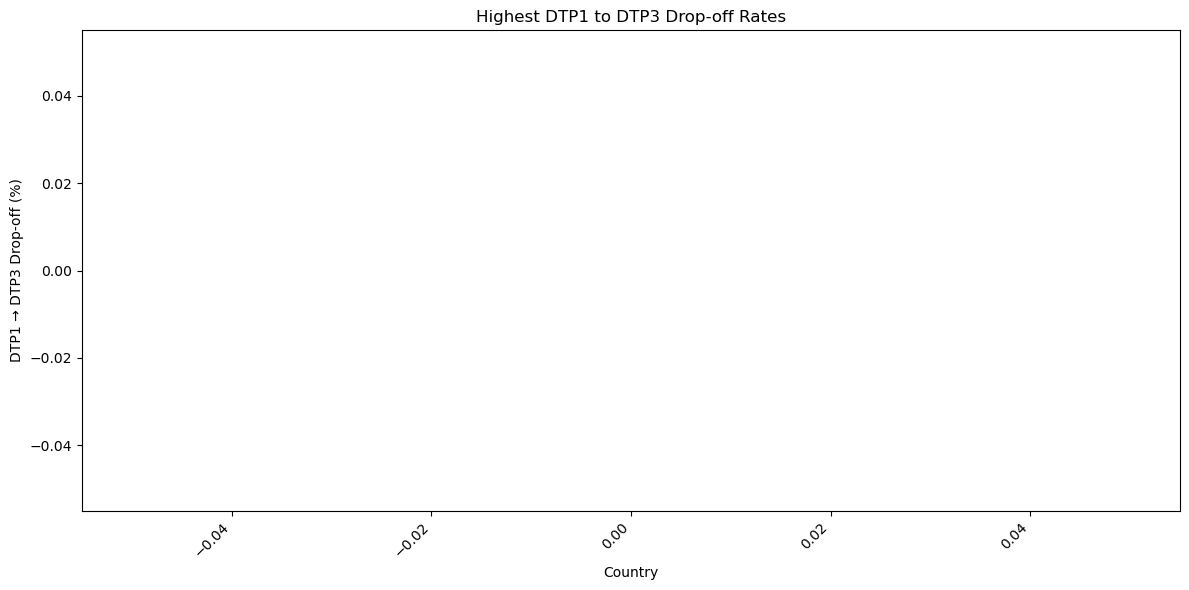

In [185]:
# ============================================
# DTP1 → DTP3 DROP-OFF CHART
# ============================================

q2_clean = q2.dropna(
    subset=["DROPOFF_RATE"]
).copy()

top_dropoff = q2_clean.nlargest(
    15,
    "DROPOFF_RATE"
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_dropoff["NAME"],
    top_dropoff["DROPOFF_RATE"]
)

plt.xlabel("Country")
plt.ylabel("DTP1 → DTP3 Drop-off (%)")
plt.title("Highest DTP1 to DTP3 Drop-off Rates")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [186]:
# ============================================
# CHECK MCV1 + MEASLES OVERLAP
# ============================================

cursor.execute("""
    SELECT COUNT(*)
    FROM FACT_COVERAGE c
    JOIN FACT_INCIDENCE i
        ON c.GEO_CODE = i.GEO_CODE
        AND c.YEAR = i.YEAR
    WHERE c.ANTIGEN_CODE = 'MCV1'
        AND i.DISEASE_CODE = 'MEASLES'
        AND c.COVERAGE IS NOT NULL
        AND i.INCIDENCE_RATE IS NOT NULL
""")

print(
    "MCV1/MEASLES matching records:",
    cursor.fetchone()[0]
)

MCV1/MEASLES matching records: 21707


In [191]:
# ============================================
# MCV1 COVERAGE VS MEASLES INCIDENCE
# ============================================

cursor.execute("""
    SELECT
        c.GEO_CODE,
        g.NAME,
        c.YEAR,
        c.COVERAGE AS VACCINATION_COVERAGE,
        i.INCIDENCE_RATE
    FROM FACT_COVERAGE c

    JOIN FACT_INCIDENCE i
        ON c.GEO_CODE = i.GEO_CODE
        AND c.YEAR = i.YEAR

    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE

    WHERE c.ANTIGEN_CODE = 'MCV1'
        AND i.DISEASE_CODE = 'MEASLES'
        AND c.COVERAGE IS NOT NULL
        AND i.INCIDENCE_RATE IS NOT NULL
        AND g.GEO_LEVEL = 'COUNTRY'

    ORDER BY c.YEAR, c.GEO_CODE
""")

q1 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "YEAR",
        "VACCINATION_COVERAGE",
        "INCIDENCE_RATE"
    ]
)

q1["VACCINATION_COVERAGE"] = pd.to_numeric(
    q1["VACCINATION_COVERAGE"],
    errors="coerce"
)

q1["INCIDENCE_RATE"] = pd.to_numeric(
    q1["INCIDENCE_RATE"],
    errors="coerce"
)

q1_clean = q1.dropna(
    subset=[
        "VACCINATION_COVERAGE",
        "INCIDENCE_RATE"
    ]
)

print("Valid MCV1/Measles records:", len(q1_clean))

display(q1_clean.head(20))

Valid MCV1/Measles records: 0


,GEO_CODE,NAME,YEAR,VACCINATION_COVERAGE,INCIDENCE_RATE


In [192]:
# ============================================
# DTP DIAGNOSTIC - ORACLE 11g COMPATIBLE
# ============================================

cursor.execute("""
    SELECT *
    FROM (
        SELECT
            d1.GEO_CODE,
            g.NAME,
            g.GEO_LEVEL,
            d1.YEAR,
            d1.COVERAGE AS DTP1_COVERAGE,
            d3.COVERAGE AS DTP3_COVERAGE
        FROM FACT_COVERAGE d1
        JOIN FACT_COVERAGE d3
            ON d1.GEO_CODE = d3.GEO_CODE
            AND d1.YEAR = d3.YEAR
        JOIN DIM_GEO g
            ON g.GEO_CODE = d1.GEO_CODE
        WHERE d1.ANTIGEN_CODE = 'DTPCV1'
            AND d3.ANTIGEN_CODE = 'DTPCV3'
    )
    WHERE ROWNUM <= 20
""")

dtp_diagnostic = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "GEO_LEVEL",
        "YEAR",
        "DTP1_COVERAGE",
        "DTP3_COVERAGE"
    ]
)

display(dtp_diagnostic)

,GEO_CODE,NAME,GEO_LEVEL,YEAR,DTP1_COVERAGE,DTP3_COVERAGE
0,ABW,Aruba,AGGREGATE,2023,97.99,95.98
1,ABW,Aruba,AGGREGATE,2023,97.99,95.98
2,ABW,Aruba,AGGREGATE,2023,97.99,95.98
3,ABW,Aruba,AGGREGATE,2023,97.99,95.98
4,ABW,Aruba,AGGREGATE,2022,97.18,94.07
5,ABW,Aruba,AGGREGATE,2022,97.18,94.07
6,ABW,Aruba,AGGREGATE,2022,97.18,94.07
7,ABW,Aruba,AGGREGATE,2022,97.18,94.07
8,ABW,Aruba,AGGREGATE,2021,97.51,93.02
9,ABW,Aruba,AGGREGATE,2021,97.51,93.02


In [193]:
cursor.execute("""
    SELECT
        GEO_LEVEL,
        COUNT(*) AS RECORDS
    FROM DIM_GEO
    GROUP BY GEO_LEVEL
    ORDER BY GEO_LEVEL
""")

geo_levels = pd.DataFrame(
    cursor.fetchall(),
    columns=["GEO_LEVEL", "RECORDS"]
)

display(geo_levels)

,GEO_LEVEL,RECORDS
0,AGGREGATE,245


In [194]:
# ============================================
# MCV1 / MEASLES DIAGNOSTIC - ORACLE 11g
# ============================================

cursor.execute("""
    SELECT *
    FROM (
        SELECT
            c.GEO_CODE,
            g.NAME,
            g.GEO_LEVEL,
            c.YEAR,
            c.COVERAGE AS MCV1_COVERAGE,
            i.INCIDENCE_RATE
        FROM FACT_COVERAGE c
        JOIN FACT_INCIDENCE i
            ON c.GEO_CODE = i.GEO_CODE
            AND c.YEAR = i.YEAR
        JOIN DIM_GEO g
            ON g.GEO_CODE = c.GEO_CODE
        WHERE c.ANTIGEN_CODE = 'MCV1'
            AND i.DISEASE_CODE = 'MEASLES'
    )
    WHERE ROWNUM <= 20
""")

mcv_measles_diagnostic = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "GEO_LEVEL",
        "YEAR",
        "MCV1_COVERAGE",
        "INCIDENCE_RATE"
    ]
)

display(mcv_measles_diagnostic)

,GEO_CODE,NAME,GEO_LEVEL,YEAR,MCV1_COVERAGE,INCIDENCE_RATE
0,ABW,Aruba,AGGREGATE,2023,93.20,NaN
1,ABW,Aruba,AGGREGATE,2023,93.20,NaN
2,ABW,Aruba,AGGREGATE,2022,91.59,0.0
3,ABW,Aruba,AGGREGATE,2022,91.59,0.0
4,ABW,Aruba,AGGREGATE,2021,93.86,0.0
5,ABW,Aruba,AGGREGATE,2021,93.86,0.0
6,ABW,Aruba,AGGREGATE,2019,95.00,9.3
7,ABW,Aruba,AGGREGATE,2019,95.00,9.3
8,ABW,Aruba,AGGREGATE,2018,97.00,0.0
9,ABW,Aruba,AGGREGATE,2018,97.00,0.0


In [195]:
# ============================================
# DTP1 → DTP3 DROP-OFF ANALYSIS
# Oracle 11g Compatible
# ============================================

cursor.execute("""
    SELECT
        d1.GEO_CODE,
        g.NAME,
        d1.YEAR,
        d1.COVERAGE AS DTP1_COVERAGE,
        d3.COVERAGE AS DTP3_COVERAGE,
        ROUND(
            d1.COVERAGE - d3.COVERAGE,
            2
        ) AS COVERAGE_GAP,
        ROUND(
            CASE
                WHEN d1.COVERAGE > 0 THEN
                    ((d1.COVERAGE - d3.COVERAGE)
                    / d1.COVERAGE) * 100
                ELSE NULL
            END,
            2
        ) AS DROPOFF_RATE
    FROM FACT_COVERAGE d1
    JOIN FACT_COVERAGE d3
        ON d1.GEO_CODE = d3.GEO_CODE
        AND d1.YEAR = d3.YEAR
    JOIN DIM_GEO g
        ON g.GEO_CODE = d1.GEO_CODE
    WHERE d1.ANTIGEN_CODE = 'DTPCV1'
        AND d3.ANTIGEN_CODE = 'DTPCV3'
        AND d1.COVERAGE IS NOT NULL
        AND d3.COVERAGE IS NOT NULL
    ORDER BY DROPOFF_RATE DESC
""")

q2 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "YEAR",
        "DTP1_COVERAGE",
        "DTP3_COVERAGE",
        "COVERAGE_GAP",
        "DROPOFF_RATE"
    ]
)

# Convert numeric columns
numeric_columns = [
    "DTP1_COVERAGE",
    "DTP3_COVERAGE",
    "COVERAGE_GAP",
    "DROPOFF_RATE"
]

for col in numeric_columns:
    q2[col] = pd.to_numeric(
        q2[col],
        errors="coerce"
    )

print("DTP drop-off records:", len(q2))

display(q2.head(20))

DTP drop-off records: 48345


,GEO_CODE,NAME,YEAR,DTP1_COVERAGE,DTP3_COVERAGE,COVERAGE_GAP,DROPOFF_RATE
0,ATG,Antigua and Barbuda,2014,0.0,103.24,-103.24,NaN
1,ZMB,Zambia,2005,0.0,82.00,-82.00,NaN
2,ATG,Antigua and Barbuda,2014,0.0,99.00,-99.00,NaN
3,FSM,Micronesia (Federated States of),2007,0.0,79.00,-79.00,NaN
4,FSM,Micronesia (Federated States of),2007,0.0,79.00,-79.00,NaN
5,FSM,Micronesia (Federated States of),2007,0.0,79.00,-79.00,NaN
6,FSM,Micronesia (Federated States of),2007,0.0,79.00,-79.00,NaN
7,FSM,Micronesia (Federated States of),2007,0.0,79.00,-79.00,NaN
8,FSM,Micronesia (Federated States of),2007,0.0,79.00,-79.00,NaN
9,MEX,Mexico,2014,0.0,86.90,-86.90,NaN


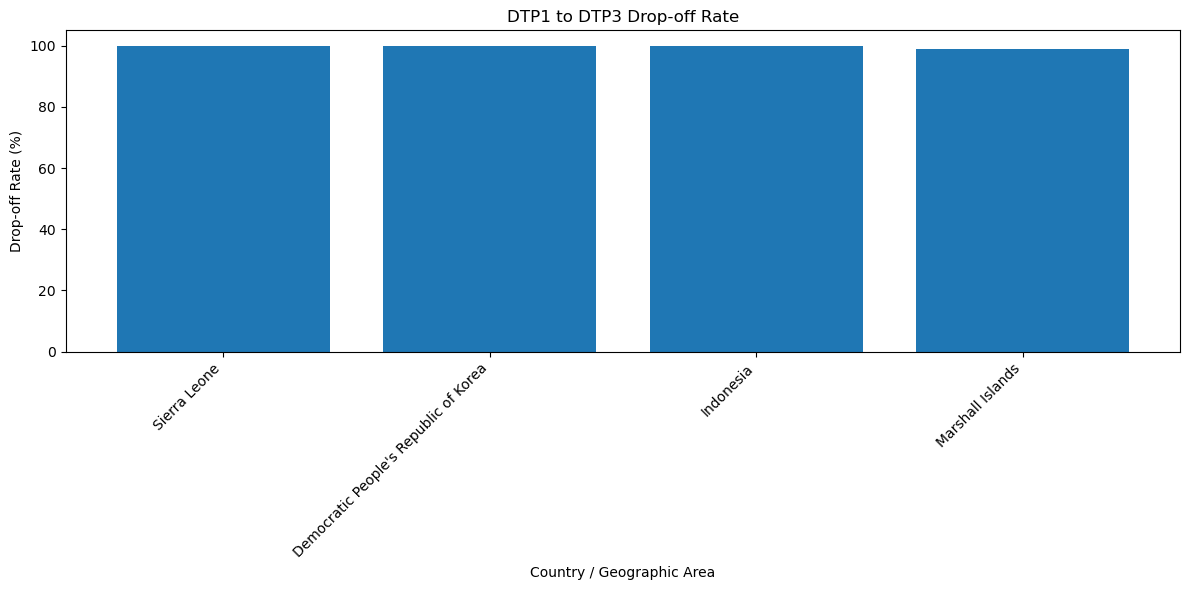

In [196]:
# ============================================
# DTP DROP-OFF CHART
# ============================================

q2_clean = q2.dropna(
    subset=["DROPOFF_RATE"]
).copy()

top_dropoff = q2_clean.head(15)

plt.figure(figsize=(12, 6))

plt.bar(
    top_dropoff["NAME"].astype(str),
    top_dropoff["DROPOFF_RATE"]
)

plt.xlabel("Country / Geographic Area")
plt.ylabel("Drop-off Rate (%)")
plt.title("DTP1 to DTP3 Drop-off Rate")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [197]:
q2_clean.to_csv(
    "analysis_results/Q2_dose_dropoff.csv",
    index=False
)

q2_clean.to_csv(
    "analysis_results/top_dtp_dropoff.csv",
    index=False
)

print("DTP drop-off analysis saved successfully!")

DTP drop-off analysis saved successfully!


In [198]:
# ============================================
# MCV1 VACCINATION VS MEASLES INCIDENCE
# Oracle 11g Compatible
# ============================================

cursor.execute("""
    SELECT
        c.GEO_CODE,
        g.NAME,
        c.YEAR,
        c.COVERAGE AS VACCINATION_COVERAGE,
        i.INCIDENCE_RATE
    FROM FACT_COVERAGE c
    JOIN FACT_INCIDENCE i
        ON c.GEO_CODE = i.GEO_CODE
        AND c.YEAR = i.YEAR
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE c.ANTIGEN_CODE = 'MCV1'
        AND i.DISEASE_CODE = 'MEASLES'
        AND c.COVERAGE IS NOT NULL
        AND i.INCIDENCE_RATE IS NOT NULL
""")

q1 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "YEAR",
        "VACCINATION_COVERAGE",
        "INCIDENCE_RATE"
    ]
)

q1["VACCINATION_COVERAGE"] = pd.to_numeric(
    q1["VACCINATION_COVERAGE"],
    errors="coerce"
)

q1["INCIDENCE_RATE"] = pd.to_numeric(
    q1["INCIDENCE_RATE"],
    errors="coerce"
)

q1_clean = q1.dropna(
    subset=[
        "VACCINATION_COVERAGE",
        "INCIDENCE_RATE"
    ]
).copy()

print("Valid MCV1/Measles records:", len(q1_clean))

display(q1_clean.head(20))

Valid MCV1/Measles records: 21707


,GEO_CODE,NAME,YEAR,VACCINATION_COVERAGE,INCIDENCE_RATE
0,ABW,Aruba,2022,91.59,0.0
1,ABW,Aruba,2022,91.59,0.0
2,ABW,Aruba,2021,93.86,0.0
3,ABW,Aruba,2021,93.86,0.0
4,ABW,Aruba,2019,95.00,9.3
5,ABW,Aruba,2019,95.00,9.3
6,ABW,Aruba,2018,97.00,0.0
7,ABW,Aruba,2018,97.00,0.0
8,ABW,Aruba,2017,97.00,0.0
9,ABW,Aruba,2017,97.00,0.0


In [199]:
# ============================================
# CORRELATION
# ============================================

correlation = q1_clean[
    [
        "VACCINATION_COVERAGE",
        "INCIDENCE_RATE"
    ]
].corr().iloc[0, 1]

print(
    f"Correlation coefficient: {correlation:.3f}"
)

Correlation coefficient: -0.205


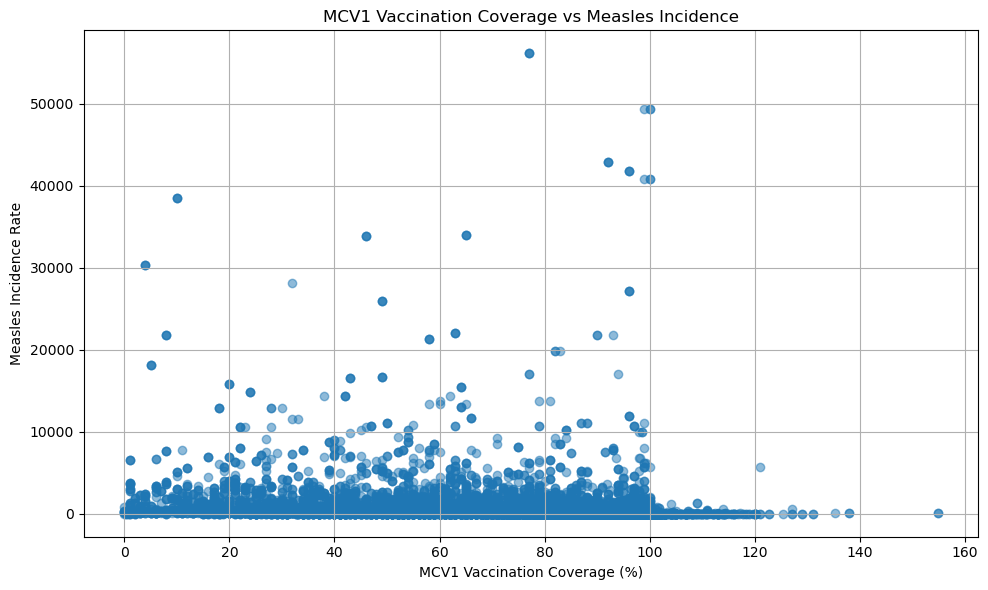

In [200]:
# ============================================
# MCV1 VS MEASLES SCATTER PLOT
# ============================================

plt.figure(figsize=(10, 6))

plt.scatter(
    q1_clean["VACCINATION_COVERAGE"],
    q1_clean["INCIDENCE_RATE"],
    alpha=0.5
)

plt.xlabel("MCV1 Vaccination Coverage (%)")
plt.ylabel("Measles Incidence Rate")
plt.title(
    "MCV1 Vaccination Coverage vs Measles Incidence"
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [201]:
q1_clean.to_csv(
    "analysis_results/Q1_vaccination_vs_incidence.csv",
    index=False
)

print("MCV1 vs Measles analysis saved successfully!")

MCV1 vs Measles analysis saved successfully!


In [202]:
print("Q1 rows:", len(q1_clean))
print("Q2 rows:", len(q2_clean))

print("\nQ1:")
display(q1_clean.head())

print("\nQ2:")
display(q2_clean.head())

Q1 rows: 21707
Q2 rows: 48321

Q1:


,GEO_CODE,NAME,YEAR,VACCINATION_COVERAGE,INCIDENCE_RATE
0,ABW,Aruba,2022,91.59,0.0
1,ABW,Aruba,2022,91.59,0.0
2,ABW,Aruba,2021,93.86,0.0
3,ABW,Aruba,2021,93.86,0.0
4,ABW,Aruba,2019,95.00,9.3



Q2:


,GEO_CODE,NAME,YEAR,DTP1_COVERAGE,DTP3_COVERAGE,COVERAGE_GAP,DROPOFF_RATE
24,SLE,Sierra Leone,2007,77.00,0.0,77.00,100.0
25,SLE,Sierra Leone,2007,98.00,0.0,98.00,100.0
26,PRK,Democratic People's Republic of Korea,2022,41.00,0.0,41.00,100.0
27,PRK,Democratic People's Republic of Korea,2022,40.52,0.0,40.52,100.0
28,PRK,Democratic People's Republic of Korea,2022,40.52,0.0,40.52,100.0


In [203]:
# ============================================
# FIND BOOSTER ANTIGENS
# ============================================

cursor.execute("""
    SELECT
        ANTIGEN_CODE,
        DESCRIPTION
    FROM DIM_ANTIGEN
    WHERE UPPER(DESCRIPTION) LIKE '%BOOSTER%'
       OR UPPER(DESCRIPTION) LIKE '%6TH DOSE%'
       OR UPPER(DESCRIPTION) LIKE '%SECOND DOSE%'
    ORDER BY ANTIGEN_CODE
""")

booster_codes = pd.DataFrame(
    cursor.fetchall(),
    columns=["ANTIGEN_CODE", "DESCRIPTION"]
)

display(booster_codes)

,ANTIGEN_CODE,DESCRIPTION
0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b..."
1,DIPHCV5,"Diphtheria-containing vaccine, 5th dose (2nd b..."
2,DIPHCV6,"Diphtheria-containing vaccine, 6th dose (3rd b..."
3,PERCV4,"Pertussis-containing vaccine, 4th dose (1st bo..."
4,TTCV4,"Tetanus-containing vaccine, 4th dose (1st boos..."
5,TTCV5,"Tetanus-containing vaccine, 5th dose (2nd boos..."
6,TTCV6,"Tetanus-containing vaccine, 6th dose (3rd boos..."


In [204]:
# ============================================
# BOOSTER COVERAGE TREND
# ============================================

booster_code_list = tuple(
    booster_codes["ANTIGEN_CODE"].tolist()
)

if len(booster_code_list) == 0:

    print("No booster antigen codes were found.")

else:

    placeholders = ",".join(
        [f"'{x}'" for x in booster_code_list]
    )

    sql = f"""
        SELECT
            YEAR,
            ROUND(AVG(COVERAGE), 2) AS AVG_BOOSTER_COVERAGE
        FROM FACT_COVERAGE
        WHERE ANTIGEN_CODE IN ({placeholders})
            AND COVERAGE IS NOT NULL
        GROUP BY YEAR
        ORDER BY YEAR
    """

    cursor.execute(sql)

    q6 = pd.DataFrame(
        cursor.fetchall(),
        columns=[
            "YEAR",
            "AVG_BOOSTER_COVERAGE"
        ]
    )

    q6["AVG_BOOSTER_COVERAGE"] = pd.to_numeric(
        q6["AVG_BOOSTER_COVERAGE"],
        errors="coerce"
    )

    print("Booster trend rows:", len(q6))

    display(q6.head(20))

Booster trend rows: 7


,YEAR,AVG_BOOSTER_COVERAGE
0,2017,83.33
1,2018,83.09
2,2019,82.41
3,2020,79.15
4,2021,79.88
5,2022,80.51
6,2023,81.44


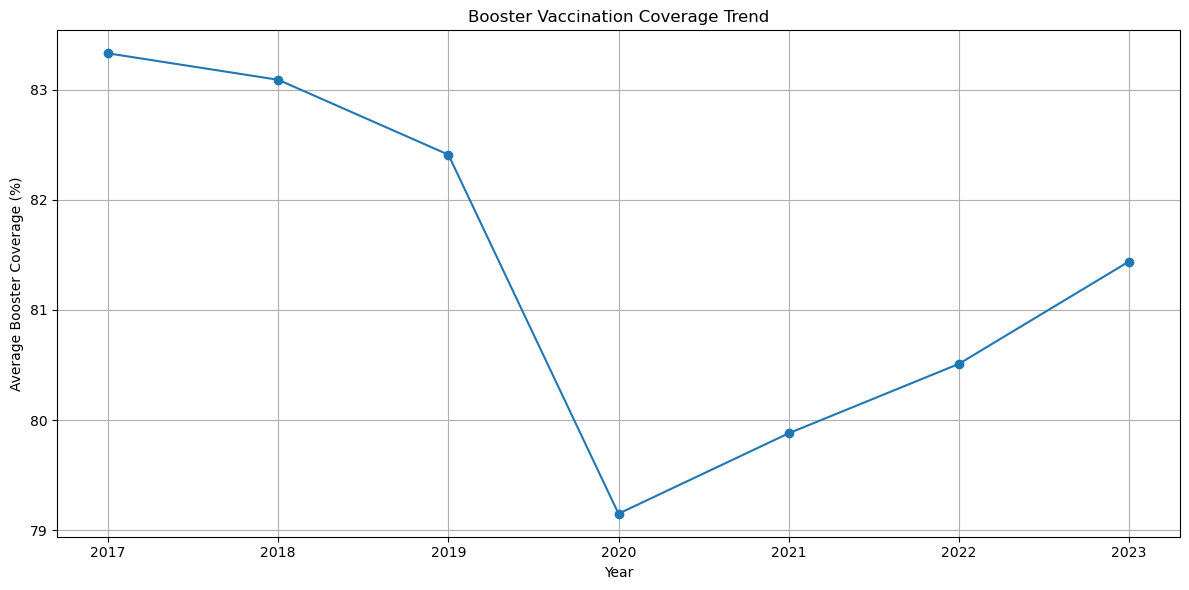

Booster trend saved successfully!


In [205]:
# ============================================
# BOOSTER TREND CHART
# ============================================

if len(q6) > 0:

    plt.figure(figsize=(12, 6))

    plt.plot(
        q6["YEAR"],
        q6["AVG_BOOSTER_COVERAGE"],
        marker="o"
    )

    plt.xlabel("Year")
    plt.ylabel("Average Booster Coverage (%)")
    plt.title("Booster Vaccination Coverage Trend")

    plt.grid(True)
    plt.tight_layout()
    plt.show()

    q6.to_csv(
        "analysis_results/Q6_booster_trend.csv",
        index=False
    )

    print("Booster trend saved successfully!")

In [206]:
# ============================================
# MEASLES COVERAGE VS 95% TARGET
# ============================================

cursor.execute("""
    SELECT
        YEAR,
        ROUND(AVG(COVERAGE), 2) AS AVG_MEASLES_COVERAGE
    FROM FACT_COVERAGE
    WHERE ANTIGEN_CODE = 'MCV1'
        AND COVERAGE IS NOT NULL
    GROUP BY YEAR
    ORDER BY YEAR
""")

scenario6 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "YEAR",
        "AVG_MEASLES_COVERAGE"
    ]
)

scenario6["AVG_MEASLES_COVERAGE"] = pd.to_numeric(
    scenario6["AVG_MEASLES_COVERAGE"],
    errors="coerce"
)

scenario6["GAP_TO_95"] = (
    95 - scenario6["AVG_MEASLES_COVERAGE"]
)

scenario6["MEETS_95_TARGET"] = (
    scenario6["AVG_MEASLES_COVERAGE"] >= 95
)

print("Measles target rows:", len(scenario6))

display(scenario6.head(20))

Measles target rows: 44


,YEAR,AVG_MEASLES_COVERAGE,GAP_TO_95,MEETS_95_TARGET
0,1980,41.18,53.82,False
1,1981,40.86,54.14,False
2,1982,41.71,53.29,False
3,1983,48.05,46.95,False
4,1984,50.07,44.93,False
5,1985,54.67,40.33,False
6,1986,58.82,36.18,False
7,1987,63.24,31.76,False
8,1988,66.92,28.08,False
9,1989,71.66,23.34,False


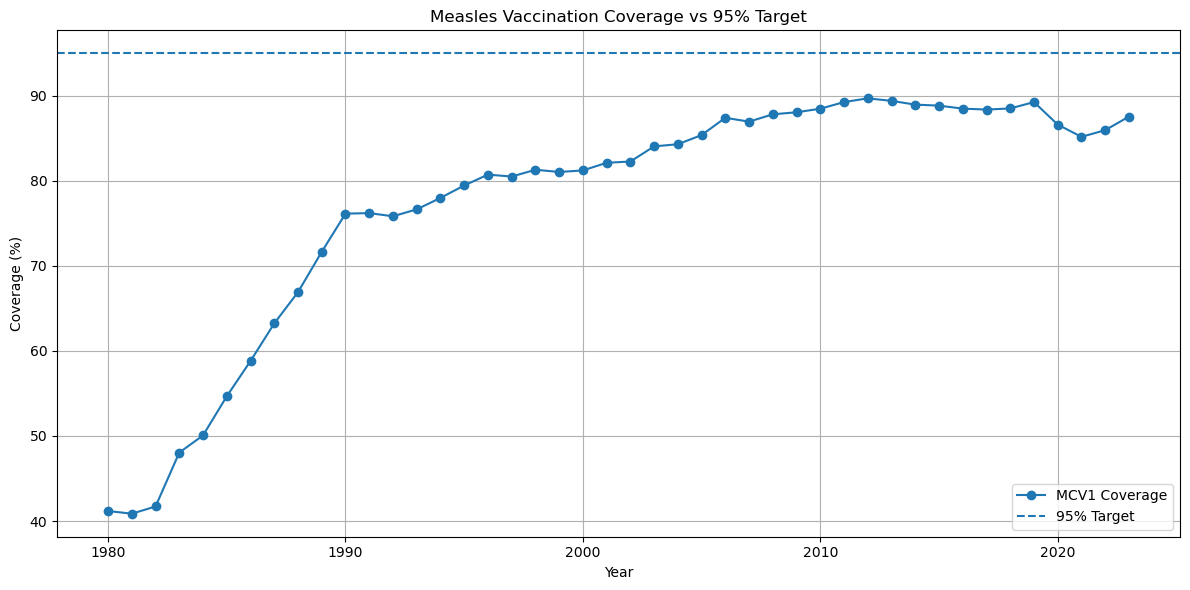

In [207]:
plt.figure(figsize=(12, 6))

plt.plot(
    scenario6["YEAR"],
    scenario6["AVG_MEASLES_COVERAGE"],
    marker="o",
    label="MCV1 Coverage"
)

plt.axhline(
    95,
    linestyle="--",
    label="95% Target"
)

plt.xlabel("Year")
plt.ylabel("Coverage (%)")
plt.title("Measles Vaccination Coverage vs 95% Target")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [208]:
scenario6.to_csv(
    "analysis_results/Scenario6_measles_95_target.csv",
    index=False
)

print("Measles 95% target analysis saved successfully!")

Measles 95% target analysis saved successfully!


In [209]:
# ============================================
# LOW VACCINATION COVERAGE
# ============================================

cursor.execute("""
    SELECT
        g.GEO_CODE,
        g.NAME,
        ROUND(AVG(c.COVERAGE), 2) AS AVG_COVERAGE
    FROM FACT_COVERAGE c
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE g.GEO_LEVEL = 'COUNTRY'
        AND c.COVERAGE IS NOT NULL
    GROUP BY
        g.GEO_CODE,
        g.NAME
    HAVING AVG(c.COVERAGE) < 80
    ORDER BY AVG_COVERAGE
""")

scenario1 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "AVG_COVERAGE"
    ]
)

scenario1["AVG_COVERAGE"] = pd.to_numeric(
    scenario1["AVG_COVERAGE"],
    errors="coerce"
)

print("Low-coverage countries:", len(scenario1))

display(scenario1.head(20))

Low-coverage countries: 0


,GEO_CODE,NAME,AVG_COVERAGE


In [210]:
# ============================================
# RECENT DISEASE CASES
# ============================================

cursor.execute("""
    SELECT
        MAX(YEAR)
    FROM FACT_CASES
    WHERE CASES IS NOT NULL
""")

latest_year = cursor.fetchone()[0]

print("Latest cases year:", latest_year)

Latest cases year: 2023


In [211]:
cursor.execute("""
    SELECT
        c.YEAR,
        d.DESCRIPTION AS DISEASE,
        SUM(c.CASES) AS TOTAL_CASES
    FROM FACT_CASES c
    JOIN DIM_DISEASE d
        ON d.DISEASE_CODE = c.DISEASE_CODE
    WHERE c.CASES IS NOT NULL
        AND c.YEAR >= :latest_year - 4
    GROUP BY
        c.YEAR,
        d.DESCRIPTION
    ORDER BY
        c.YEAR,
        TOTAL_CASES DESC
""", latest_year=latest_year)

scenario4 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "YEAR",
        "DISEASE",
        "TOTAL_CASES"
    ]
)

scenario4["TOTAL_CASES"] = pd.to_numeric(
    scenario4["TOTAL_CASES"],
    errors="coerce"
)

print("Recent-case records:", len(scenario4))

display(scenario4.head(20))

Recent-case records: 64


,YEAR,DISEASE,TOTAL_CASES
0,2019,Measles,2620476
1,2019,Mumps,510526
2,2019,Pertussis,449669
3,2019,Typhoid,445638
4,2019,Rubella,147665
5,2019,Diphtheria,68958
6,2019,Total tetanus,44235
7,2019,Japanese encephalitis,11130
8,2019,Neonatal tetanus,6519
9,2019,Yellow fever,1377


In [212]:
# ============================================
# POLIO ANALYSIS
# ============================================

cursor.execute("""
    SELECT
        c.YEAR,
        SUM(c.CASES) AS POLIO_CASES
    FROM FACT_CASES c
    WHERE c.DISEASE_CODE = 'POLIO'
        AND c.CASES IS NOT NULL
    GROUP BY c.YEAR
    ORDER BY c.YEAR
""")

scenario5 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "YEAR",
        "POLIO_CASES"
    ]
)

scenario5["POLIO_CASES"] = pd.to_numeric(
    scenario5["POLIO_CASES"],
    errors="coerce"
)

print("Polio analysis rows:", len(scenario5))

display(scenario5)

Polio analysis rows: 44


,YEAR,POLIO_CASES
0,1980,157892
1,1981,197214
2,1982,154890
3,1983,119920
4,1984,105252
5,1985,115450
6,1986,98538
7,1987,119049
8,1988,103851
9,1989,78312


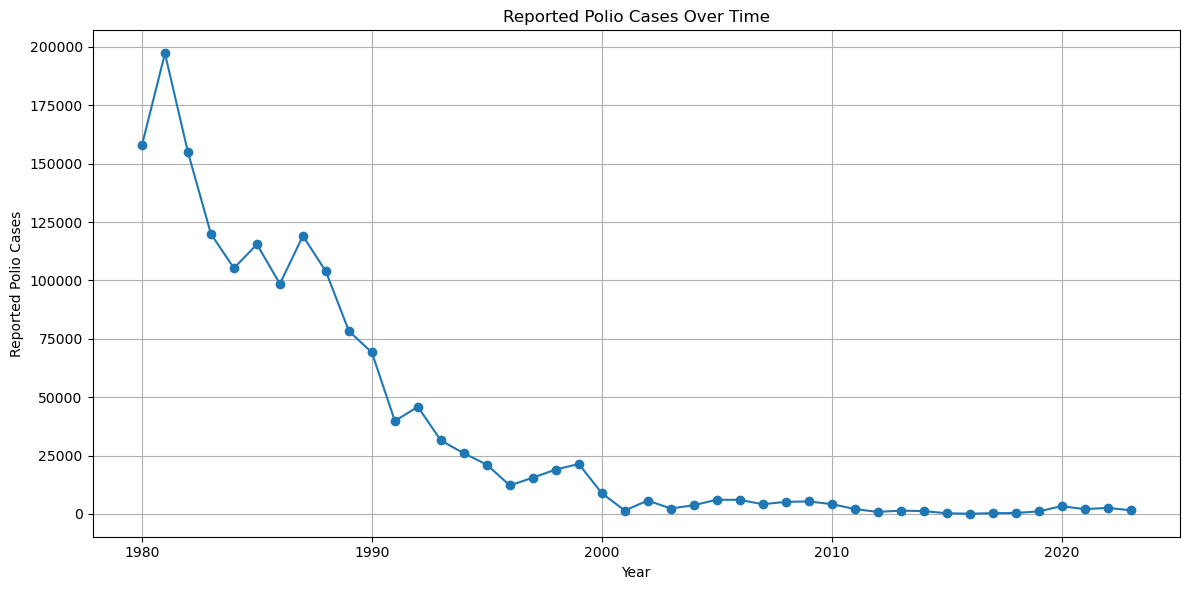

In [213]:
plt.figure(figsize=(12, 6))

plt.plot(
    scenario5["YEAR"],
    scenario5["POLIO_CASES"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Reported Polio Cases")
plt.title("Reported Polio Cases Over Time")

plt.grid(True)
plt.tight_layout()
plt.show()

In [214]:
scenario5.to_csv(
    "analysis_results/Scenario5_polio.csv",
    index=False
)

print("Polio analysis saved successfully!")

Polio analysis saved successfully!


In [215]:
# ============================================
# CHECK FIXED ANALYSES
# ============================================

files_to_check = [
    "Q1_vaccination_vs_incidence.csv",
    "Q2_dose_dropoff.csv",
    "Q6_booster_trend.csv",
    "Scenario1_low_coverage.csv",
    "Scenario4_recent_cases.csv",
    "Scenario5_polio.csv",
    "Scenario6_measles_95_target.csv"
]

for file in files_to_check:

    path = os.path.join(
        "analysis_results",
        file
    )

    if os.path.exists(path):

        df = pd.read_csv(path)

        print(
            f"{file:<45} {len(df):>8} rows"
        )

    else:

        print(
            f"{file:<45} NOT FOUND"
        )

Q1_vaccination_vs_incidence.csv                  21707 rows
Q2_dose_dropoff.csv                              48321 rows
Q6_booster_trend.csv                                 7 rows
Scenario1_low_coverage.csv                           0 rows
Scenario4_recent_cases.csv                           0 rows
Scenario5_polio.csv                                 44 rows
Scenario6_measles_95_target.csv                     44 rows


In [216]:
# ============================================
# LOW MCV1 COVERAGE COUNTRIES
# ============================================

cursor.execute("""
    SELECT
        g.GEO_CODE,
        g.NAME,
        ROUND(AVG(c.COVERAGE), 2) AS AVG_COVERAGE
    FROM FACT_COVERAGE c
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE c.ANTIGEN_CODE = 'MCV1'
        AND c.COVERAGE IS NOT NULL
        AND g.GEO_LEVEL = 'COUNTRY'
    GROUP BY
        g.GEO_CODE,
        g.NAME
    HAVING AVG(c.COVERAGE) < 90
    ORDER BY AVG_COVERAGE
""")

scenario1 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "AVG_COVERAGE"
    ]
)

scenario1["AVG_COVERAGE"] = pd.to_numeric(
    scenario1["AVG_COVERAGE"],
    errors="coerce"
)

print("Low MCV1 coverage countries:", len(scenario1))

display(scenario1.head(20))

Low MCV1 coverage countries: 0


,GEO_CODE,NAME,AVG_COVERAGE


In [217]:
# ============================================
# CHECK GEO LEVELS
# ============================================

cursor.execute("""
    SELECT
        GEO_LEVEL,
        COUNT(*) AS GEO_COUNT
    FROM DIM_GEO
    GROUP BY GEO_LEVEL
    ORDER BY GEO_LEVEL
""")

geo_level_check = pd.DataFrame(
    cursor.fetchall(),
    columns=["GEO_LEVEL", "GEO_COUNT"]
)

display(geo_level_check)

,GEO_LEVEL,GEO_COUNT
0,AGGREGATE,245


In [218]:
# ============================================
# MCV1 COVERAGE BY GEO LEVEL
# ============================================

cursor.execute("""
    SELECT
        g.GEO_LEVEL,
        COUNT(*) AS RECORDS,
        ROUND(MIN(c.COVERAGE), 2) AS MIN_COVERAGE,
        ROUND(MAX(c.COVERAGE), 2) AS MAX_COVERAGE,
        ROUND(AVG(c.COVERAGE), 2) AS AVG_COVERAGE
    FROM FACT_COVERAGE c
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE c.ANTIGEN_CODE = 'MCV1'
        AND c.COVERAGE IS NOT NULL
    GROUP BY g.GEO_LEVEL
    ORDER BY g.GEO_LEVEL
""")

mcv_geo_check = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_LEVEL",
        "RECORDS",
        "MIN_COVERAGE",
        "MAX_COVERAGE",
        "AVG_COVERAGE"
    ]
)

display(mcv_geo_check)

,GEO_LEVEL,RECORDS,MIN_COVERAGE,MAX_COVERAGE,AVG_COVERAGE
0,AGGREGATE,24178,0,155,79.45


In [219]:
# ============================================
# FIND LOW MCV1 RECORDS WITHOUT GEO FILTER
# ============================================

cursor.execute("""
    SELECT
        c.GEO_CODE,
        g.NAME,
        g.GEO_LEVEL,
        c.YEAR,
        c.COVERAGE
    FROM FACT_COVERAGE c
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE c.ANTIGEN_CODE = 'MCV1'
        AND c.COVERAGE IS NOT NULL
        AND c.COVERAGE < 90
        AND ROWNUM <= 20
""")

low_mcv_check = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "GEO_LEVEL",
        "YEAR",
        "COVERAGE"
    ]
)

display(low_mcv_check)

,GEO_CODE,NAME,GEO_LEVEL,YEAR,COVERAGE
0,AFG,Afghanistan,AGGREGATE,2023,77.58
1,AFG,Afghanistan,AGGREGATE,2023,77.58
2,AFG,Afghanistan,AGGREGATE,2023,55.00
3,AFG,Afghanistan,AGGREGATE,2022,79.39
4,AFG,Afghanistan,AGGREGATE,2022,79.39
5,AFG,Afghanistan,AGGREGATE,2022,56.00
6,AFG,Afghanistan,AGGREGATE,2021,74.27
7,AFG,Afghanistan,AGGREGATE,2021,74.27
8,AFG,Afghanistan,AGGREGATE,2021,51.00
9,AFG,Afghanistan,AGGREGATE,2020,76.71


In [220]:
# ============================================
# LOW MCV1 COVERAGE COUNTRIES
# Corrected for current DIM_GEO
# ============================================

cursor.execute("""
    SELECT
        g.GEO_CODE,
        g.NAME,
        ROUND(AVG(c.COVERAGE), 2) AS AVG_COVERAGE
    FROM FACT_COVERAGE c
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE c.ANTIGEN_CODE = 'MCV1'
        AND c.COVERAGE IS NOT NULL
    GROUP BY
        g.GEO_CODE,
        g.NAME
    HAVING AVG(c.COVERAGE) < 90
    ORDER BY AVG_COVERAGE
""")

scenario1 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "AVG_COVERAGE"
    ]
)

scenario1["AVG_COVERAGE"] = pd.to_numeric(
    scenario1["AVG_COVERAGE"],
    errors="coerce"
)

print("Low MCV1 coverage countries:", len(scenario1))

display(scenario1.head(20))

Low MCV1 coverage countries: 199


,GEO_CODE,NAME,AVG_COVERAGE
0,SOM,Somalia,38.51
1,ETH,Ethiopia,45.79
2,UNICEF_REGIONS_WCARO,West and Central Africa,47.09
3,AFG,Afghanistan,47.13
4,TCD,Chad,48.02
5,GNQ,Equatorial Guinea,48.04
6,CAF,Central African Republic,48.86
7,COD,Democratic Republic of the Congo,50.19
8,WB_SHORT_LIC,Low income,51.39
9,WB_LONG_LIC,Low income,51.39


In [221]:
scenario1.to_csv(
    "analysis_results/Scenario1_low_coverage.csv",
    index=False
)

print("Scenario1 saved successfully!")

Scenario1 saved successfully!


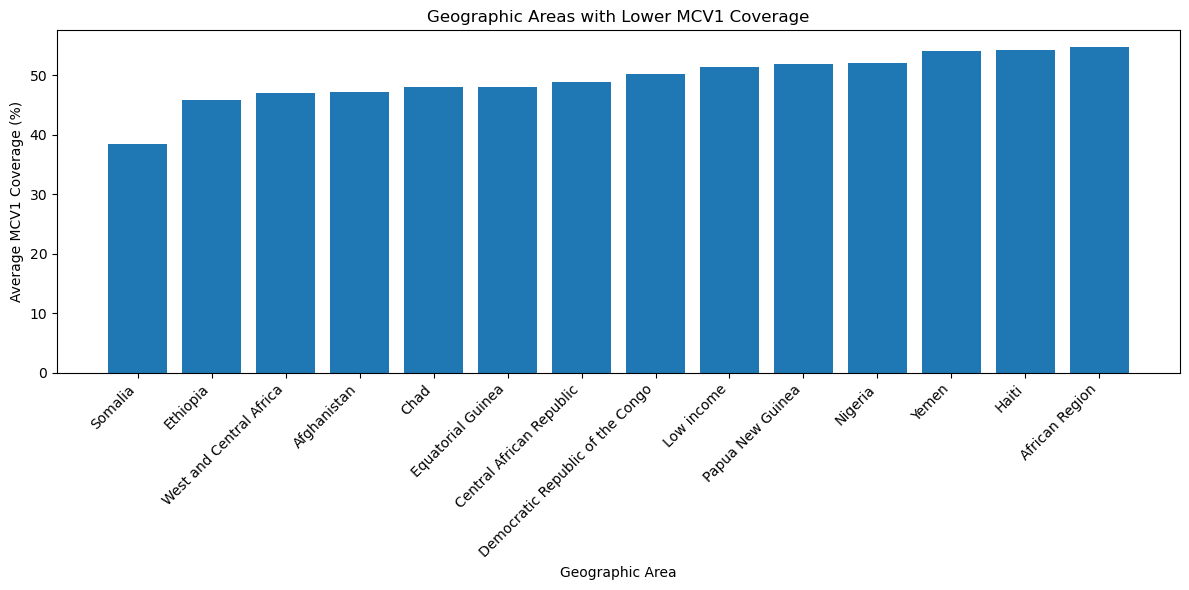

In [222]:
# ============================================
# LOW COVERAGE CHART
# ============================================

low_top = scenario1.head(15)

plt.figure(figsize=(12, 6))

plt.bar(
    low_top["NAME"],
    low_top["AVG_COVERAGE"]
)

plt.xlabel("Geographic Area")
plt.ylabel("Average MCV1 Coverage (%)")
plt.title("Geographic Areas with Lower MCV1 Coverage")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [223]:
# ============================================
# SCENARIO 4 - CHECK AVAILABLE CASE YEARS
# ============================================

cursor.execute("""
    SELECT
        YEAR,
        COUNT(*) AS RECORDS,
        SUM(CASES) AS TOTAL_CASES
    FROM FACT_CASES
    WHERE CASES IS NOT NULL
    GROUP BY YEAR
    ORDER BY YEAR DESC
""")

case_years = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "YEAR",
        "RECORDS",
        "TOTAL_CASES"
    ]
)

display(case_years.head(15))

,YEAR,RECORDS,TOTAL_CASES
0,2023,2026,17667763
1,2022,2027,10816152
2,2021,2051,6947015
3,2020,2010,4374467
4,2019,1966,4308600
5,2018,2098,3320114
6,2017,1861,2829120
7,2016,1694,2857981
8,2015,1660,2410565
9,2014,1595,2525116


In [224]:
print("Latest available year:", case_years["YEAR"].max())
print("Number of available years:", len(case_years))

Latest available year: 2023
Number of available years: 44


In [225]:
# ============================================
# SCENARIO 4 - RECENT REPORTED DISEASE CASES
# ============================================

recent_years = (
    case_years["YEAR"]
    .dropna()
    .astype(int)
    .sort_values(ascending=False)
    .head(5)
    .tolist()
)

print("Years selected:", recent_years)

Years selected: [2023, 2022, 2021, 2020, 2019]


In [226]:
# ============================================
# GET RECENT DISEASE CASES
# ============================================

year_list = ",".join(
    str(year) for year in recent_years
)

query = f"""
    SELECT
        c.YEAR,
        d.DESCRIPTION AS DISEASE,
        SUM(c.CASES) AS TOTAL_CASES
    FROM FACT_CASES c
    JOIN DIM_DISEASE d
        ON d.DISEASE_CODE = c.DISEASE_CODE
    WHERE c.CASES IS NOT NULL
        AND c.YEAR IN ({year_list})
    GROUP BY
        c.YEAR,
        d.DESCRIPTION
    ORDER BY
        c.YEAR DESC,
        TOTAL_CASES DESC
"""

cursor.execute(query)

scenario4 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "YEAR",
        "DISEASE",
        "TOTAL_CASES"
    ]
)

scenario4["TOTAL_CASES"] = pd.to_numeric(
    scenario4["TOTAL_CASES"],
    errors="coerce"
)

print("Scenario 4 rows:", len(scenario4))

display(scenario4.head(30))

Scenario 4 rows: 64


,YEAR,DISEASE,TOTAL_CASES
0,2023,Typhoid,13750687
1,2023,Measles,1991498
2,2023,Mumps,1154619
3,2023,Pertussis,479581
4,2023,Rubella,107146
5,2023,Diphtheria,74337
6,2023,Total tetanus,65493
7,2023,Invasive meningococcal disease,16661
8,2023,Neonatal tetanus,13755
9,2023,Japanese encephalitis,6342


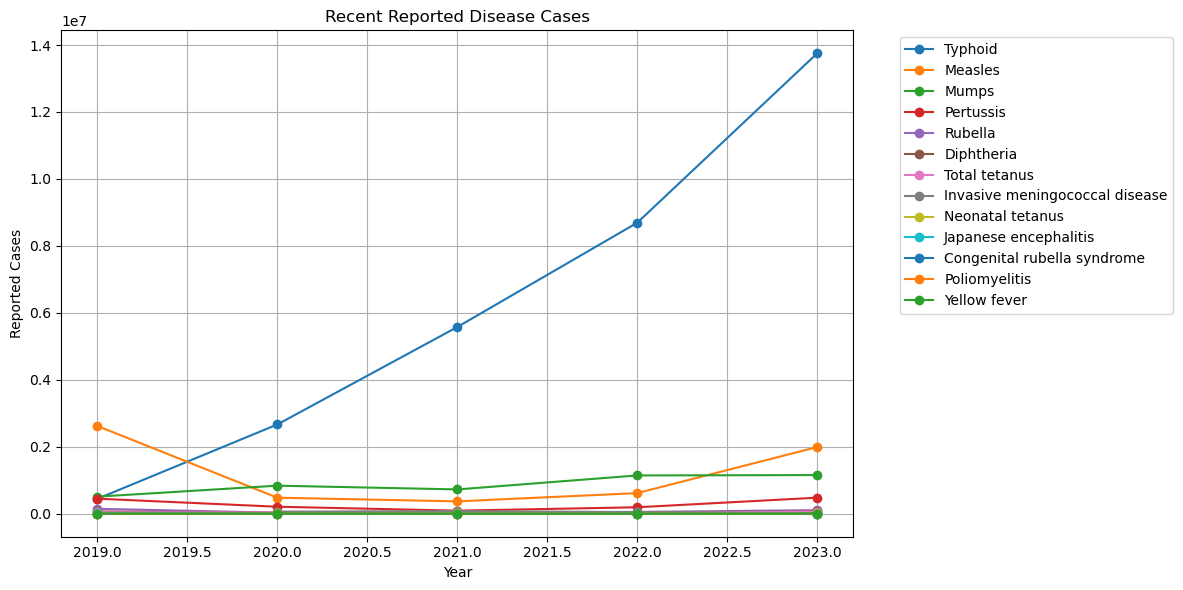

In [227]:
# ============================================
# SCENARIO 4 CHART
# ============================================

plt.figure(figsize=(12, 6))

for disease in scenario4["DISEASE"].unique():

    temp = scenario4[
        scenario4["DISEASE"] == disease
    ]

    plt.plot(
        temp["YEAR"],
        temp["TOTAL_CASES"],
        marker="o",
        label=disease
    )

plt.xlabel("Year")
plt.ylabel("Reported Cases")
plt.title("Recent Reported Disease Cases")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [228]:
scenario4.to_csv(
    "analysis_results/Scenario4_recent_cases.csv",
    index=False
)

print("Scenario4_recent_cases.csv saved successfully!")

Scenario4_recent_cases.csv saved successfully!


In [229]:
# ============================================
# MEDIUM Q10 - GEOGRAPHIC DISEASE ANALYSIS
# ============================================

cursor.execute("""
    SELECT
        c.GEO_CODE,
        g.NAME,
        d.DESCRIPTION AS DISEASE,
        SUM(c.CASES) AS TOTAL_CASES
    FROM FACT_CASES c
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    JOIN DIM_DISEASE d
        ON d.DISEASE_CODE = c.DISEASE_CODE
    WHERE c.CASES IS NOT NULL
    GROUP BY
        c.GEO_CODE,
        g.NAME,
        d.DESCRIPTION
    ORDER BY TOTAL_CASES DESC
""")

medium_q10 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "DISEASE",
        "TOTAL_CASES"
    ]
)

medium_q10["TOTAL_CASES"] = pd.to_numeric(
    medium_q10["TOTAL_CASES"],
    errors="coerce"
)

print("Medium Q10 rows:", len(medium_q10))

display(medium_q10.head(20))

Medium Q10 rows: 2765


,GEO_CODE,NAME,DISEASE,TOTAL_CASES
0,GLOBAL,Global,Measles,48012198
1,AFR,African Region,Measles,19292641
2,GLOBAL,Global,Pertussis,17695690
3,GLOBAL,Global,Mumps,12105277
4,GLOBAL,Global,Typhoid,10384321
5,WPR,Western Pacific Region,Measles,10210588
6,AFR,African Region,Typhoid,8993069
7,CHN,China,Measles,7284318
8,WPR,Western Pacific Region,Mumps,6757788
9,EUR,European Region,Measles,6713019


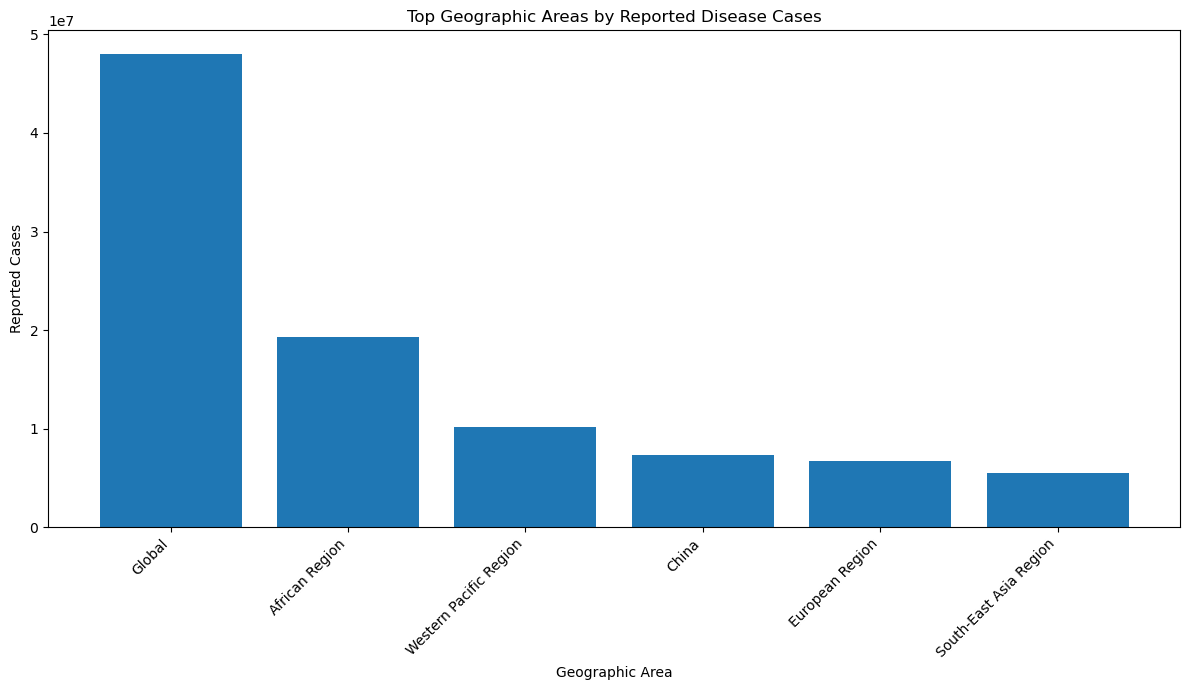

In [230]:
# ============================================
# MEDIUM Q10 CHART
# ============================================

top_q10 = medium_q10.head(15)

plt.figure(figsize=(12, 7))

plt.bar(
    top_q10["NAME"].astype(str),
    top_q10["TOTAL_CASES"]
)

plt.xlabel("Geographic Area")
plt.ylabel("Reported Cases")
plt.title("Top Geographic Areas by Reported Disease Cases")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [231]:
# ============================================
# SAVE MEDIUM Q10
# ============================================

medium_q10.to_csv(
    "analysis_results/Medium_Q10_geographic_disease.csv",
    index=False
)

print("Medium Q10 saved successfully!")

Medium Q10 saved successfully!


In [232]:
print(
    "Medium Q10 rows:",
    len(medium_q10)
)

Medium Q10 rows: 2765


In [233]:
# ============================================
# MEDIUM Q3 - DISEASE REDUCTION
# ============================================

cursor.execute("""
    SELECT DISTINCT YEAR
    FROM FACT_CASES
    WHERE CASES IS NOT NULL
    ORDER BY YEAR
""")

available_case_years = [
    row[0] for row in cursor.fetchall()
]

print("First year:", available_case_years[0])
print("Latest year:", available_case_years[-1])

First year: 1980
Latest year: 2023


In [234]:
first_year = available_case_years[0]
latest_year = available_case_years[-1]

cursor.execute("""
    SELECT
        d.DESCRIPTION AS DISEASE,

        SUM(
            CASE
                WHEN c.YEAR = :first_year
                THEN c.CASES
                ELSE 0
            END
        ) AS FIRST_YEAR_CASES,

        SUM(
            CASE
                WHEN c.YEAR = :latest_year
                THEN c.CASES
                ELSE 0
            END
        ) AS LATEST_YEAR_CASES

    FROM FACT_CASES c

    JOIN DIM_DISEASE d
        ON d.DISEASE_CODE = c.DISEASE_CODE

    WHERE c.CASES IS NOT NULL
        AND c.YEAR IN (:first_year, :latest_year)

    GROUP BY d.DESCRIPTION

    ORDER BY FIRST_YEAR_CASES DESC
""", first_year=first_year, latest_year=latest_year)

medium_q3 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "DISEASE",
        "FIRST_YEAR_CASES",
        "LATEST_YEAR_CASES"
    ]
)

medium_q3["FIRST_YEAR_CASES"] = pd.to_numeric(
    medium_q3["FIRST_YEAR_CASES"],
    errors="coerce"
)

medium_q3["LATEST_YEAR_CASES"] = pd.to_numeric(
    medium_q3["LATEST_YEAR_CASES"],
    errors="coerce"
)

medium_q3["CASE_REDUCTION"] = (
    medium_q3["FIRST_YEAR_CASES"]
    - medium_q3["LATEST_YEAR_CASES"]
)

medium_q3["REDUCTION_PERCENT"] = (
    medium_q3["CASE_REDUCTION"]
    / medium_q3["FIRST_YEAR_CASES"].replace(0, np.nan)
) * 100

print("Medium Q3 rows:", len(medium_q3))

display(medium_q3)

Medium Q3 rows: 13


,DISEASE,FIRST_YEAR_CASES,LATEST_YEAR_CASES,CASE_REDUCTION,REDUCTION_PERCENT
0,Measles,11560070,1991498,9568572,82.772613
1,Pertussis,5905183,479581,5425602,91.878643
2,Total tetanus,341833,65493,276340,80.840644
3,Diphtheria,291495,74337,217158,74.498019
4,Poliomyelitis,157892,1614,156278,98.977782
5,Neonatal tetanus,39015,13755,25260,64.744329
6,Yellow fever,432,1428,-996,-230.555556
7,Invasive meningococcal disease,0,16661,-16661,NaN
8,Congenital rubella syndrome,0,4602,-4602,NaN
9,Rubella,0,107146,-107146,NaN


In [235]:
medium_q3.to_csv(
    "analysis_results/Medium_Q3_disease_reduction.csv",
    index=False
)

print("Medium Q3 saved successfully!")

Medium Q3 saved successfully!


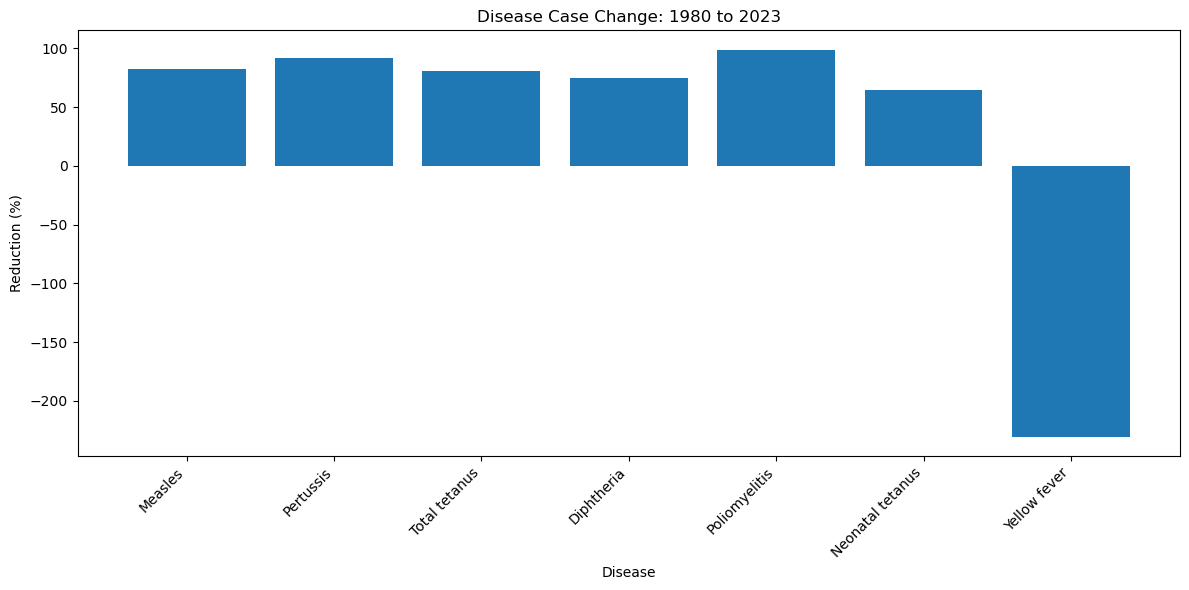

In [236]:
# ============================================
# DISEASE REDUCTION CHART
# ============================================

chart_q3 = medium_q3.dropna(
    subset=["REDUCTION_PERCENT"]
).copy()

plt.figure(figsize=(12, 6))

plt.bar(
    chart_q3["DISEASE"],
    chart_q3["REDUCTION_PERCENT"]
)

plt.xlabel("Disease")
plt.ylabel("Reduction (%)")
plt.title(
    f"Disease Case Change: {first_year} to {latest_year}"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [237]:
# ============================================
# MEDIUM Q4 - TARGET COVERAGE
# ============================================

cursor.execute("""
    SELECT
        c.YEAR,
        ROUND(AVG(c.COVERAGE), 2) AS AVG_COVERAGE
    FROM FACT_COVERAGE c
    WHERE c.COVERAGE IS NOT NULL
    GROUP BY c.YEAR
    ORDER BY c.YEAR
""")

medium_q4 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "YEAR",
        "AVG_COVERAGE"
    ]
)

medium_q4["AVG_COVERAGE"] = pd.to_numeric(
    medium_q4["AVG_COVERAGE"],
    errors="coerce"
)

medium_q4["TARGET"] = 90

medium_q4["GAP_TO_TARGET"] = (
    medium_q4["AVG_COVERAGE"]
    - medium_q4["TARGET"]
)

medium_q4["MEETS_TARGET"] = (
    medium_q4["AVG_COVERAGE"] >= medium_q4["TARGET"]
)

print("Medium Q4 rows:", len(medium_q4))

display(medium_q4.head(20))

Medium Q4 rows: 44


,YEAR,AVG_COVERAGE,TARGET,GAP_TO_TARGET,MEETS_TARGET
0,1980,44.25,90,-45.75,False
1,1981,46.12,90,-43.88,False
2,1982,48.78,90,-41.22,False
3,1983,52.86,90,-37.14,False
4,1984,53.97,90,-36.03,False
5,1985,56.21,90,-33.79,False
6,1986,60.27,90,-29.73,False
7,1987,63.74,90,-26.26,False
8,1988,67.41,90,-22.59,False
9,1989,70.75,90,-19.25,False


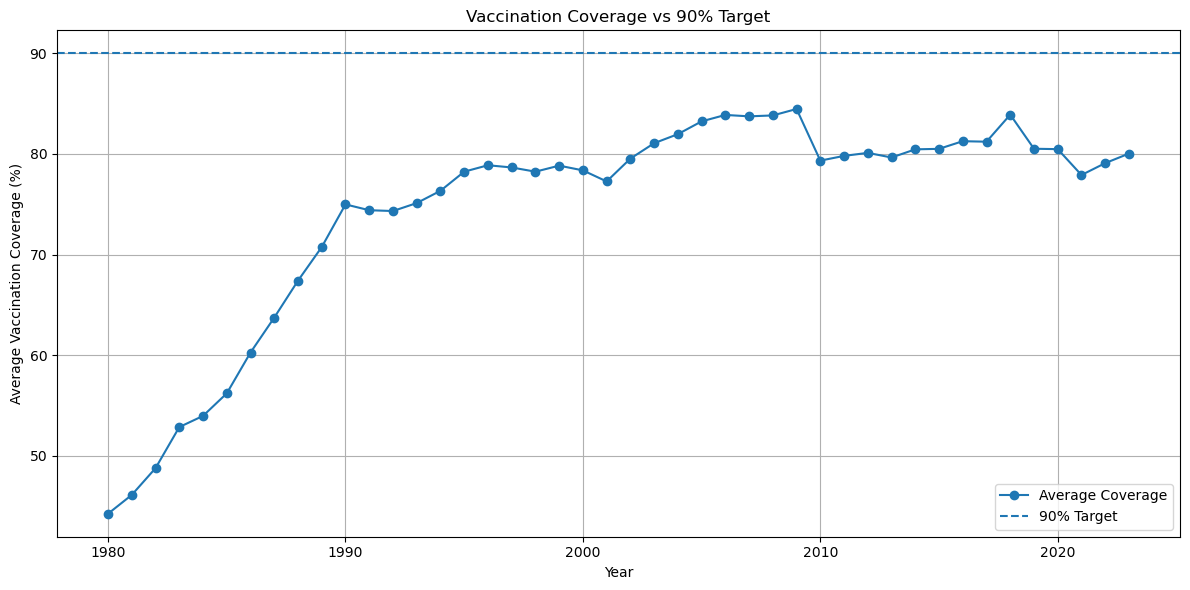

In [238]:
# ============================================
# MEDIUM Q4 CHART
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    medium_q4["YEAR"],
    medium_q4["AVG_COVERAGE"],
    marker="o",
    label="Average Coverage"
)

plt.axhline(
    90,
    linestyle="--",
    label="90% Target"
)

plt.xlabel("Year")
plt.ylabel("Average Vaccination Coverage (%)")
plt.title("Vaccination Coverage vs 90% Target")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [239]:
medium_q4.to_csv(
    "analysis_results/Medium_Q4_target_coverage.csv",
    index=False
)

print("Medium Q4 saved successfully!")

Medium Q4 saved successfully!


In [240]:
# ============================================
# MEDIUM Q7 - ANTIGEN DISEASE ANALYSIS
# ============================================

cursor.execute("""
    SELECT
        c.ANTIGEN_CODE,
        a.DESCRIPTION AS ANTIGEN,
        c.YEAR,
        ROUND(AVG(c.COVERAGE), 2) AS AVG_COVERAGE,
        COUNT(*) AS RECORDS
    FROM FACT_COVERAGE c
    JOIN DIM_ANTIGEN a
        ON a.ANTIGEN_CODE = c.ANTIGEN_CODE
    WHERE c.COVERAGE IS NOT NULL
    GROUP BY
        c.ANTIGEN_CODE,
        a.DESCRIPTION,
        c.YEAR
    ORDER BY
        c.ANTIGEN_CODE,
        c.YEAR
""")

medium_q7 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "ANTIGEN_CODE",
        "ANTIGEN",
        "YEAR",
        "AVG_COVERAGE",
        "RECORDS"
    ]
)

medium_q7["AVG_COVERAGE"] = pd.to_numeric(
    medium_q7["AVG_COVERAGE"],
    errors="coerce"
)

medium_q7["RECORDS"] = pd.to_numeric(
    medium_q7["RECORDS"],
    errors="coerce"
)

print("Medium Q7 rows:", len(medium_q7))

display(medium_q7.head(20))

Medium Q7 rows: 1038


,ANTIGEN_CODE,ANTIGEN,YEAR,AVG_COVERAGE,RECORDS
0,15HPV1_F,"HPV Vaccination coverage by age 15, first dose...",2010,14.15,40
1,15HPV1_F,"HPV Vaccination coverage by age 15, first dose...",2011,20.76,42
2,15HPV1_F,"HPV Vaccination coverage by age 15, first dose...",2012,25.09,47
3,15HPV1_F,"HPV Vaccination coverage by age 15, first dose...",2013,31.70,56
4,15HPV1_F,"HPV Vaccination coverage by age 15, first dose...",2014,34.48,63
5,15HPV1_F,"HPV Vaccination coverage by age 15, first dose...",2015,38.91,70
6,15HPV1_F,"HPV Vaccination coverage by age 15, first dose...",2016,42.32,77
7,15HPV1_F,"HPV Vaccination coverage by age 15, first dose...",2017,46.52,79
8,15HPV1_F,"HPV Vaccination coverage by age 15, first dose...",2018,47.24,88
9,15HPV1_F,"HPV Vaccination coverage by age 15, first dose...",2019,50.29,94


In [241]:
medium_q7.to_csv(
    "analysis_results/Medium_Q7_antigen_disease.csv",
    index=False
)

print("Medium Q7 saved successfully!")

Medium Q7 saved successfully!


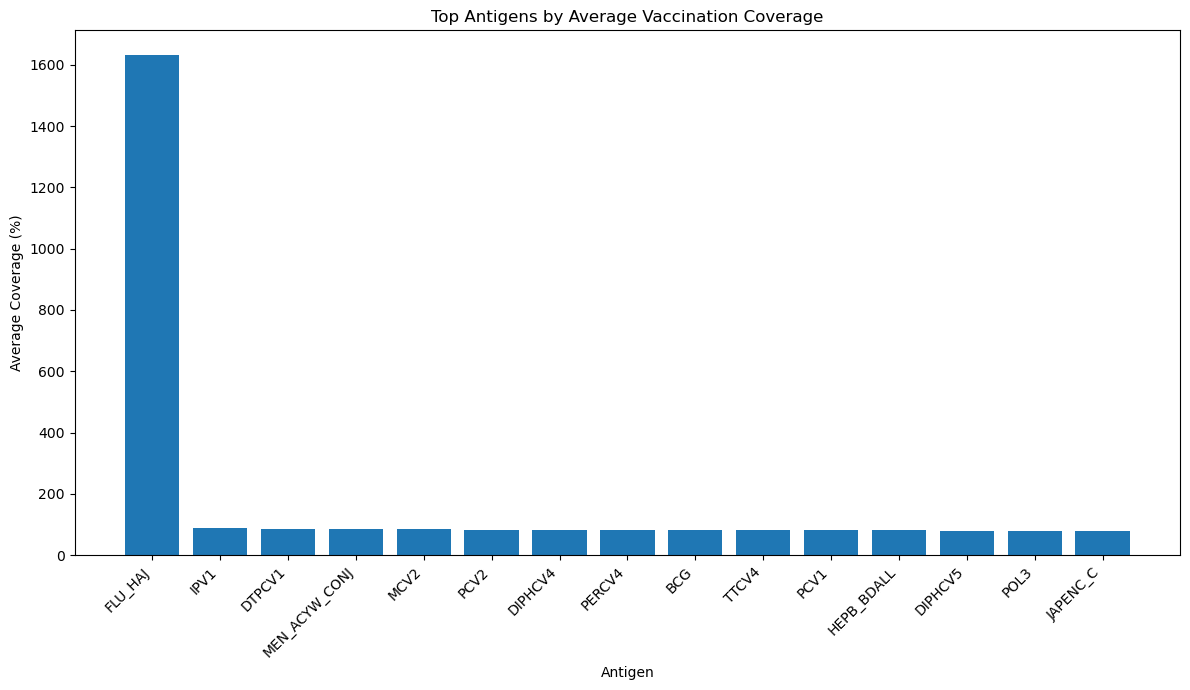

In [242]:
# ============================================
# MEDIUM Q7 CHART
# ============================================

q7_chart = (
    medium_q7
    .groupby(["ANTIGEN_CODE", "ANTIGEN"])["AVG_COVERAGE"]
    .mean()
    .reset_index()
    .sort_values(
        "AVG_COVERAGE",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(12, 7))

plt.bar(
    q7_chart["ANTIGEN_CODE"],
    q7_chart["AVG_COVERAGE"]
)

plt.xlabel("Antigen")
plt.ylabel("Average Coverage (%)")
plt.title("Top Antigens by Average Vaccination Coverage")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [243]:
print("Medium Q7 rows:", len(medium_q7))

Medium Q7 rows: 1038


In [244]:
# ============================================
# MEDIUM Q8 - LOW COVERAGE AVAILABILITY
# ============================================

cursor.execute("""
    SELECT
        c.GEO_CODE,
        g.NAME,
        c.YEAR,
        c.ANTIGEN_CODE,
        a.DESCRIPTION AS ANTIGEN,
        c.COVERAGE
    FROM FACT_COVERAGE c
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    JOIN DIM_ANTIGEN a
        ON a.ANTIGEN_CODE = c.ANTIGEN_CODE
    WHERE c.COVERAGE IS NOT NULL
        AND c.COVERAGE < 80
    ORDER BY c.COVERAGE ASC
""")

medium_q8 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "YEAR",
        "ANTIGEN_CODE",
        "ANTIGEN",
        "COVERAGE"
    ]
)

medium_q8["COVERAGE"] = pd.to_numeric(
    medium_q8["COVERAGE"],
    errors="coerce"
)

print("Medium Q8 rows:", len(medium_q8))

display(medium_q8.head(20))

Medium Q8 rows: 80198


,GEO_CODE,NAME,YEAR,ANTIGEN_CODE,ANTIGEN,COVERAGE
0,WPR,Western Pacific Region,2011,PRHPV1_M,"HPV Vaccination program coverage, first dose, ...",0.0
1,WPR,Western Pacific Region,2011,PRHPVC_M,"HPV Vaccination program coverage, last dose, m...",0.0
2,WPR,Western Pacific Region,2010,15HPV1_F,"HPV Vaccination coverage by age 15, first dose...",0.0
3,WPR,Western Pacific Region,2010,15HPV1_M,"HPV Vaccination coverage by age 15, first dose...",0.0
4,WPR,Western Pacific Region,2010,15HPVC_F,"HPV Vaccination coverage by age 15, last dose,...",0.0
5,WPR,Western Pacific Region,2010,15HPVC_M,"HPV Vaccination coverage by age 15, last dose,...",0.0
6,WPR,Western Pacific Region,2010,PRHPV1_M,"HPV Vaccination program coverage, first dose, ...",0.0
7,WPR,Western Pacific Region,2010,PRHPVC_M,"HPV Vaccination program coverage, last dose, m...",0.0
8,WPR,Western Pacific Region,2007,ROTAC,"Rotavirus, last dose",0.0
9,WPR,Western Pacific Region,2006,ROTAC,"Rotavirus, last dose",0.0


In [245]:
medium_q8.to_csv(
    "analysis_results/Medium_Q8_low_coverage_availability.csv",
    index=False
)

print("Medium Q8 saved successfully!")

Medium Q8 saved successfully!


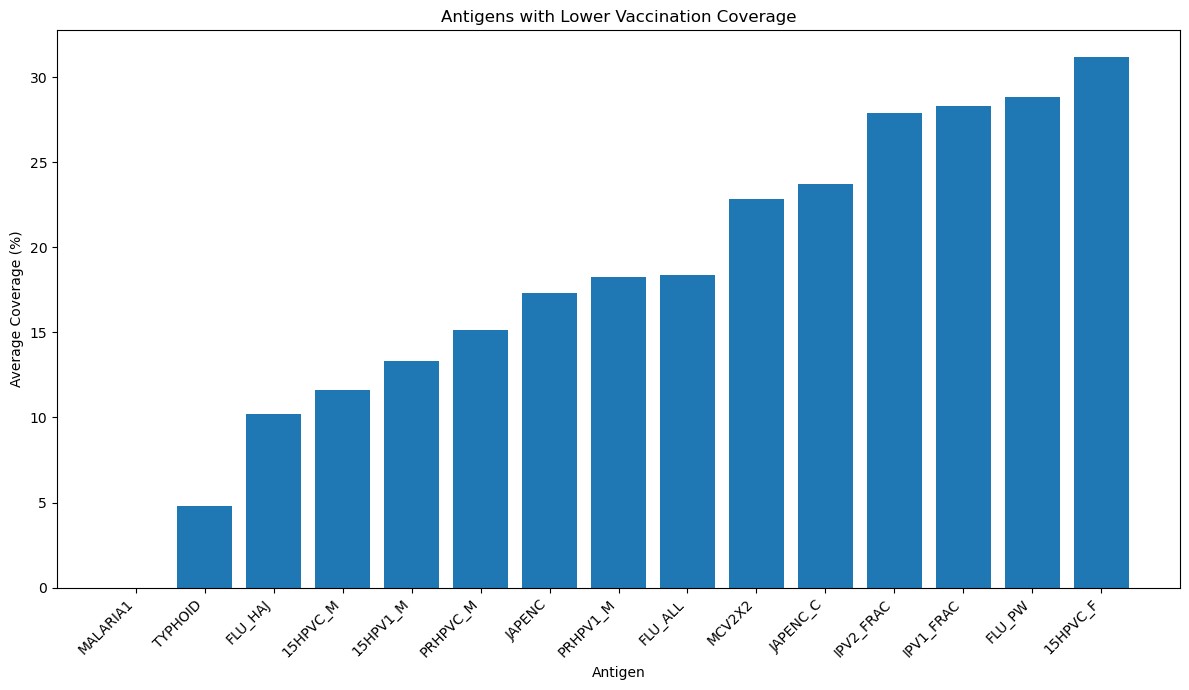

In [246]:
# ============================================
# MEDIUM Q8 CHART
# ============================================

q8_chart = (
    medium_q8
    .groupby("ANTIGEN_CODE")["COVERAGE"]
    .mean()
    .sort_values()
    .head(15)
)

plt.figure(figsize=(12, 7))

plt.bar(
    q8_chart.index,
    q8_chart.values
)

plt.xlabel("Antigen")
plt.ylabel("Average Coverage (%)")
plt.title("Antigens with Lower Vaccination Coverage")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [247]:
print("Medium Q8 rows:", len(medium_q8))

Medium Q8 rows: 80198


In [248]:
# ============================================
# MEDIUM Q9 - COVERAGE GAPS
# ============================================

cursor.execute("""
    SELECT
        c.GEO_CODE,
        g.NAME,
        c.YEAR,
        c.ANTIGEN_CODE,
        a.DESCRIPTION AS ANTIGEN,
        ROUND(c.COVERAGE, 2) AS COVERAGE,
        ROUND(90 - c.COVERAGE, 2) AS COVERAGE_GAP
    FROM FACT_COVERAGE c
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    JOIN DIM_ANTIGEN a
        ON a.ANTIGEN_CODE = c.ANTIGEN_CODE
    WHERE c.COVERAGE IS NOT NULL
        AND c.COVERAGE < 90
    ORDER BY COVERAGE_GAP DESC
""")

medium_q9 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "YEAR",
        "ANTIGEN_CODE",
        "ANTIGEN",
        "COVERAGE",
        "COVERAGE_GAP"
    ]
)

medium_q9["COVERAGE"] = pd.to_numeric(
    medium_q9["COVERAGE"],
    errors="coerce"
)

medium_q9["COVERAGE_GAP"] = pd.to_numeric(
    medium_q9["COVERAGE_GAP"],
    errors="coerce"
)

print("Medium Q9 rows:", len(medium_q9))

display(medium_q9.head(20))

Medium Q9 rows: 120487


,GEO_CODE,NAME,YEAR,ANTIGEN_CODE,ANTIGEN,COVERAGE,COVERAGE_GAP
0,WPR,Western Pacific Region,2011,PRHPV1_M,"HPV Vaccination program coverage, first dose, ...",0.0,90.0
1,WPR,Western Pacific Region,2011,PRHPVC_M,"HPV Vaccination program coverage, last dose, m...",0.0,90.0
2,WPR,Western Pacific Region,2010,15HPV1_F,"HPV Vaccination coverage by age 15, first dose...",0.0,90.0
3,WPR,Western Pacific Region,2010,15HPV1_M,"HPV Vaccination coverage by age 15, first dose...",0.0,90.0
4,WPR,Western Pacific Region,2010,15HPVC_F,"HPV Vaccination coverage by age 15, last dose,...",0.0,90.0
5,WPR,Western Pacific Region,2010,15HPVC_M,"HPV Vaccination coverage by age 15, last dose,...",0.0,90.0
6,WPR,Western Pacific Region,2010,PRHPV1_M,"HPV Vaccination program coverage, first dose, ...",0.0,90.0
7,WPR,Western Pacific Region,2010,PRHPVC_M,"HPV Vaccination program coverage, last dose, m...",0.0,90.0
8,WPR,Western Pacific Region,2007,ROTAC,"Rotavirus, last dose",0.0,90.0
9,WPR,Western Pacific Region,2006,ROTAC,"Rotavirus, last dose",0.0,90.0


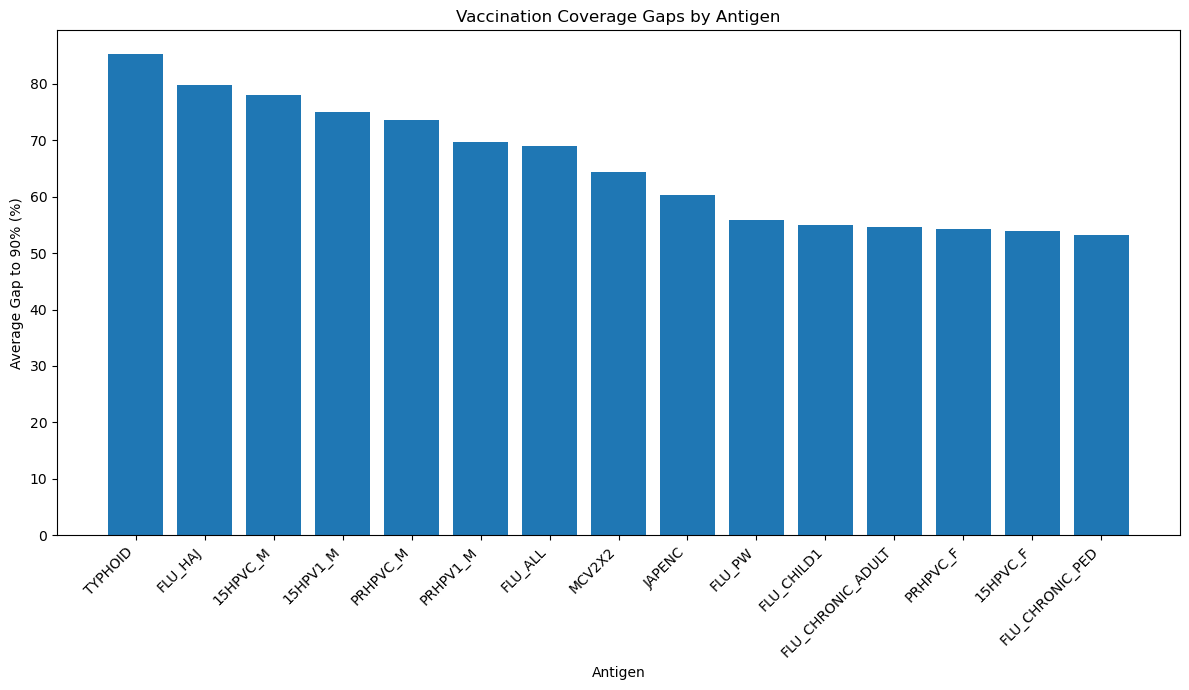

In [249]:
# ============================================
# MEDIUM Q9 CHART
# ============================================

q9_chart = (
    medium_q9
    .groupby("ANTIGEN_CODE")["COVERAGE_GAP"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

plt.bar(
    q9_chart.index,
    q9_chart.values
)

plt.xlabel("Antigen")
plt.ylabel("Average Gap to 90% (%)")
plt.title("Vaccination Coverage Gaps by Antigen")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [250]:
print("Medium Q9 rows:", len(medium_q9))

Medium Q9 rows: 120487


In [251]:
# ============================================
# Q10 - HIGH COVERAGE + HIGH INCIDENCE
# ============================================

cursor.execute("""
    SELECT AVG(INCIDENCE_RATE)
    FROM FACT_INCIDENCE
    WHERE DISEASE_CODE = 'MEASLES'
        AND INCIDENCE_RATE IS NOT NULL
""")

avg_measles_incidence = cursor.fetchone()[0]

print(
    "Average measles incidence:",
    avg_measles_incidence
)

Average measles incidence: 535.6409431048818


In [252]:
cursor.execute("""
    SELECT
        c.GEO_CODE,
        g.NAME,
        c.YEAR,
        ROUND(c.COVERAGE, 2) AS MCV1_COVERAGE,
        ROUND(i.INCIDENCE_RATE, 2) AS MEASLES_INCIDENCE
    FROM FACT_COVERAGE c
    JOIN FACT_INCIDENCE i
        ON c.GEO_CODE = i.GEO_CODE
        AND c.YEAR = i.YEAR
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE c.ANTIGEN_CODE = 'MCV1'
        AND c.COVERAGE IS NOT NULL
        AND i.DISEASE_CODE = 'MEASLES'
        AND i.INCIDENCE_RATE IS NOT NULL
        AND c.COVERAGE >= 90
        AND i.INCIDENCE_RATE > :avg_incidence
    ORDER BY i.INCIDENCE_RATE DESC
""", avg_incidence=avg_measles_incidence)

q10 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "YEAR",
        "MCV1_COVERAGE",
        "MEASLES_INCIDENCE"
    ]
)

q10["MCV1_COVERAGE"] = pd.to_numeric(
    q10["MCV1_COVERAGE"],
    errors="coerce"
)

q10["MEASLES_INCIDENCE"] = pd.to_numeric(
    q10["MEASLES_INCIDENCE"],
    errors="coerce"
)

print("Q10 rows:", len(q10))

display(q10.head(20))

Q10 rows: 426


,GEO_CODE,NAME,YEAR,MCV1_COVERAGE,MEASLES_INCIDENCE
0,NIU,Niue,1991,99.0,49347.5
1,NIU,Niue,1991,100.0,49347.5
2,NIU,Niue,1991,100.0,49347.5
3,SLB,Solomon Islands,1989,92.0,42887.6
4,SLB,Solomon Islands,1989,92.0,42887.6
5,SLB,Solomon Islands,1989,92.0,42887.6
6,ALB,Albania,1989,96.0,41723.4
7,ALB,Albania,1989,96.0,41723.4
8,ALB,Albania,1989,96.0,41723.4
9,COK,Cook Islands,1989,99.0,40810.3


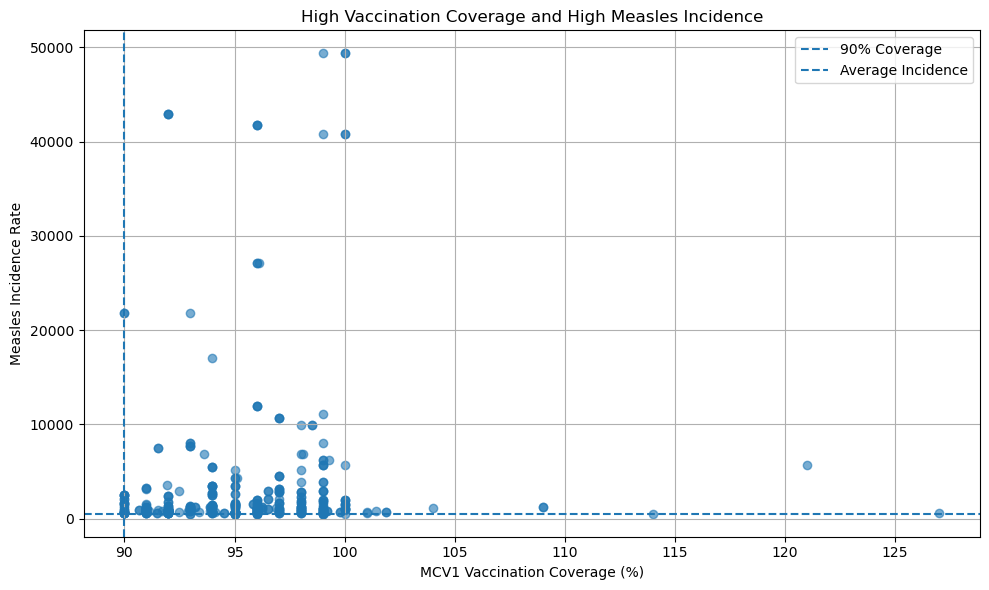

In [253]:
# ============================================
# Q10 CHART
# ============================================

plt.figure(figsize=(10, 6))

plt.scatter(
    q10["MCV1_COVERAGE"],
    q10["MEASLES_INCIDENCE"],
    alpha=0.6
)

plt.axvline(
    90,
    linestyle="--",
    label="90% Coverage"
)

plt.axhline(
    avg_measles_incidence,
    linestyle="--",
    label="Average Incidence"
)

plt.xlabel("MCV1 Vaccination Coverage (%)")
plt.ylabel("Measles Incidence Rate")
plt.title(
    "High Vaccination Coverage and High Measles Incidence"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [254]:
# ============================================
# FINAL ANALYSIS FILE CHECK
# ============================================

import os
import pandas as pd

files = sorted([
    f for f in os.listdir("analysis_results")
    if f.endswith(".csv")
])

print("=" * 75)
print("FINAL ANALYSIS RESULTS")
print("=" * 75)

for file in files:

    path = os.path.join(
        "analysis_results",
        file
    )

    df = pd.read_csv(path)

    status = "✅" if len(df) > 0 else "❌"

    print(
        f"{status} {file:<55} {len(df):>8} rows"
    )

FINAL ANALYSIS RESULTS
✅ Medium_Q10_geographic_disease.csv                           2765 rows
✅ Medium_Q1_introduction_cases.csv                          184529 rows
✅ Medium_Q2_before_after.csv                                184529 rows
✅ Medium_Q3_disease_reduction.csv                               13 rows
✅ Medium_Q4_target_coverage.csv                                 44 rows
✅ Medium_Q5_schedule.csv                                      5988 rows
✅ Medium_Q6_introduction_timeline.csv                          104 rows
✅ Medium_Q7_antigen_disease.csv                               1038 rows
✅ Medium_Q8_low_coverage_availability.csv                    80198 rows
❌ Medium_Q9_coverage_gaps.csv                                    0 rows
❌ Q10_high_coverage_high_incidence.csv                           0 rows
✅ Q1_vaccination_vs_incidence.csv                            21707 rows
✅ Q2_dose_dropoff.csv                                        48321 rows
✅ Q3_gender_available_data.csv           

In [255]:
import pandas as pd

cursor.execute("""
    SELECT
        c.GEO_CODE,
        g.NAME,
        c.YEAR,
        ROUND(c.COVERAGE, 2) AS MCV1_COVERAGE,
        ROUND(90 - c.COVERAGE, 2) AS COVERAGE_GAP
    FROM FACT_COVERAGE c
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE c.ANTIGEN_CODE = 'MCV1'
        AND c.COVERAGE IS NOT NULL
        AND c.COVERAGE < 90
    ORDER BY COVERAGE_GAP DESC
""")

medium_q9 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "YEAR",
        "MCV1_COVERAGE",
        "COVERAGE_GAP"
    ]
)

print("Medium Q9 rows:", len(medium_q9))

medium_q9.to_csv(
    "analysis_results/Medium_Q9_coverage_gaps.csv",
    index=False
)

medium_q9.head(20)

Medium Q9 rows: 13197


,GEO_CODE,NAME,YEAR,MCV1_COVERAGE,COVERAGE_GAP
0,BGD,Bangladesh,1981,0.00,90.00
1,FRA,France,1981,0.00,90.00
2,IDN,Indonesia,1982,0.00,90.00
3,IND,India,1981,0.00,90.00
4,MHL,Marshall Islands,2019,0.00,90.00
5,NIU,Niue,1994,0.00,90.00
6,SEAR,South-East Asia Region,1980,0.00,90.00
7,UNICEF_REGIONS_EAPRO,East Asia and the Pacific,1980,0.00,90.00
8,UNICEF_REGIONS_ROSA,South Asia,1981,0.00,90.00
9,UNICEF_REGIONS_ROSA,South Asia,1980,0.00,90.00


In [256]:
cursor.execute("""
    SELECT
        COUNT(*) AS TOTAL_ROWS,
        MIN(INCIDENCE_RATE) AS MIN_RATE,
        MAX(INCIDENCE_RATE) AS MAX_RATE,
        AVG(INCIDENCE_RATE) AS AVG_RATE
    FROM FACT_INCIDENCE
    WHERE DISEASE_CODE = 'MEASLES'
        AND INCIDENCE_RATE IS NOT NULL
""")

q10_stats = cursor.fetchone()

print("Total rows :", q10_stats[0])
print("Minimum    :", q10_stats[1])
print("Maximum    :", q10_stats[2])
print("Average    :", q10_stats[3])

Total rows : 8419
Minimum    : 0
Maximum    : 69101.3
Average    : 535.6409431048818


In [257]:
cursor.execute("""
    SELECT
        COUNT(*)
    FROM FACT_COVERAGE c
    JOIN FACT_INCIDENCE i
        ON c.GEO_CODE = i.GEO_CODE
        AND c.YEAR = i.YEAR
    WHERE c.ANTIGEN_CODE = 'MCV1'
        AND c.COVERAGE IS NOT NULL
        AND i.DISEASE_CODE = 'MEASLES'
        AND i.INCIDENCE_RATE IS NOT NULL
        AND c.COVERAGE >= 90
""")

print("High coverage + measurable measles incidence:",
      cursor.fetchone()[0])

High coverage + measurable measles incidence: 10021


In [258]:
# Q10: High Coverage + High Measles Incidence

cursor.execute("""
    SELECT
        c.GEO_CODE,
        g.NAME,
        c.YEAR,
        ROUND(c.COVERAGE, 2) AS MCV1_COVERAGE,
        ROUND(i.INCIDENCE_RATE, 2) AS MEASLES_INCIDENCE
    FROM FACT_COVERAGE c
    JOIN FACT_INCIDENCE i
        ON c.GEO_CODE = i.GEO_CODE
        AND c.YEAR = i.YEAR
    JOIN DIM_GEO g
        ON g.GEO_CODE = c.GEO_CODE
    WHERE c.ANTIGEN_CODE = 'MCV1'
        AND c.COVERAGE IS NOT NULL
        AND i.DISEASE_CODE = 'MEASLES'
        AND i.INCIDENCE_RATE IS NOT NULL
        AND c.COVERAGE >= 90
        AND i.INCIDENCE_RATE > :avg_incidence
    ORDER BY i.INCIDENCE_RATE DESC
""", avg_incidence=535.6409431048818)

q10 = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "GEO_CODE",
        "NAME",
        "YEAR",
        "MCV1_COVERAGE",
        "MEASLES_INCIDENCE"
    ]
)

print("Q10 rows:", len(q10))

q10.head(20)

Q10 rows: 426


,GEO_CODE,NAME,YEAR,MCV1_COVERAGE,MEASLES_INCIDENCE
0,NIU,Niue,1991,99.0,49347.5
1,NIU,Niue,1991,100.0,49347.5
2,NIU,Niue,1991,100.0,49347.5
3,SLB,Solomon Islands,1989,92.0,42887.6
4,SLB,Solomon Islands,1989,92.0,42887.6
5,SLB,Solomon Islands,1989,92.0,42887.6
6,ALB,Albania,1989,96.0,41723.4
7,ALB,Albania,1989,96.0,41723.4
8,ALB,Albania,1989,96.0,41723.4
9,COK,Cook Islands,1989,99.0,40810.3


In [259]:
q10.to_csv(
    "analysis_results/Q10_high_coverage_high_incidence.csv",
    index=False
)

print("Q10 CSV saved successfully.")

Q10 CSV saved successfully.


In [260]:
import os
import pandas as pd

files = sorted([
    f for f in os.listdir("analysis_results")
    if f.endswith(".csv")
])

print("=" * 80)
print("FINAL ANALYSIS RESULTS")
print("=" * 80)

empty_files = []

for file in files:
    path = os.path.join("analysis_results", file)
    df = pd.read_csv(path)

    if len(df) > 0:
        status = "✅"
    else:
        status = "❌"
        empty_files.append(file)

    print(f"{status} {file:<55} {len(df):>8} rows")

print("=" * 80)

if empty_files:
    print("Files still empty:")
    for file in empty_files:
        print(" -", file)
else:
    print("🎉 ALL ANALYSIS FILES CONTAIN DATA!")

FINAL ANALYSIS RESULTS
✅ Medium_Q10_geographic_disease.csv                           2765 rows
✅ Medium_Q1_introduction_cases.csv                          184529 rows
✅ Medium_Q2_before_after.csv                                184529 rows
✅ Medium_Q3_disease_reduction.csv                               13 rows
✅ Medium_Q4_target_coverage.csv                                 44 rows
✅ Medium_Q5_schedule.csv                                      5988 rows
✅ Medium_Q6_introduction_timeline.csv                          104 rows
✅ Medium_Q7_antigen_disease.csv                               1038 rows
✅ Medium_Q8_low_coverage_availability.csv                    80198 rows
✅ Medium_Q9_coverage_gaps.csv                                13197 rows
✅ Q10_high_coverage_high_incidence.csv                         426 rows
✅ Q1_vaccination_vs_incidence.csv                            21707 rows
✅ Q2_dose_dropoff.csv                                        48321 rows
✅ Q3_gender_available_data.csv           

In [ ]:
import os
import pandas as pd

csv_files = sorted([
    f for f in os.listdir("analysis_results")
    if f.endswith(".csv")
])

excel_path = "Vaccination_Analysis_Final.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    used_sheets = set()

    for file in csv_files:

        path = os.path.join("analysis_results", file)
        df = pd.read_csv(path)

        # Skip empty CSV files
        if df.empty:
            continue

        sheet_name = os.path.splitext(file)[0]

        # Make names shorter/readable
        if sheet_name.startswith("Medium_"):
            sheet_name = sheet_name.replace("Medium_", "", 1)

        elif sheet_name.startswith("Scenario"):
            sheet_name = sheet_name.replace("Scenario", "S", 1)

        # Excel maximum sheet-name length = 31
        sheet_name = sheet_name[:31]

        # Avoid duplicate sheet names
        original_name = sheet_name
        counter = 1

        while sheet_name in used_sheets:
            suffix = f"_{counter}"
            sheet_name = original_name[:31-len(suffix)] + suffix
            counter += 1

        used_sheets.add(sheet_name)

        df.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

print("✅ FINAL EXCEL CREATED")
print("File:", excel_path)
print("Total sheets:", len(used_sheets))